# Cortical TRF analysis: neural speech restoration at the cocktail party 
# Applying Stimulus Informed Generalized Eigenvector Decomposition [SI-GEVD]

This notebook runs the same kinds of analyses as Brodbeck et al. 2020
(PLOS Biology), "Neural speech restoration at the cocktail party", on this
project's own EEG dataset (13 subjects) instead of their 26-subject MEG
dataset. Cells that match one of their reported comparisons carry a short
comment naming the result they found, as a point of reference - not a
target this dataset is expected to hit. Different dataset, different
modality, a much smaller group: matching the *methodology* is the goal,
not reproducing their exact numbers.

**Renaming from `cortical_analysis.ipynb`:** foreground -> **attend**,
background -> **ignore**, mixture stays **mix**. This only changes labels
and variable names in this notebook - `experiment.py`'s `label_events()`
still populates `ds['fg']`/`ds['bg']`/`ds['mix']` under those original
names, shared with the other notebook.

**Frequency resolution:** 8-band predictors (`gammatone-8`,
`gammatone-on-8`) throughout, not the 1-band versions
`cortical_analysis.ipynb` mostly uses, so TRFs can be examined per
frequency band (an STRF - spectro-temporal response function).

## Structure

Organized by listening condition, each as its own section: clean speech,
then diotic, dichotic-left, dichotic-right, and binaural - each of the
four two-talker conditions further split into its own base section plus
overt-onset, masked-onset, and intensity-level-control subsections. Every
subsection is self-contained: the same handful of shared helper functions
(defined once below) get called with that subsection's own predictors and
`epoch`. Cells run top to bottom; `data`, `diff`, `result`, `data_full`,
`data_masked`, `p` are reused generically across subsections the same way
`cortical_analysis.ipynb` reuses `data`/`p`/`dss` - what a cell overwrites
is always exactly what the cell right before it just produced.

**One fit per model per condition.** `FULL_BASE` (the plain attend/
ignore/mix model) and `FULL_MASKED` (the overt/masked version) are each
fit with `e.load_trfs()` exactly once per condition, into `data_full`/
`data_masked` - every STRF, peak-timing, waveform, and attention-effect
cell that needs one of those predictors reads a column out of that
already-loaded result instead of re-fitting the same model again. Only
the unique-contribution/direct-comparison cells call `e.load_model_test()`
on their own, since a model *comparison* is a different derivative than
a plain TRF fit and can't be read out of `data_full`/`data_masked`.

In [1]:
from eelbrain import *
from experiment import e, topomap_with_colorbar, FIGURES_DIR
import matplotlib.pyplot as plt
import numpy
import seaborn as sns

# Where to save plots - inside the BIDS dataset's derivatives, same as
# cortical_analysis.ipynb, not somewhere outside the dataset.
DST = FIGURES_DIR

INFO    :  *** BinauralCocktail initialized with root /Users/joshuaighalo/Github Repositories/dataset/cocktail/bids on 2026-09-24 10:21:00 ***
INFO    :  Using eelbrain 0.0.0, mne 1.12.1.


## Preprocessing (run once per subject)

Identical to `cortical_analysis.ipynb` - both notebooks use the same
preprocessed EEG (`raw='ica'`), so this only does real work the first time
either notebook is run for a given subject.

In [2]:
MANUAL_BAD_CHANNELS = False
AUTO_BAD_CHANNELS_R = 0.3
REDO_BAD_CHANNELS = True

e.mark_bad_channels(
    'all',
    manual_bad_channels=MANUAL_BAD_CHANNELS, auto_bad_channels_r=AUTO_BAD_CHANNELS_R,
    redo_bad_channels=REDO_BAD_CHANNELS,
)

  skipping (already done): 01, 02, 03, 04, 05, 06, 07, 08, 09, 10, 11, 12, 13

Done. Bad channels marked.


In [3]:
MANUAL_ICA = False
AUTO_ICA_CONFIDENCE = 0.75

e.select_ica_artifacts(
    'all',
    manual_ica=MANUAL_ICA, auto_ica_confidence=AUTO_ICA_CONFIDENCE,
)

  skipping (already done): 01, 02, 03, 04, 05, 06, 07, 08, 09, 10, 11, 12, 13

Done. ICA fit and artifact components selected.


## Shared setup

Everything in this section is reused by every condition section below.

### Stimulus-role and predictor-name helpers

Every predictor is built from the same handful of pieces: envelope or
onset, attended/ignored/mixture, and (for the masking/intensity
subsections) overt/masked/loudness-tier splits. A "stimulus role" prefix
picks which event-dataset column supplies the stimulus name for a term -
this is the same `bg~`/`mix~` mechanism `cortical_analysis.ipynb` already
uses, just wrapped in small functions so model strings don't have to be
retyped by hand:

- `''` (empty) = attended speaker (`fg` column, `experiment.py`'s default
  `stim_var` - no prefix needed)
- `'bg~'` = ignored speaker (`bg` column)
- `'mix~'` = the acoustic mixture (`mix` column)

The intensity-tier predictors are named `gammatone-on-low-8`/`-mid-8`/
`-high-8` rather than "mixture-onset-low": eelbrain only recognizes
`gammatone` as a registered predictor key (see `predictors` in
`experiment.py`), so every predictor code has to start with `gammatone-`
to resolve at all - see the comment above that block in
`predictors/gammatone_predictors.py`.

In [4]:
ATTEND, IGNORE, MIX = '', 'bg~', 'mix~'


def envelope(role=ATTEND):
    return f"{role}gammatone-8"


def onset(role=ATTEND):
    return f"{role}gammatone-on-8"


def overt_onset(role=ATTEND):
    return f"{role}gammatone-on-overt-8"


def masked_onset(role=ATTEND):
    return f"{role}gammatone-on-masked-8"


def level_onset(tier, role=MIX):
    assert tier in ('low', 'mid', 'high')
    return f"{role}gammatone-on-{tier}-8"


# The three model-comparisons every condition section below is built
# from. Only `epoch=` changes between diotic/dichotic-left/dichotic-right/
# binaural - the model strings themselves don't depend on condition.
FULL_CLEAN = f"{envelope(ATTEND)} + {onset(ATTEND)}"
FULL_BASE = f"{envelope(ATTEND)} + {onset(ATTEND)} + {envelope(IGNORE)} + {onset(IGNORE)} + {envelope(MIX)} + {onset(MIX)}"
FULL_MASKED = (
    f"{envelope(ATTEND)} + {overt_onset(ATTEND)} + {masked_onset(ATTEND)} + "
    f"{envelope(IGNORE)} + {overt_onset(IGNORE)} + {masked_onset(IGNORE)} + "
    f"{envelope(MIX)} + {onset(MIX)}"
)
LEVEL_AWARE = (
    f"{envelope(ATTEND)} + {onset(ATTEND)} + "
    f"{envelope(IGNORE)} + "
    f"{envelope(MIX)} + {level_onset('low')} + {level_onset('mid')} + {level_onset('high')}"
)

### Fit metric: correlation (r), not proportion of variance explained (ev)

`METRIC` is the one place this choice is made - every model comparison
below reads it from here rather than hard-coding `'ev'` or `'r'`. Change
it here to switch every analysis in this notebook at once.

In [5]:
METRIC = 'r'  # 'r' (Pearson correlation) or 'ev' (proportion of variance explained)
PMIN = 0.05

# ev is a tiny fraction of variance (needs a fixed, narrow color scale to
# stay readable); r has a much larger natural range and reads fine with
# an automatic scale - see cortical_analysis.ipynb's own TOPO_ARGS/
# TOPO_ARGS_R split for the same reasoning.
TOPO_ARGS = dict(clip='circle') if METRIC == 'r' else dict(vmax=0.005, clip='circle')

### Shared TRF-fitting settings and the region of interest (ROI)

`PARAMETERS` is identical to `cortical_analysis.ipynb`. `ROI` is the same
fronto-central sensor set too - not a new one.

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


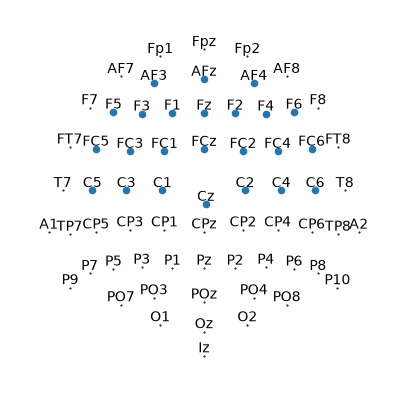

In [6]:
PARAMETERS = {
    'raw': 'ica',
    'group': 'all',
    'samplingrate': 128,
    'data': 'eeg',
    'tstart': -0.100,
    'tstop': 0.600,
}

data = e.load_trfs(1, 'gammatone-8', epoch='clean', **PARAMETERS)
eeg = data['ev']

ROI = [
    'AF3', 'F1', 'F3', 'F5',
    'FC5', 'FC3', 'FC1',
    'C1', 'C3', 'C5',
    'AF4', 'AFz',
    'Fz', 'F2', 'F4', 'F6',
    'FC6', 'FC4', 'FC2', 'FCz',
    'Cz', 'C2', 'C4', 'C6',
]

p = plot.SensorMap(eeg, mark=ROI)

### Display names and colors for attend/ignore/mix

Reused everywhere a plot needs to tell the three streams apart at a
glance - same red/blue/gray convention `cortical_analysis.ipynb` uses for
foreground/background/mixture.

In [7]:
LABELS_ROLE = {'attend': 'Attend', 'ignore': 'Ignore', 'mix': 'Mixture'}
COLORS_ROLE = {'attend': 'red', 'ignore': 'blue', 'mix': '.3'}

### Peak-timing search windows

Named here, once, so every "peak amplitude & timing" cell below points at
one of these instead of a bare number buried in the cell - change a
window in one place and every analysis that uses it picks it up. Onset
and envelope get their own windows; overt/masked onsets get wider ones
since masked onsets are expected to peak later than overt ones (Brodbeck:
roughly 15-50ms slower).

In [8]:
ONSET_POSITIVE_PEAK_WINDOW = (0.040, 0.200)
ONSET_NEGATIVE_PEAK_WINDOW = (0.040, 0.200)
ENVELOPE_POSITIVE_PEAK_WINDOW = (0.040, 0.200)
ENVELOPE_NEGATIVE_PEAK_WINDOW = (0.040, 0.200)
MASKED_POSITIVE_PEAK_WINDOW = (0.040, 0.200)
MASKED_NEGATIVE_PEAK_WINDOW = (0.040, 0.200)

### Model-comparison helpers

Two comparison syntaxes are used below (see `e.load_model_test`'s own
docstring): **`full_model @ predictor`** (omission - fit `full_model`,
then a null model with just `predictor` removed) for "unique
contribution" analyses, and **`model_a > model_b`** (a *direct* comparison
between two independently-specified, non-nested models) for the
overt/masked-split-vs-plain-onsets and masked-aware-vs-level-aware
comparisons - eelbrain supports this directly in its model-string
grammar, no separate API needed.

Both return the same shape of result: `data` (one row per subject per
model - `'test'`/`'baseline'`), `diff` (one row per subject: the
per-subject improvement score, `test` minus `baseline`, already averaged
over the ROI), and `result` (the mass-univariate significance-test
object). Each condition section below calls these once per analysis, then
uses `data`/`diff`/`result` across the next couple of cells - the topomap
trio, the stat result, and the per-subject swarm plot are deliberately
separate cells so each one's output is easy to find.

Unlike the TRF-fitting helpers further down, these two always call
`e.load_model_test()` themselves rather than reading from an
already-loaded result: a model *comparison* (full vs. null) is its own
derivative, not something that can be read out of a plain `load_trfs()`
fit, so there is no equivalent "load once, reuse" shortcut available here.

In [9]:
def compute_unique_contribution(full_model, predictor, epoch, roi=ROI, metric=METRIC):
    "Omission comparison: does `predictor` uniquely improve on `full_model` with it removed?"
    comparison = f"{full_model} @ {predictor}"
    data, result = e.load_model_test(comparison, **PARAMETERS, pmin=PMIN, metric=metric, epoch=epoch, return_data=True)
    diff = table.difference(metric, 'model', 'test', 'baseline', 'subject', data=data)
    diff[f'roi_{metric}'] = diff[metric].mean(sensor=roi)
    return data, diff, result


def compute_direct_comparison(model_a, model_b, epoch, roi=ROI, metric=METRIC):
    "Direct, non-nested comparison: does model_a fit better than model_b?"
    comparison = f"{model_a} > {model_b}"
    data, result = e.load_model_test(comparison, **PARAMETERS, pmin=PMIN, metric=metric, epoch=epoch, return_data=True)
    diff = table.difference(metric, 'model', 'test', 'baseline', 'subject', data=data)
    diff[f'roi_{metric}'] = diff[metric].mean(sensor=roi)
    return data, diff, result


def show_topomap_trio(data, diff, result, label, epoch, predictor, metric=METRIC):
    "Group-averaged topomaps: the test model's own fit, the baseline model's own fit, and their significance-masked difference"
    pct = metric == 'ev'
    topo_kwargs = dict(pct=pct, condition=epoch, predictor=predictor, colorbar_side='left', colorbar_label=False, **TOPO_ARGS)
    topomap_with_colorbar(metric, data.sub("model == 'test'"), label=f'{label}: test', **topo_kwargs)
    topomap_with_colorbar(metric, data.sub("model == 'baseline'"), label=f'{label}: baseline', **topo_kwargs)
    # The third panel needs to show the mean r/ev difference (the actual
    # unique contribution), masked by significance - NOT result's own
    # masked_parameter_map() directly, which holds the test's underlying
    # t-values (whatever units the cluster test itself ran on), not the
    # r/ev difference this notebook otherwise reports everywhere else.
    # So: take the real mean difference, and only borrow the *mask* -
    # which sensors were significant - from the test result.
    mean_diff = diff[metric].mean('case')
    significant = numpy.ma.getmaskarray(result.masked_parameter_map(pmin=PMIN).x)
    masked_diff = NDVar(numpy.ma.MaskedArray(mean_diff.x, mask=significant), mean_diff.dims, mean_diff.name, mean_diff.info)
    topomap_with_colorbar(None, masked_diff, label=f'{label}: test - baseline', **topo_kwargs)


def show_subject_swarm(diff, label, epoch, metric=METRIC):
    "One dot per subject: their own ROI-averaged test-minus-baseline score (Brodbeck Fig 3B/4B style)"
    fig, ax = plt.subplots(figsize=(2, 2.5))
    sns.swarmplot(y=diff[f'roi_{metric}'].x, ax=ax, size=5, color='.25')
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.set_ylabel(metric)
    ax.set_xticks([])
    ax.set_title(f'{label} ({epoch})', fontsize=9)
    fig.tight_layout()
    return fig

### TRF-reading and peak-timing helpers

`extract_strf`/`extract_trf` pull one predictor's response out of an
*already-loaded* `load_trfs()` result (`data_full`/`data_masked`, each
loaded exactly once per condition just below) rather than reloading or
refitting - the TRF fit itself is the expensive part of this notebook,
and a model like `FULL_BASE` only ever needs to be fit once per condition
even though a dozen or more cells below each read a different one of its
predictor columns. `add_peak` stays generic (a name and a window in, two
new columns out) so it's the same one function for onsets, envelope,
overt, and masked alike.

In [10]:
def extract_strf(data_full, column, roi=ROI):
    "Group-average (frequency, time) STRF for one predictor column, read from an already-loaded load_trfs() result"
    return data_full[column].mean(sensor=roi).mean('case')


def extract_trf(data_full, column, roi=ROI):
    "Per-subject, ROI-averaged, frequency-summed, smoothed TRF for one predictor column, read from an already-loaded load_trfs() result"
    trf = data_full[column].sum('frequency').mean(sensor=roi)
    ds = data_full['subject',]
    ds['trf_sm'] = resample(trf, 512)
    return ds


def add_peak(ds, name, window, kind='max'):
    "Add `{name}_time`/`{name}_amp`: the location/value of ds['trf_sm']'s peak within `window`"
    segment = ds['trf_sm'].sub(time=window)
    if kind == 'max':
        ds[f'{name}_time'] = segment.argmax('time')
        ds[f'{name}_amp'] = segment.max('time')
    else:
        ds[f'{name}_time'] = segment.argmin('time')
        ds[f'{name}_amp'] = segment.min('time')
    return ds


def print_peak_table(data, kind, group):
    "Per-subject table of one peak's time (ms) and amplitude, broken down by `group` (e.g. 'role'/'masking')"
    print(f"\n{kind} peak")
    print(f"{'subject':<10}{group:<10}{'time (ms)':>12}{'amp':>14}")
    for subject, g, t, amp in zip(data['subject'], data[group], data[f'{kind}_time'], data[f'{kind}_amp']):
        print(f"{subject:<10}{g:<10}{t * 1e3:>12.0f}{amp:>14.4g}")

## SI-GEVD spatial filtering (exploratory)

Stimulus-Informed Generalized Eigenvalue Decomposition (SI-GEVD) - a
spatial filter that combines the EEG channels in whatever way maximizes
the power of the part of the signal that looks like a speech-driven
brain response, relative to everything else. Ported directly from the
original MATLAB implementation (`find_sigevd_filter.m`/`trfestim.m`/
`lag_data.m`) at https://github.com/exporl/si-gevd, generalized to a list
of `(stim, resp)` pairs so the same function covers every condition here:

- clean: one pair (single stimulus, single TRF - the paper's own
  CCA-equivalent case, since there's nothing else to average against).
- diotic/binaural: two pairs sharing the *same* EEG (attend + ignore are
  both present in the same samples at once, not disjoint trial sets).
- dichotic: two pairs on *disjoint* EEG (each trial is entirely
  attend-left or attend-right, matching the paper's own original design).

**This section is exploratory only** - it fits and denoises one subject's
EEG for each condition type and runs one proof-of-concept comparison, but
does **not** feed into any of the analyses below (`e.load_trfs()`/
`e.load_model_test()` can't accept externally-denoised EEG, so using this
throughout the notebook would mean replacing every existing TRF fit with
a manual `boosting()`-based one - a much bigger change to make only after
this proves worthwhile on real data). `NO_OF_COMPS`/`LAM` below are the
paper's own example values, not tuned for this dataset - see
`sigevd.cross_validate_sigevd` for the leave-one-trial-out procedure to
pick them properly per subject once this looks promising.

In [11]:
import sys
from pathlib import Path
sys.path.insert(0, '.')
from experiment import DATA_ROOT
from sigevd import lag_data, trf_estim, find_sigevd_filter, apply_sigevd_filter

PREDICTOR_DIR = Path(DATA_ROOT) / 'derivatives' / 'predictors'

In [12]:
def _load_onset(stim, samplingrate):
    "Broadband onset predictor for one stimulus, resampled to match the EEG (mirrors UTSPredictor(resample='bin'))"
    x = load.unpickle(PREDICTOR_DIR / f'{stim}~gammatone-on-1.pickle')
    return x.bin(step=1 / samplingrate, label='start')


def _eeg_ndvar(ds):
    "The EEG column in a load_epochs() Dataset - a Datalist of per-trial NDVars when trials have different durations, or a single case-dimensioned NDVar otherwise - whatever it's named"
    keys = [k for k, v in ds.items() if isinstance(v, (NDVar, Datalist))]
    assert len(keys) == 1, f"expected exactly one EEG column, found {keys}"
    return ds[keys[0]]


def _trial_arrays(ds, samplingrate, stim_column):
    "Per-trial (time, sensor) EEG and matching (time,) onset predictor arrays for one stim_column ('fg' or 'bg')"
    eeg = _eeg_ndvar(ds)
    resp_trials, stim_trials = [], []
    for i in range(len(eeg)):
        resp_i = eeg[i].get_data(('time', 'sensor'))
        stim_i = _load_onset(ds[i, stim_column], samplingrate).x
        n = min(len(resp_i), len(stim_i))
        resp_trials.append(resp_i[:n])
        stim_trials.append(stim_i[:n])
    return numpy.concatenate(stim_trials), numpy.vstack(resp_trials)


def condition_pairs_single(ds, samplingrate):
    "Clean-style: one stimulus, one TRF (the paper's own CCA-equivalent case)"
    stim, resp = _trial_arrays(ds, samplingrate, 'fg')
    return [(stim, resp)], resp


def condition_pairs_shared(ds, samplingrate):
    "Diotic/binaural-style: same EEG, two concurrent streams (attend + ignore)"
    attend_stim, resp = _trial_arrays(ds, samplingrate, 'fg')
    ignore_stim, _ = _trial_arrays(ds, samplingrate, 'bg')
    return [(attend_stim, resp), (ignore_stim, resp)], resp


def condition_pairs_disjoint(ds_left, ds_right, samplingrate):
    "Dichotic-style: disjoint EEG (left vs right side), each with its own attended stimulus"
    stim_l, resp_l = _trial_arrays(ds_left, samplingrate, 'fg')
    stim_r, resp_r = _trial_arrays(ds_right, samplingrate, 'fg')
    full_resp = numpy.vstack([resp_l, resp_r])
    return [(stim_l, resp_l), (stim_r, resp_r)], full_resp

### Fit and denoise one subject, one condition at a time

`NO_OF_COMPS`/`LAM` are the paper's own example values (see markdown
above) - a placeholder to get this running, not a tuned choice.

In [13]:
SIGEVD_SUBJECT = '01'
NO_OF_COMPS = 2
LAM = 0.2
LAG_START_MS = PARAMETERS['tstart'] * 1e3
LAG_STOP_MS = PARAMETERS['tstop'] * 1e3

In [14]:
# Clean speech: single stimulus, single TRF.
ds_clean = e.load_epochs(epoch='clean', subject=SIGEVD_SUBJECT, raw=PARAMETERS['raw'], samplingrate=PARAMETERS['samplingrate'], ndvar=PARAMETERS['data'])
pairs_clean, resp_clean = condition_pairs_single(ds_clean, PARAMETERS['samplingrate'])
_, w_clean, _ = find_sigevd_filter(pairs_clean, resp_clean, PARAMETERS['samplingrate'], LAG_START_MS, LAG_STOP_MS, NO_OF_COMPS, LAM)
resp_clean_denoised = apply_sigevd_filter(resp_clean, w_clean)
print(f"Clean speech: fit SI-GEVD filter, denoised {resp_clean.shape[0]} samples")

Clean speech: fit SI-GEVD filter, denoised 63187 samples


In [16]:
ds_diotic = e.load_epochs(epoch='diotic', subject=SIGEVD_SUBJECT, raw=PARAMETERS['raw'], samplingrate=PARAMETERS['samplingrate'], ndvar=PARAMETERS['data'], baseline=False)
pairs_diotic, resp_diotic = condition_pairs_shared(ds_diotic, PARAMETERS['samplingrate'])
p_k_diotic, w_diotic, stim_lags_diotic = find_sigevd_filter(pairs_diotic, resp_diotic, PARAMETERS['samplingrate'], LAG_START_MS, LAG_STOP_MS, NO_OF_COMPS, LAM)
resp_diotic_denoised = apply_sigevd_filter(resp_diotic, w_diotic)
print(f"Diotic: fit SI-GEVD filter, denoised {resp_diotic.shape[0]} samples")

Diotic: fit SI-GEVD filter, denoised 60056 samples


In [18]:
# Binaural: same EEG, attend + ignore as the two conditions (same recipe as diotic).
ds_binaural = e.load_epochs(epoch='binaural', subject=SIGEVD_SUBJECT, raw=PARAMETERS['raw'], samplingrate=PARAMETERS['samplingrate'], ndvar=PARAMETERS['data'], baseline=False)
pairs_binaural, resp_binaural = condition_pairs_shared(ds_binaural, PARAMETERS['samplingrate'])
p_k_binaural, w_binaural, stim_lags_binaural = find_sigevd_filter(pairs_binaural, resp_binaural, PARAMETERS['samplingrate'], LAG_START_MS, LAG_STOP_MS, NO_OF_COMPS, LAM)
resp_binaural_denoised = apply_sigevd_filter(resp_binaural, w_binaural)
print(f"Binaural: fit SI-GEVD filter, denoised {resp_binaural.shape[0]} samples")

Binaural: fit SI-GEVD filter, denoised 124045 samples


In [19]:
# Dichotic: disjoint EEG (left vs right side), each side's own attended stimulus.
ds_dichotic_left = e.load_epochs(epoch='dichotic-left', subject=SIGEVD_SUBJECT, raw=PARAMETERS['raw'], samplingrate=PARAMETERS['samplingrate'], ndvar=PARAMETERS['data'], baseline=False)
ds_dichotic_right = e.load_epochs(epoch='dichotic-right', subject=SIGEVD_SUBJECT, raw=PARAMETERS['raw'], samplingrate=PARAMETERS['samplingrate'], ndvar=PARAMETERS['data'], baseline=False)
pairs_dichotic, resp_dichotic = condition_pairs_disjoint(ds_dichotic_left, ds_dichotic_right, PARAMETERS['samplingrate'])
p_k_dichotic, w_dichotic, stim_lags_dichotic = find_sigevd_filter(pairs_dichotic, resp_dichotic, PARAMETERS['samplingrate'], LAG_START_MS, LAG_STOP_MS, NO_OF_COMPS, LAM)
resp_dichotic_denoised = apply_sigevd_filter(resp_dichotic, w_dichotic)
print(f"Dichotic (left+right pooled): fit SI-GEVD filter, denoised {resp_dichotic.shape[0]} samples")

Dichotic (left+right pooled): fit SI-GEVD filter, denoised 124818 samples


### Clean speech, full pipeline: SI-GEVD as a real raw-pipeline stage

The exploratory section above manually denoised EEG epoch-by-epoch and
refit a TRF by hand, since `e.load_trfs()`/`e.load_model_test()` can't
accept externally denoised EEG. `experiment_sigevd.py` fixes that: it
adds a real raw-pipeline stage, `'ica-sigevd'`, applied right after
`'ica'` and before epoching - the same position `'ica'` itself sits in
this project's pipeline, just one step further along. Because it's a
real stage (not an ad-hoc, per-epoch transform), the *same*
`e.load_trfs()`/`e.load_model_test()` calls used everywhere else in this
notebook work here too, just with `raw='ica-sigevd'` instead of
`raw='ica'` - no other code changes needed.

`NO_OF_COMPS=2, LAM=0.2` (the paper's own example values, same as
above) are still not tuned for this dataset - see
`experiment_sigevd.py`'s own docstring.

This runs the exact same clean-speech onset/envelope unique-contribution
comparisons `cortical_analysis_1.ipynb` already ran (same `FULL_CLEAN`,
same predictors, same ROI, same group of subjects), with SI-GEVD-denoised
EEG, printed alongside `cortical_analysis_1.ipynb`'s own already-recorded,
non-denoised numbers for direct comparison:
- Onset (clean), non-denoised: t(12) = 2.680, p = 0.0100
- Envelope (clean), non-denoised: t(12) = 2.962, p = 0.0059

**This fits a real TRF model, with `e.load_model_test()`'s boosting
algorithm, across every subject in the dataset** - the first time this
whole SI-GEVD section runs anything at that scale (everything above was
one subject's epochs only). Expect this to take substantially longer to
run than any single-subject cell above, and expect it to be the first
real exercise of `experiment_sigevd.py`'s new `RawSIGEVD` raw-pipeline
stage against real data - a stage `e.load_epochs()` never has to touch,
so bugs here are likely to look different from the `load_epochs()`
issues fixed above.

In [ ]:
from experiment_sigevd import e as e_sigevd

PARAMETERS_SIGEVD = {**PARAMETERS, 'raw': 'ica-sigevd'}


def compute_unique_contribution_sigevd(full_model, predictor, epoch, roi=ROI, metric=METRIC):
    "Same comparison as compute_unique_contribution(), but through experiment_sigevd's e/raw='ica-sigevd' - SI-GEVD-denoised EEG instead of plain 'ica'."
    comparison = f"{full_model} @ {predictor}"
    data, result = e_sigevd.load_model_test(comparison, **PARAMETERS_SIGEVD, pmin=PMIN, metric=metric, epoch=epoch, return_data=True)
    diff = table.difference(metric, 'model', 'test', 'baseline', 'subject', data=data)
    diff[f'roi_{metric}'] = diff[metric].mean(sensor=roi)
    return data, diff, result

In [ ]:
# Onset unique contribution (clean), SI-GEVD-denoised.
data_sigevd, diff_sigevd, result_sigevd = compute_unique_contribution_sigevd(FULL_CLEAN, onset(ATTEND), 'clean')
ttest_sigevd = test.TTestOneSample(f'roi_{METRIC}', data=diff_sigevd, tail=1)
print(f"Onset (clean), SI-GEVD: t({ttest_sigevd.df}) = {ttest_sigevd.t:.3f}, p = {ttest_sigevd.p:.4f}")
print(f"Onset (clean), non-denoised (cortical_analysis_1.ipynb): t(12) = 2.680, p = 0.0100")

In [ ]:
# Envelope unique contribution (clean), SI-GEVD-denoised.
data_sigevd, diff_sigevd, result_sigevd = compute_unique_contribution_sigevd(FULL_CLEAN, envelope(ATTEND), 'clean')
ttest_sigevd = test.TTestOneSample(f'roi_{METRIC}', data=diff_sigevd, tail=1)
print(f"Envelope (clean), SI-GEVD: t({ttest_sigevd.df}) = {ttest_sigevd.t:.3f}, p = {ttest_sigevd.p:.4f}")
print(f"Envelope (clean), non-denoised (cortical_analysis_1.ipynb): t(12) = 2.962, p = 0.0059")

## Clean speech (single speaker)

In [ ]:
# Loaded once here, reused by every STRF/peak/waveform cell below in
# this section - each one just reads a different predictor column out
# of this same fit instead of re-running the (expensive) TRF fit again.
data_full = e.load_trfs('all', FULL_CLEAN, epoch='clean', **PARAMETERS)

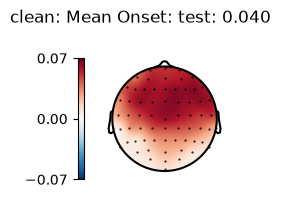

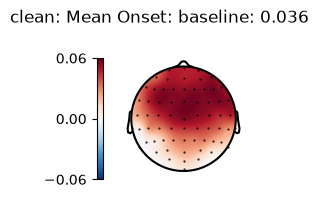

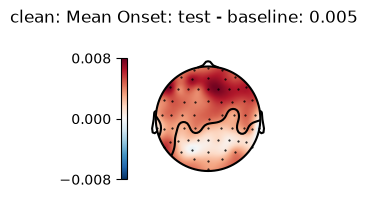

In [ ]:
# Onset unique contribution (clean)
# Brodbeck et al. 2020 ran this comparison too: single-speaker onset unique contribution, t = 12.00, p <= .001.
data, diff, result = compute_unique_contribution(FULL_CLEAN, onset(ATTEND), 'clean')
show_topomap_trio(data, diff, result, 'Onset', 'clean', onset(ATTEND))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Onset (clean): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, 2 clusters, p = .002>

Onset (clean): ROI unique contribution t(12) = 2.680, p = 0.0100


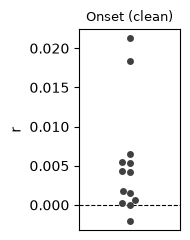

In [ ]:
p = show_subject_swarm(diff, 'Onset', 'clean')

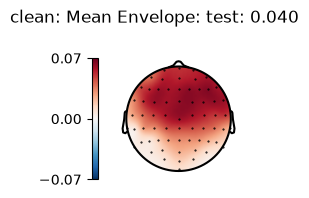

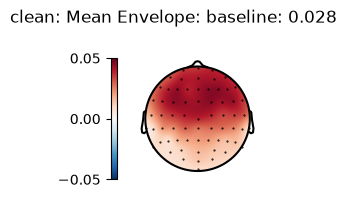

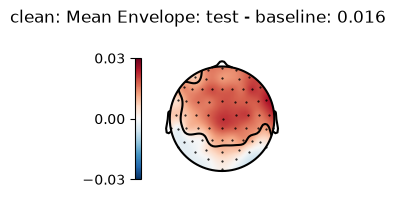

In [ ]:
# Envelope unique contribution (clean)
# Brodbeck et al. 2020 ran this comparison too: single-speaker envelope unique contribution, t = 9.39, p <= .001.
data, diff, result = compute_unique_contribution(FULL_CLEAN, envelope(ATTEND), 'clean')
show_topomap_trio(data, diff, result, 'Envelope', 'clean', envelope(ATTEND))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Envelope (clean): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, 1 clusters, p = .008>

Envelope (clean): ROI unique contribution t(12) = 2.962, p = 0.0059


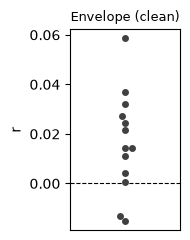

In [ ]:
p = show_subject_swarm(diff, 'Envelope', 'clean')

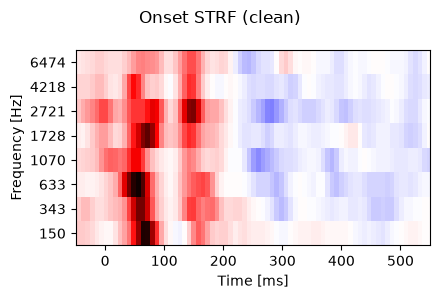

In [ ]:
# Onset STRF (clean)
strf = extract_strf(data_full, 'gammatone_on_8')
p = plot.Array(strf * 1e3, title='Onset STRF (clean)', xlim=(-0.050, 0.550))

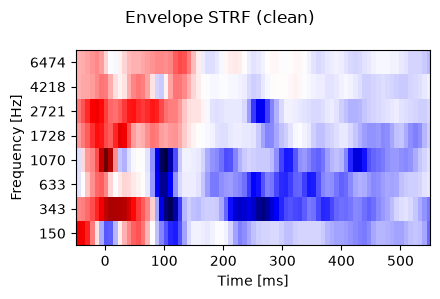

In [ ]:
# Envelope STRF (clean)
strf = extract_strf(data_full, 'gammatone_8')
p = plot.Array(strf * 1e3, title='Envelope STRF (clean)', xlim=(-0.050, 0.550))

In [ ]:
# Onset peak amplitude & timing (clean)
# Brodbeck et al. 2020 ran this comparison too: onset STRF positive peak ~65ms, negative peak ~126ms.
data = extract_trf(data_full, 'gammatone_on_8')
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Onset (clean) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Onset (clean) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

Onset (clean) positive peak: 88 ms, amp 0.003823
Onset (clean) negative peak: 136 ms, amp -0.0001337


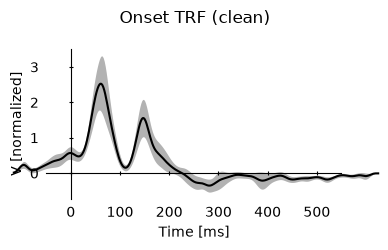

In [ ]:
# The TRF waveform the peaks above were measured from - same
# smoothed, ROI-averaged, frequency-summed response as 'data'.
p = plot.UTSStat('trf_sm*1e3', data=data, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550), title='Onset TRF (clean)')

In [ ]:
# Envelope peak amplitude & timing (clean)
data = extract_trf(data_full, 'gammatone_8')
data = add_peak(data, 'positive', ENVELOPE_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ENVELOPE_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Envelope (clean) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Envelope (clean) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

Envelope (clean) positive peak: 73 ms, amp 0.001839
Envelope (clean) negative peak: 156 ms, amp -0.002373


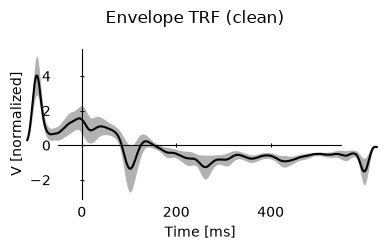

In [ ]:
# The TRF waveform the peaks above were measured from - same
# smoothed, ROI-averaged, frequency-summed response as 'data'.
p = plot.UTSStat('trf_sm*1e3', data=data, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550), title='Envelope TRF (clean)')

## Diotic

In [ ]:
# Loaded once here, reused by every unique-contribution/STRF/peak/
# waveform/attention-effect cell in this section - each one just
# reads a different predictor column out of this same fit instead
# of re-running the (expensive) TRF fit on FULL_BASE again.
data_full = e.load_trfs('all', FULL_BASE, epoch='diotic', **PARAMETERS)

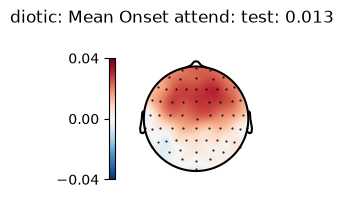

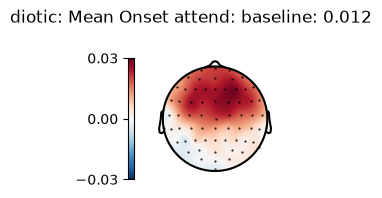

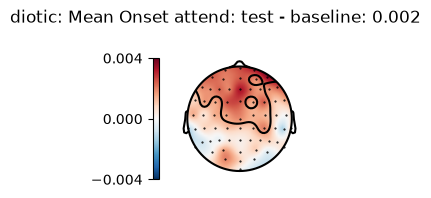

In [ ]:
# Onset attend unique contribution (diotic)
# Brodbeck et al. 2020 ran this comparison too: attended onsets unique contribution, t = 6.32, p < .001.
data, diff, result = compute_unique_contribution(FULL_BASE, onset(ATTEND), 'diotic')
show_topomap_trio(data, diff, result, 'Onset attend', 'diotic', onset(ATTEND))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Onset attend (diotic): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, 2 clusters, p < .001>

Onset attend (diotic): ROI unique contribution t(12) = 2.904, p = 0.0066


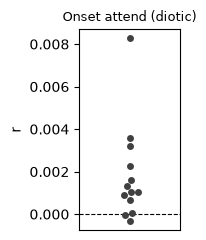

In [ ]:
p = show_subject_swarm(diff, 'Onset attend', 'diotic')

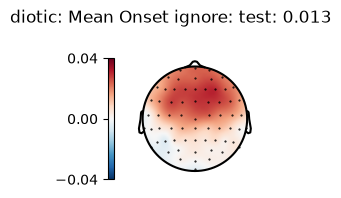

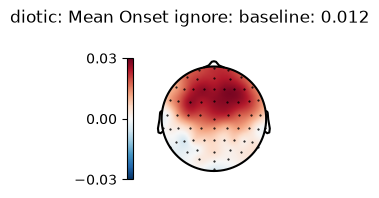

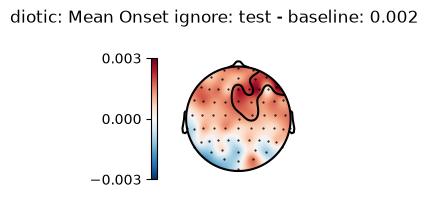

In [ ]:
# Onset ignore unique contribution (diotic)
# Brodbeck et al. 2020 ran this comparison too: ignored onsets unique contribution, t = 6.70, p < .001 - the ignored speaker is tracked separately.
data, diff, result = compute_unique_contribution(FULL_BASE, onset(IGNORE), 'diotic')
show_topomap_trio(data, diff, result, 'Onset ignore', 'diotic', onset(IGNORE))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Onset ignore (diotic): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, 2 clusters, p = .038>

Onset ignore (diotic): ROI unique contribution t(12) = 1.880, p = 0.0423


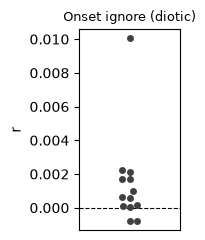

In [ ]:
p = show_subject_swarm(diff, 'Onset ignore', 'diotic')

/Users/joshuaighalo/Github Repositories/cocktail-cortical/analysis/experiment.py:957: UserWarning: Warning: converting a masked element to nan.
  mean_value = float(data.mean())


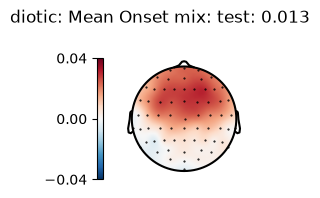

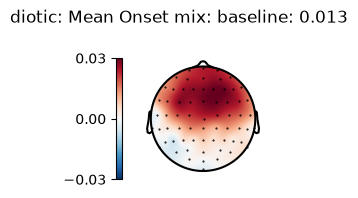

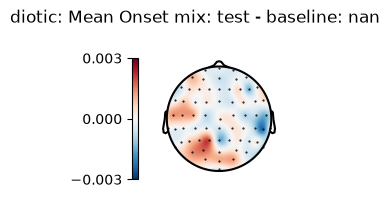

In [ ]:
# Onset mix unique contribution (diotic)
# Brodbeck et al. 2020 ran this comparison too: mixture onsets unique contribution, t = 8.61, p < .001.
data, diff, result = compute_unique_contribution(FULL_BASE, onset(MIX), 'diotic')
show_topomap_trio(data, diff, result, 'Onset mix', 'diotic', onset(MIX))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Onset mix (diotic): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, 2 clusters, p = .336>

Onset mix (diotic): ROI unique contribution t(12) = -0.048, p = 0.5187


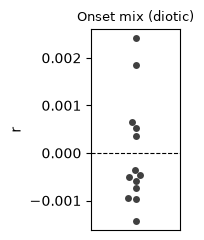

In [ ]:
p = show_subject_swarm(diff, 'Onset mix', 'diotic')

/Users/joshuaighalo/Github Repositories/cocktail-cortical/analysis/experiment.py:957: UserWarning: Warning: converting a masked element to nan.
  mean_value = float(data.mean())


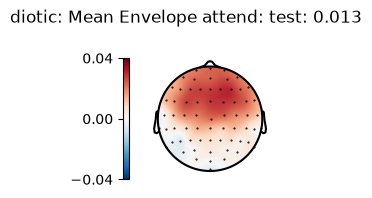

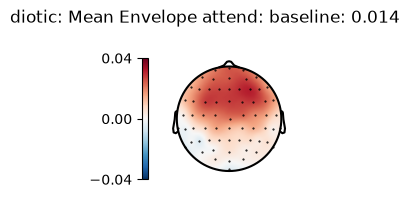

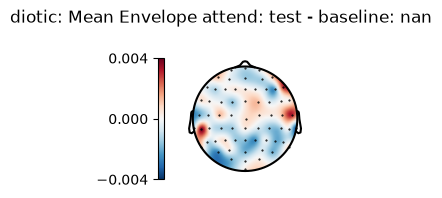

In [ ]:
# Envelope attend unique contribution (diotic)
# Brodbeck et al. 2020 ran this comparison too: attended envelope unique contribution, t = 7.37, p < .001.
data, diff, result = compute_unique_contribution(FULL_BASE, envelope(ATTEND), 'diotic')
show_topomap_trio(data, diff, result, 'Envelope attend', 'diotic', envelope(ATTEND))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Envelope attend (diotic): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, no clusters>

Envelope attend (diotic): ROI unique contribution t(12) = -0.170, p = 0.5660


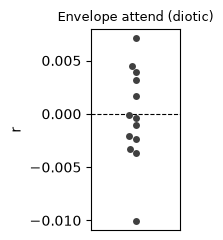

In [ ]:
p = show_subject_swarm(diff, 'Envelope attend', 'diotic')

/Users/joshuaighalo/Github Repositories/cocktail-cortical/analysis/experiment.py:957: UserWarning: Warning: converting a masked element to nan.
  mean_value = float(data.mean())


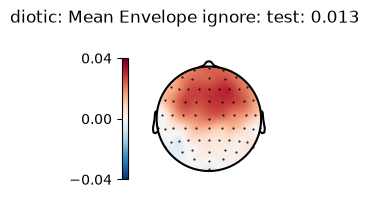

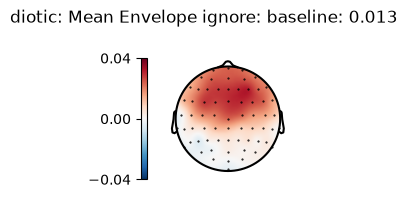

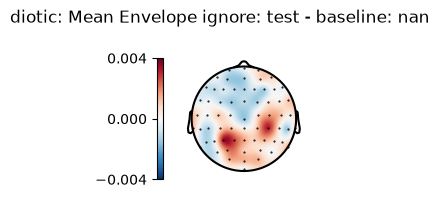

In [ ]:
# Envelope ignore unique contribution (diotic)
# Brodbeck et al. 2020 ran this comparison too: ignored envelope unique contribution, t = 6.28, p < .001 - the ignored speaker's envelope is tracked separately too.
data, diff, result = compute_unique_contribution(FULL_BASE, envelope(IGNORE), 'diotic')
show_topomap_trio(data, diff, result, 'Envelope ignore', 'diotic', envelope(IGNORE))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Envelope ignore (diotic): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, 2 clusters, p = .181>

Envelope ignore (diotic): ROI unique contribution t(12) = -0.419, p = 0.6589


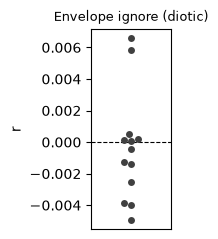

In [ ]:
p = show_subject_swarm(diff, 'Envelope ignore', 'diotic')

/Users/joshuaighalo/Github Repositories/cocktail-cortical/analysis/experiment.py:957: UserWarning: Warning: converting a masked element to nan.
  mean_value = float(data.mean())


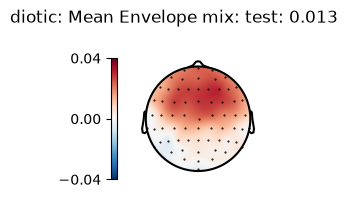

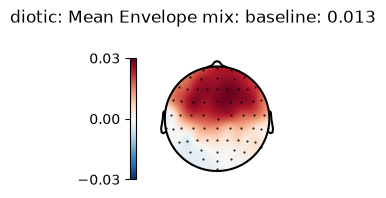

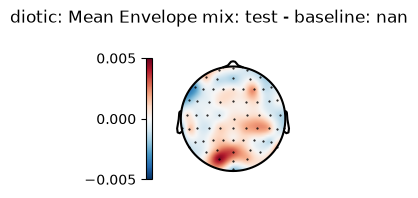

In [ ]:
# Envelope mix unique contribution (diotic)
# Brodbeck et al. 2020 ran this comparison too: mixture envelope unique contribution, t = 5.70, p < .001.
data, diff, result = compute_unique_contribution(FULL_BASE, envelope(MIX), 'diotic')
show_topomap_trio(data, diff, result, 'Envelope mix', 'diotic', envelope(MIX))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Envelope mix (diotic): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, 1 clusters, p = .482>

Envelope mix (diotic): ROI unique contribution t(12) = -0.003, p = 0.5013


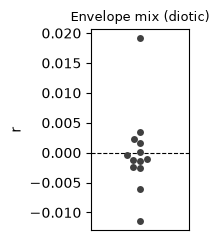

In [ ]:
p = show_subject_swarm(diff, 'Envelope mix', 'diotic')

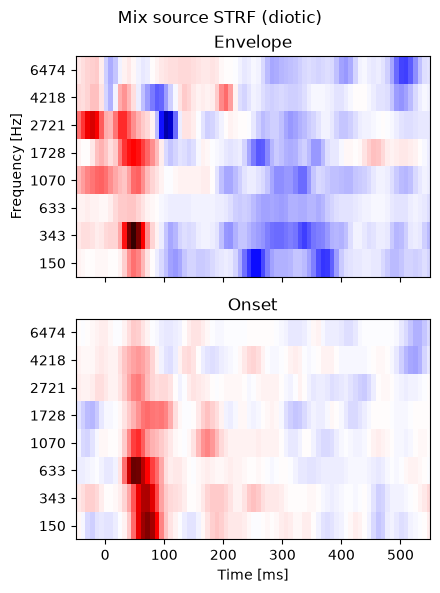

In [ ]:
# Mix source STRF: envelope + onset (diotic)
envelope_strf = extract_strf(data_full, 'mix_gammatone_8')
onset_strf = extract_strf(data_full, 'mix_gammatone_on_8')
p = plot.Array([envelope_strf * 1e3, onset_strf * 1e3], axtitle=['Envelope', 'Onset'],
                title='Mix source STRF (diotic)', xlim=(-0.050, 0.550))

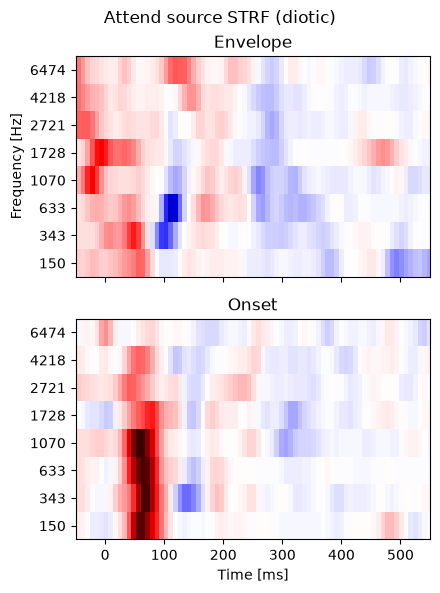

In [ ]:
# Attend source STRF: envelope + onset (diotic)
envelope_strf = extract_strf(data_full, 'gammatone_8')
onset_strf = extract_strf(data_full, 'gammatone_on_8')
p = plot.Array([envelope_strf * 1e3, onset_strf * 1e3], axtitle=['Envelope', 'Onset'],
                title='Attend source STRF (diotic)', xlim=(-0.050, 0.550))

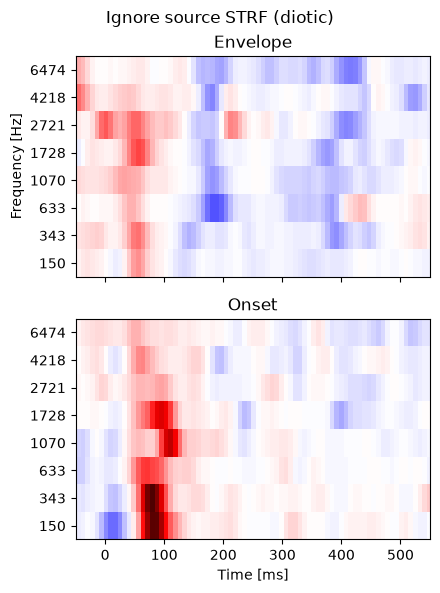

In [ ]:
# Ignore source STRF: envelope + onset (diotic)
envelope_strf = extract_strf(data_full, 'bg_gammatone_8')
onset_strf = extract_strf(data_full, 'bg_gammatone_on_8')
p = plot.Array([envelope_strf * 1e3, onset_strf * 1e3], axtitle=['Envelope', 'Onset'],
                title='Ignore source STRF (diotic)', xlim=(-0.050, 0.550))

In [ ]:
# Onset attend peak amplitude & timing (diotic)
data = extract_trf(data_full, 'gammatone_on_8')
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Onset attend (diotic) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Onset attend (diotic) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

Onset attend (diotic) positive peak: 77 ms, amp 0.002395
Onset attend (diotic) negative peak: 142 ms, amp -0.0004422


In [ ]:
# Onset ignore peak amplitude & timing (diotic)
data = extract_trf(data_full, 'bg_gammatone_on_8')
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Onset ignore (diotic) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Onset ignore (diotic) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

Onset ignore (diotic) positive peak: 83 ms, amp 0.001875
Onset ignore (diotic) negative peak: 149 ms, amp -0.0001174


In [ ]:
# Onset mix peak amplitude & timing (diotic)
data = extract_trf(data_full, 'mix_gammatone_on_8')
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Onset mix (diotic) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Onset mix (diotic) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

Onset mix (diotic) positive peak: 68 ms, amp 0.001748
Onset mix (diotic) negative peak: 125 ms, amp -0.0001259


In [ ]:
# Envelope attend peak amplitude & timing (diotic)
data = extract_trf(data_full, 'gammatone_8')
data = add_peak(data, 'positive', ENVELOPE_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ENVELOPE_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Envelope attend (diotic) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Envelope attend (diotic) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

Envelope attend (diotic) positive peak: 94 ms, amp 0.0008674
Envelope attend (diotic) negative peak: 143 ms, amp -0.0006356


In [ ]:
# Envelope ignore peak amplitude & timing (diotic)
data = extract_trf(data_full, 'bg_gammatone_8')
data = add_peak(data, 'positive', ENVELOPE_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ENVELOPE_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Envelope ignore (diotic) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Envelope ignore (diotic) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

Envelope ignore (diotic) positive peak: 67 ms, amp 0.0007042
Envelope ignore (diotic) negative peak: 166 ms, amp -0.0006253


In [ ]:
# Envelope mix peak amplitude & timing (diotic)
data = extract_trf(data_full, 'mix_gammatone_8')
data = add_peak(data, 'positive', ENVELOPE_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ENVELOPE_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Envelope mix (diotic) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Envelope mix (diotic) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

Envelope mix (diotic) positive peak: 84 ms, amp 0.001394
Envelope mix (diotic) negative peak: 153 ms, amp -0.0007725


In [ ]:
# Onset peak comparison across mix, attend, and ignore (diotic)
# Brodbeck et al. 2020 ran this comparison too: positive peak latency mixture 72ms, attended 81ms (t=4.47,p<.001), ignored 89ms (t=6.92,p<.001); negative peak latency mixture 138ms, attended 150ms (t=3.20,p=.004); positive peak amplitude bigger for mixture than attended (t=8.41) or ignored (t=7.66).
dss = []
for role_name, column in (('mix', 'mix_gammatone_on_8'), ('attend', 'gammatone_on_8'), ('ignore', 'bg_gammatone_on_8')):
    ds = extract_trf(data_full, column)
    ds[:, 'role'] = role_name
    dss.append(ds)
data = combine(dss)
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')

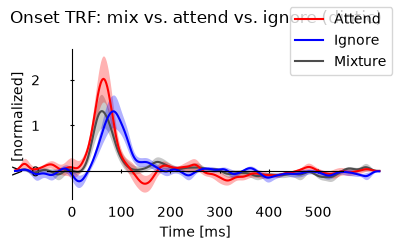

In [ ]:
# The onset TRF waveform mix/attend/ignore were each just measured
# from, overlaid so their shape and relative timing are visible
# directly, not just as extracted peak numbers below.
p = plot.UTSStat('trf_sm*1e3', 'role', data=data, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550),
                  title='Onset TRF: mix vs. attend vs. ignore (diotic)', labels=LABELS_ROLE, colors=COLORS_ROLE)

In [ ]:
print_peak_table(data, 'positive', 'role')
print_peak_table(data, 'negative', 'role')


positive peak
subject   role         time (ms)           amp
01        mix                115      1.26e-05
02        mix                 50      0.001082
03        mix                 56      0.003294
04        mix                 84      0.001265
05        mix                 62     0.0009321
06        mix                 43      0.001185
07        mix                 80      0.001515
08        mix                 54      0.003597
09        mix                 78      0.003072
10        mix                 60      0.003965
11        mix                 74      0.001326
12        mix                 72     0.0001453
13        mix                 54      0.001334
01        attend              45     6.319e-06
02        attend              60      0.005602
03        attend              56      0.001412
04        attend              50      0.002805
05        attend              60      0.004605
06        attend             181     0.0009453
07        attend              88     0.000509

In [ ]:
display(test.pairwise('positive_time', 'role', match='subject', data=data, corr=False, title='onset positive peak latency: mix vs. attend vs. ignore'))
display(test.pairwise('negative_time', 'role', match='subject', data=data, corr=False, title='onset negative peak latency: mix vs. attend vs. ignore'))

,attend,ignore
mix,t12 = -0.68 p = .511,t12 = -1.64 p = .126
attend,,t12 = -0.56 p = .583


,attend,ignore
mix,t12 = -1.02 p = .330,t12 = -1.13 p = .280
attend,,t12 = -0.30 p = .769


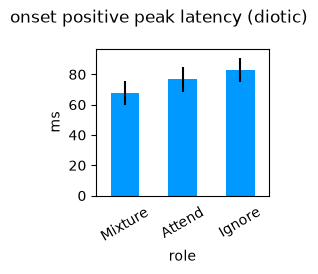

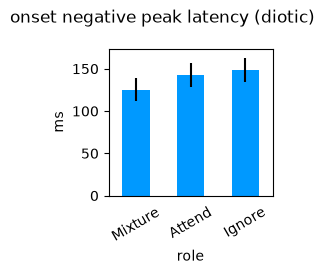

In [ ]:
p = plot.Barplot('positive_time', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='onset positive peak latency (diotic)')
p.set_xtick_rotation(30)
p = plot.Barplot('negative_time', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='onset negative peak latency (diotic)')
p.set_xtick_rotation(30)

In [ ]:
display(test.pairwise('positive_amp', 'role', match='subject', data=data, corr=False, title='onset positive peak amplitude: mix vs. attend vs. ignore'))
display(test.pairwise('negative_amp', 'role', match='subject', data=data, corr=False, title='onset negative peak amplitude: mix vs. attend vs. ignore'))

,attend,ignore
mix,t12 = -1.27 p = .227,t12 = -0.36 p = .726
attend,,t12 = 0.90 p = .386


,attend,ignore
mix,t12 = 1.68 p = .119,t12 = -0.09 p = .929
attend,,t12 = -1.68 p = .119


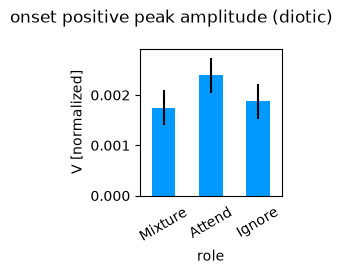

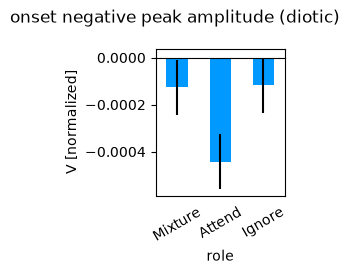

In [ ]:
p = plot.Barplot('positive_amp', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='onset positive peak amplitude (diotic)')
p.set_xtick_rotation(30)
p = plot.Barplot('negative_amp', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='onset negative peak amplitude (diotic)')
p.set_xtick_rotation(30)

In [ ]:
# Envelope peak comparison across mix, attend, and ignore (diotic)
dss = []
for role_name, column in (('mix', 'mix_gammatone_8'), ('attend', 'gammatone_8'), ('ignore', 'bg_gammatone_8')):
    ds = extract_trf(data_full, column)
    ds[:, 'role'] = role_name
    dss.append(ds)
data = combine(dss)
data = add_peak(data, 'positive', ENVELOPE_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ENVELOPE_NEGATIVE_PEAK_WINDOW, kind='min')

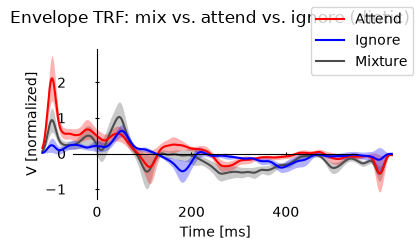

In [ ]:
# The envelope TRF waveform mix/attend/ignore were each just measured
# from, overlaid so their shape and relative timing are visible
# directly, not just as extracted peak numbers below.
p = plot.UTSStat('trf_sm*1e3', 'role', data=data, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550),
                  title='Envelope TRF: mix vs. attend vs. ignore (diotic)', labels=LABELS_ROLE, colors=COLORS_ROLE)

In [ ]:
print_peak_table(data, 'positive', 'role')
print_peak_table(data, 'negative', 'role')


positive peak
subject   role         time (ms)           amp
01        mix                117     1.104e-05
02        mix                 41    -4.382e-05
03        mix                164     0.0004876
04        mix                 41      0.003652
05        mix                 76     0.0003464
06        mix                 64     0.0001566
07        mix                 52      0.004692
08        mix                 41     0.0003857
09        mix                 64     0.0007402
10        mix                 45       0.00358
11        mix                142    -0.0002536
12        mix                 52      0.001911
13        mix                199      0.002462
01        attend              89     4.236e-05
02        attend              41     0.0003112
03        attend             148     0.0006959
04        attend             138      0.001575
05        attend              41    -0.0001004
06        attend             160      0.002459
07        attend              62     0.000511

In [ ]:
display(test.pairwise('positive_time', 'role', match='subject', data=data, corr=False, title='envelope positive peak latency: mix vs. attend vs. ignore'))
display(test.pairwise('negative_time', 'role', match='subject', data=data, corr=False, title='envelope negative peak latency: mix vs. attend vs. ignore'))

,attend,ignore
mix,t12 = -0.42 p = .685,t12 = 1.34 p = .205
attend,,t12 = 1.62 p = .132


,attend,ignore
mix,t12 = 0.71 p = .489,t12 = -0.87 p = .400
attend,,t12 = -1.36 p = .198


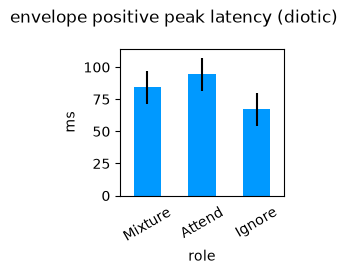

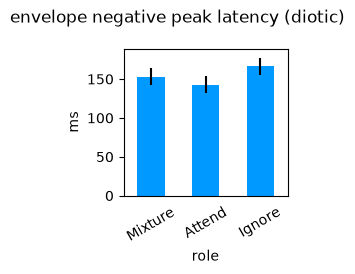

In [ ]:
p = plot.Barplot('positive_time', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='envelope positive peak latency (diotic)')
p.set_xtick_rotation(30)
p = plot.Barplot('negative_time', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='envelope negative peak latency (diotic)')
p.set_xtick_rotation(30)

In [ ]:
display(test.pairwise('positive_amp', 'role', match='subject', data=data, corr=False, title='envelope positive peak amplitude: mix vs. attend vs. ignore'))
display(test.pairwise('negative_amp', 'role', match='subject', data=data, corr=False, title='envelope negative peak amplitude: mix vs. attend vs. ignore'))

,attend,ignore
mix,t12 = 1.28 p = .225,t12 = 1.63 p = .130
attend,,t12 = 0.57 p = .579


,attend,ignore
mix,t12 = -0.27 p = .793,t12 = -0.26 p = .797
attend,,t12 = -0.02 p = .985


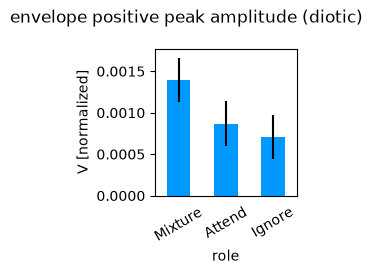

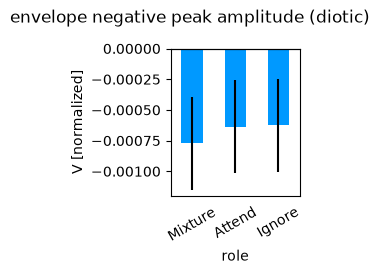

In [ ]:
p = plot.Barplot('positive_amp', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='envelope positive peak amplitude (diotic)')
p.set_xtick_rotation(30)
p = plot.Barplot('negative_amp', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='envelope negative peak amplitude (diotic)')
p.set_xtick_rotation(30)

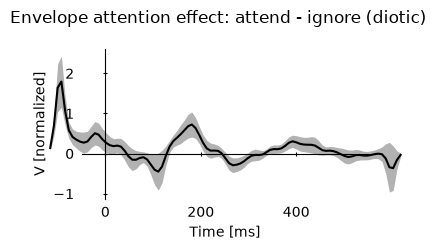

In [ ]:
# Envelope attention effect: attend - ignore (diotic)
# Brodbeck et al. 2020 ran this comparison too: envelope attention-effect difference wave: negative bump ~100ms, positive bump ~200ms, starting almost immediately.
attend_trf = data_full['gammatone_8'].sum('frequency').mean(sensor=ROI)
ignore_trf = data_full['bg_gammatone_8'].sum('frequency').mean(sensor=ROI)
attention_effect = attend_trf - ignore_trf
p = plot.UTSStat(attention_effect * 1e3, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550), title='Envelope attention effect: attend - ignore (diotic)')

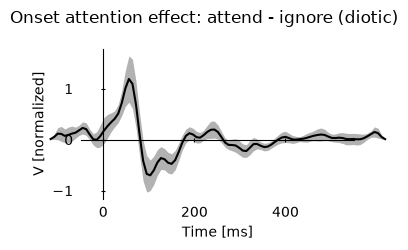

In [ ]:
# Onset attention effect: attend - ignore (diotic)
# Brodbeck et al. 2020 ran this comparison too: onset attention effect appears later than the envelope's, once the masked-onset response develops (see the masked-onset section below).
attend_trf = data_full['gammatone_on_8'].sum('frequency').mean(sensor=ROI)
ignore_trf = data_full['bg_gammatone_on_8'].sum('frequency').mean(sensor=ROI)
attention_effect = attend_trf - ignore_trf
p = plot.UTSStat(attention_effect * 1e3, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550), title='Onset attention effect: attend - ignore (diotic)')

## Diotic (overt onsets)

/Users/joshuaighalo/Github Repositories/cocktail-cortical/analysis/experiment.py:957: UserWarning: Warning: converting a masked element to nan.
  mean_value = float(data.mean())


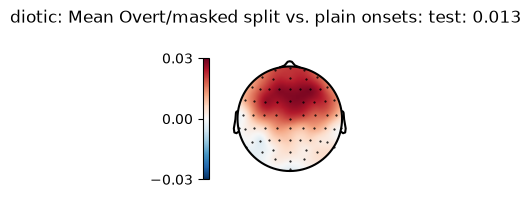

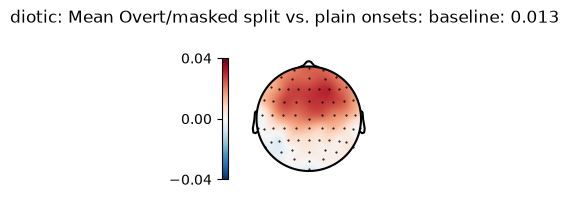

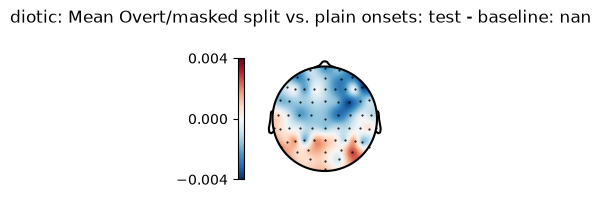

In [ ]:
# Overt/masked split vs. plain onsets (diotic)
# overt/masked = the split of an onset predictor into its overt and masked half.
# Brodbeck et al. 2020 ran this comparison too: splitting onsets into overt/masked significantly improved the model overall, t = 6.81, p < .001.

# FULL_BASE   = Eatt + Oatt + Eign + Oign + Emix + Omix
# FULL_MASKED = Eatt + Oatt_overt + Oatt_masked + Eign + Oign_overt + Oign_masked + Emix + Omix
#
# Comparison: FULL_MASKED > FULL_BASE
#   (does replacing Oatt/Oign with their overt+masked split improve the
#   fit over the plain-onset model?)
#
# Full predictor names:
# FULL_MASKED (test model):
#   gammatone-8 + gammatone-on-overt-8 + gammatone-on-masked-8
#   + bg~gammatone-8 + bg~gammatone-on-overt-8 + bg~gammatone-on-masked-8
#   + mix~gammatone-8 + mix~gammatone-on-8
#
# FULL_BASE (baseline model):
#   gammatone-8 + gammatone-on-8
#   + bg~gammatone-8 + bg~gammatone-on-8
#   + mix~gammatone-8 + mix~gammatone-on-8

data, diff, result = compute_direct_comparison(FULL_MASKED, FULL_BASE, 'diotic')
show_topomap_trio(data, diff, result, 'Overt/masked split vs. plain onsets', 'diotic', None)

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Overt/masked split vs. plain onsets (diotic): ROI model comparison t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, no clusters>

Overt/masked split vs. plain onsets (diotic): ROI model comparison t(12) = -1.887, p = 0.9582


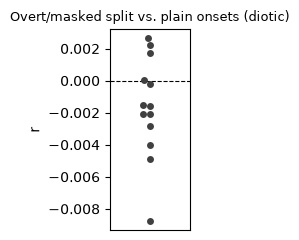

In [ ]:
p = show_subject_swarm(diff, 'Overt/masked split vs. plain onsets', 'diotic')

In [ ]:
# Loaded once here, reused by every STRF/peak/waveform/attention-
# effect/masking-comparison cell in both this subsection and "masked
# onset" below - same reasoning as data_full above, for FULL_MASKED.
data_masked = e.load_trfs('all', FULL_MASKED, epoch='diotic', **PARAMETERS)

/Users/joshuaighalo/Github Repositories/cocktail-cortical/analysis/experiment.py:957: UserWarning: Warning: converting a masked element to nan.
  mean_value = float(data.mean())


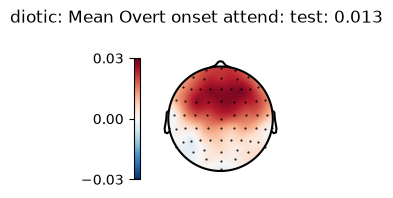

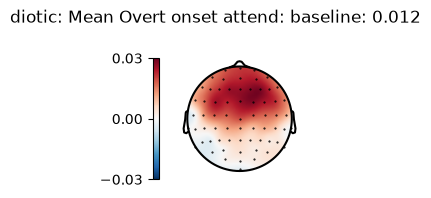

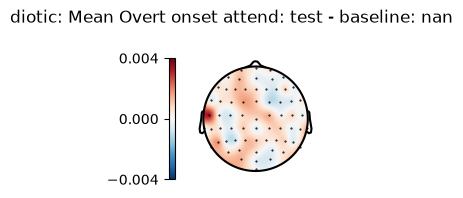

In [ ]:
# Overt onset attend unique contribution (diotic)
# Brodbeck et al. 2020 ran this comparison too: attended overt onsets unique contribution, t = 3.34, p = .027.
data, diff, result = compute_unique_contribution(FULL_MASKED, overt_onset(ATTEND), 'diotic')
show_topomap_trio(data, diff, result, 'Overt onset attend', 'diotic', overt_onset(ATTEND))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Overt onset attend (diotic): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, 5 clusters, p = .151>

Overt onset attend (diotic): ROI unique contribution t(12) = 0.932, p = 0.1849


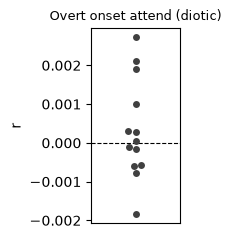

In [ ]:
p = show_subject_swarm(diff, 'Overt onset attend', 'diotic')

/Users/joshuaighalo/Github Repositories/cocktail-cortical/analysis/experiment.py:957: UserWarning: Warning: converting a masked element to nan.
  mean_value = float(data.mean())


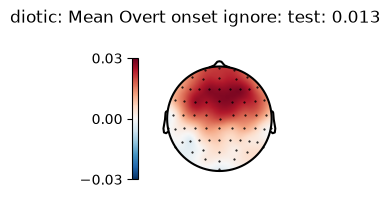

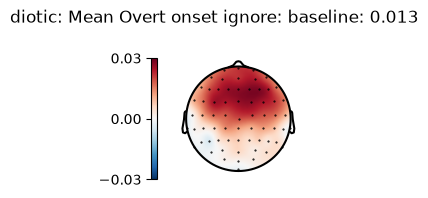

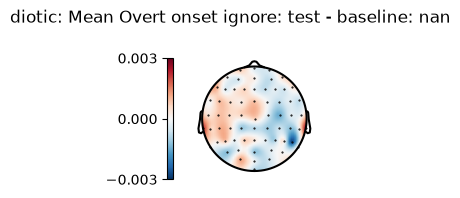

In [ ]:
# Overt onset ignore unique contribution (diotic)
# Brodbeck et al. 2020 ran this comparison too: ignored overt onsets unique contribution, t = 3.82, p = .016.
data, diff, result = compute_unique_contribution(FULL_MASKED, overt_onset(IGNORE), 'diotic')
show_topomap_trio(data, diff, result, 'Overt onset ignore', 'diotic', overt_onset(IGNORE))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Overt onset ignore (diotic): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, 1 clusters, p = .561>

Overt onset ignore (diotic): ROI unique contribution t(12) = -0.032, p = 0.5126


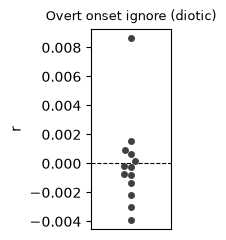

In [ ]:
p = show_subject_swarm(diff, 'Overt onset ignore', 'diotic')

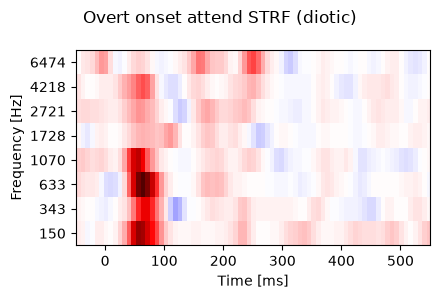

In [ ]:
# Overt onset attend STRF (diotic)
strf = extract_strf(data_masked, 'gammatone_on_overt_8')
p = plot.Array(strf * 1e3, title='Overt onset attend STRF (diotic)', xlim=(-0.050, 0.550))

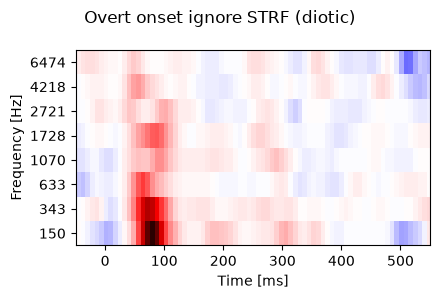

In [ ]:
# Overt onset ignore STRF (diotic)
strf = extract_strf(data_masked, 'bg_gammatone_on_overt_8')
p = plot.Array(strf * 1e3, title='Overt onset ignore STRF (diotic)', xlim=(-0.050, 0.550))

In [ ]:
# Overt onset attend peak amplitude & timing (diotic)
data = extract_trf(data_masked, 'gammatone_on_overt_8')
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Overt onset attend (diotic) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Overt onset attend (diotic) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

Overt onset attend (diotic) positive peak: 82 ms, amp 0.001735
Overt onset attend (diotic) negative peak: 132 ms, amp -0.0002131


In [ ]:
# Overt onset ignore peak amplitude & timing (diotic)
data = extract_trf(data_masked, 'bg_gammatone_on_overt_8')
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Overt onset ignore (diotic) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Overt onset ignore (diotic) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

Overt onset ignore (diotic) positive peak: 88 ms, amp 0.001345
Overt onset ignore (diotic) negative peak: 155 ms, amp -7.801e-05


In [ ]:
# Overt onset peak comparison across attend and ignore (diotic)
dss = []
for role_name, column in (('attend', 'gammatone_on_overt_8'), ('ignore', 'bg_gammatone_on_overt_8')):
    ds = extract_trf(data_masked, column)
    ds[:, 'role'] = role_name
    dss.append(ds)
data = combine(dss)
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')

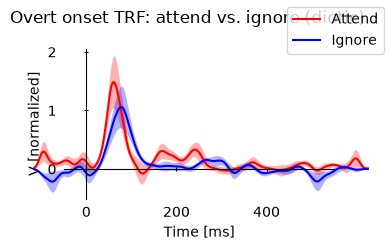

In [ ]:
# The overt onset TRF waveform attend/ignore were each just measured
# from, overlaid so their shape and relative timing are visible
# directly, not just as extracted peak numbers below.
p = plot.UTSStat('trf_sm*1e3', 'role', data=data, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550),
                  title='Overt onset TRF: attend vs. ignore (diotic)', labels={'attend': 'Attend', 'ignore': 'Ignore'}, colors={'attend': 'red', 'ignore': 'blue'})

In [ ]:
print_peak_table(data, 'positive', 'role')
print_peak_table(data, 'negative', 'role')


positive peak
subject   role         time (ms)           amp
01        attend              91     6.333e-06
02        attend              56      0.003221
03        attend              54     0.0008109
04        attend             162       0.00141
05        attend              54      0.002105
06        attend             171      0.001346
07        attend              82      0.001007
08        attend              70      0.001106
09        attend              64      0.002404
10        attend              64      0.006245
11        attend              64       0.00183
12        attend              78     0.0004529
13        attend              52     0.0006124
01        ignore              41     2.485e-06
02        ignore              91     0.0003537
03        ignore              84      0.003482
04        ignore              93     9.847e-05
05        ignore              70      0.003394
06        ignore             199     0.0003545
07        ignore              74      0.00049

In [ ]:
display(test.pairwise('positive_time', 'role', match='subject', data=data, corr=False, title='overt onset positive peak latency: attend vs. ignore'))
display(test.pairwise('negative_time', 'role', match='subject', data=data, corr=False, title='overt onset negative peak latency: attend vs. ignore'))

,ignore
attend,t12 = -0.62 p = .550


,ignore
attend,t12 = -1.31 p = .215


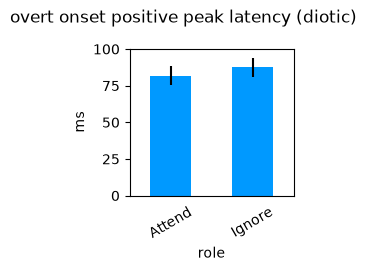

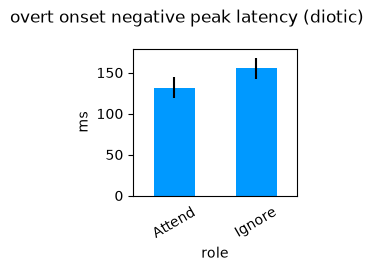

In [ ]:
p = plot.Barplot('positive_time', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='overt onset positive peak latency (diotic)')
p.set_xtick_rotation(30)
p = plot.Barplot('negative_time', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='overt onset negative peak latency (diotic)')
p.set_xtick_rotation(30)

In [ ]:
display(test.pairwise('positive_amp', 'role', match='subject', data=data, corr=False, title='overt onset positive peak amplitude: attend vs. ignore'))
display(test.pairwise('negative_amp', 'role', match='subject', data=data, corr=False, title='overt onset negative peak amplitude: attend vs. ignore'))

,ignore
attend,t12 = 0.68 p = .511


,ignore
attend,t12 = -0.81 p = .436


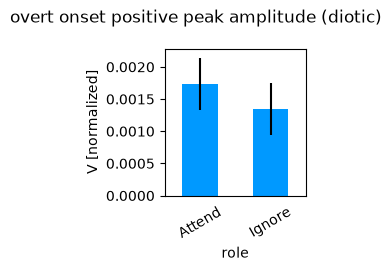

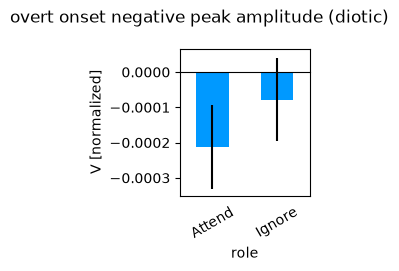

In [ ]:
p = plot.Barplot('positive_amp', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='overt onset positive peak amplitude (diotic)')
p.set_xtick_rotation(30)
p = plot.Barplot('negative_amp', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='overt onset negative peak amplitude (diotic)')
p.set_xtick_rotation(30)

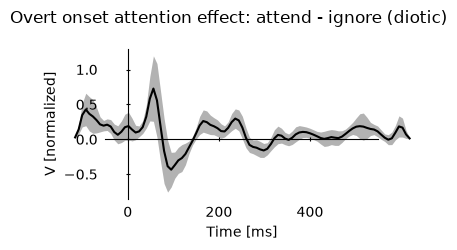

In [ ]:
# Overt onset attention effect: attend - ignore (diotic)
attend_trf = data_masked['gammatone_on_overt_8'].sum('frequency').mean(sensor=ROI)
ignore_trf = data_masked['bg_gammatone_on_overt_8'].sum('frequency').mean(sensor=ROI)
attention_effect = attend_trf - ignore_trf
p = plot.UTSStat(attention_effect * 1e3, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550), title='Overt onset attention effect: attend - ignore (diotic)')

## Diotic (masked onset)

/Users/joshuaighalo/Github Repositories/cocktail-cortical/analysis/experiment.py:957: UserWarning: Warning: converting a masked element to nan.
  mean_value = float(data.mean())


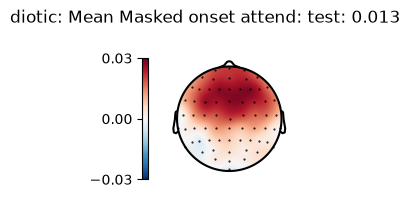

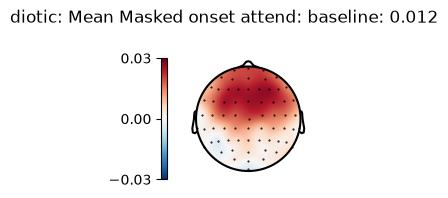

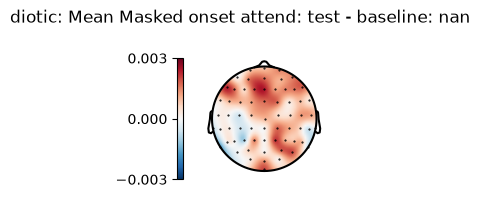

In [ ]:
# Masked onset attend unique contribution (diotic)
# Brodbeck et al. 2020 ran this comparison too: attended masked onsets unique contribution, t = 8.42, p < .001 - the strongest of the four masking predictors.
data, diff, result = compute_unique_contribution(FULL_MASKED, masked_onset(ATTEND), 'diotic')
show_topomap_trio(data, diff, result, 'Masked onset attend', 'diotic', masked_onset(ATTEND))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Masked onset attend (diotic): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, 3 clusters, p = .153>

Masked onset attend (diotic): ROI unique contribution t(12) = 1.620, p = 0.0656


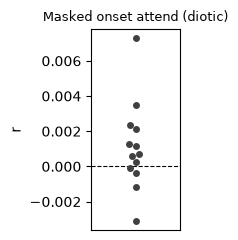

In [ ]:
p = show_subject_swarm(diff, 'Masked onset attend', 'diotic')

/Users/joshuaighalo/Github Repositories/cocktail-cortical/analysis/experiment.py:957: UserWarning: Warning: converting a masked element to nan.
  mean_value = float(data.mean())


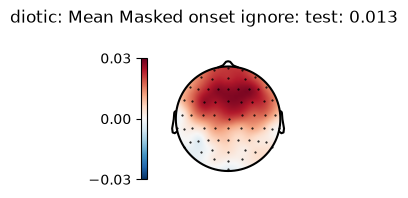

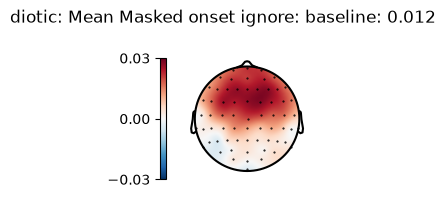

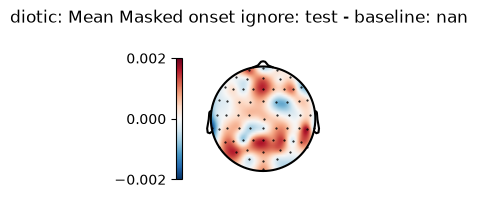

In [ ]:
# Masked onset ignore unique contribution (diotic)
# Brodbeck et al. 2020 ran this comparison too: ignored masked onsets unique contribution, t = 5.23, p < .001 - the brain recovers masked information even for the ignored speaker.
data, diff, result = compute_unique_contribution(FULL_MASKED, masked_onset(IGNORE), 'diotic')
show_topomap_trio(data, diff, result, 'Masked onset ignore', 'diotic', masked_onset(IGNORE))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Masked onset ignore (diotic): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, 3 clusters, p = .417>

Masked onset ignore (diotic): ROI unique contribution t(12) = 0.959, p = 0.1783


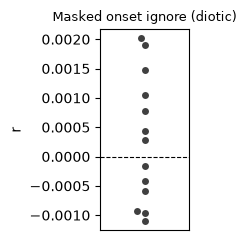

In [ ]:
p = show_subject_swarm(diff, 'Masked onset ignore', 'diotic')

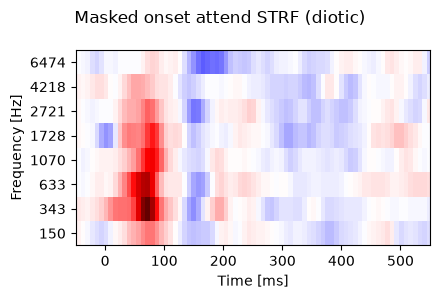

In [ ]:
# Masked onset attend STRF (diotic)
strf = extract_strf(data_masked, 'gammatone_on_masked_8')
p = plot.Array(strf * 1e3, title='Masked onset attend STRF (diotic)', xlim=(-0.050, 0.550))

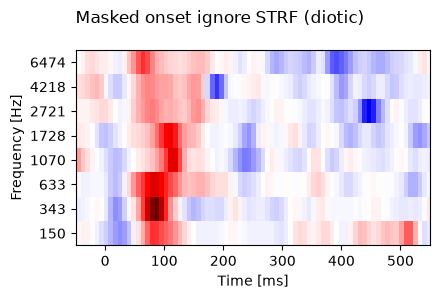

In [ ]:
# Masked onset ignore STRF (diotic)
strf = extract_strf(data_masked, 'bg_gammatone_on_masked_8')
p = plot.Array(strf * 1e3, title='Masked onset ignore STRF (diotic)', xlim=(-0.050, 0.550))

In [ ]:
# Masked onset attend peak amplitude & timing (diotic)
data = extract_trf(data_masked, 'gammatone_on_masked_8')
data = add_peak(data, 'positive', MASKED_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', MASKED_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Masked onset attend (diotic) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Masked onset attend (diotic) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

Masked onset attend (diotic) positive peak: 90 ms, amp 0.001303
Masked onset attend (diotic) negative peak: 161 ms, amp -0.0005202


In [ ]:
# Masked onset ignore peak amplitude & timing (diotic)
data = extract_trf(data_masked, 'bg_gammatone_on_masked_8')
data = add_peak(data, 'positive', MASKED_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', MASKED_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Masked onset ignore (diotic) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Masked onset ignore (diotic) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

Masked onset ignore (diotic) positive peak: 89 ms, amp 0.001172
Masked onset ignore (diotic) negative peak: 137 ms, amp -0.0002829


In [ ]:
# Masked onset peak comparison across attend and ignore (diotic)
dss = []
for role_name, column in (('attend', 'gammatone_on_masked_8'), ('ignore', 'bg_gammatone_on_masked_8')):
    ds = extract_trf(data_masked, column)
    ds[:, 'role'] = role_name
    dss.append(ds)
data = combine(dss)
data = add_peak(data, 'positive', MASKED_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', MASKED_NEGATIVE_PEAK_WINDOW, kind='min')

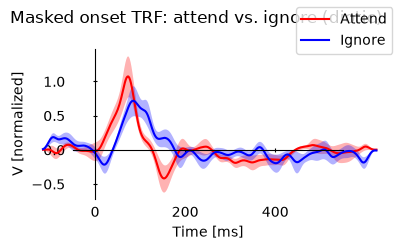

In [ ]:
# The masked onset TRF waveform attend/ignore were each just measured
# from, overlaid so their shape and relative timing are visible
# directly, not just as extracted peak numbers below.
p = plot.UTSStat('trf_sm*1e3', 'role', data=data, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550),
                  title='Masked onset TRF: attend vs. ignore (diotic)', labels={'attend': 'Attend', 'ignore': 'Ignore'}, colors={'attend': 'red', 'ignore': 'blue'})

In [ ]:
print_peak_table(data, 'positive', 'role')
print_peak_table(data, 'negative', 'role')


positive peak
subject   role         time (ms)           amp
01        attend             193     1.513e-09
02        attend              68       0.00308
03        attend              66     0.0006023
04        attend              43      0.001973
05        attend              72      0.002507
06        attend             191     0.0004964
07        attend             103     0.0001825
08        attend              72      0.002805
09        attend              41     0.0005917
10        attend              80      0.001038
11        attend              76      0.001291
12        attend              84     0.0003982
13        attend              78      0.001975
01        ignore             129     4.388e-05
02        ignore             107     0.0009237
03        ignore              88      0.001726
04        ignore             119     0.0001687
05        ignore              64      0.001007
06        ignore              70     0.0007589
07        ignore              76     0.000355

In [ ]:
display(test.pairwise('positive_time', 'role', match='subject', data=data, corr=False, title='masked onset positive peak latency: attend vs. ignore'))
display(test.pairwise('negative_time', 'role', match='subject', data=data, corr=False, title='masked onset negative peak latency: attend vs. ignore'))

,ignore
attend,t12 = 0.03 p = .976


,ignore
attend,t12 = 1.24 p = .238


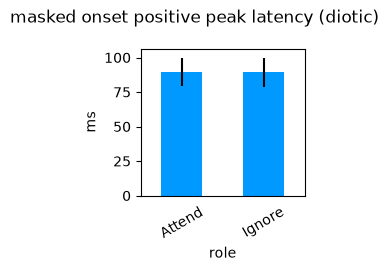

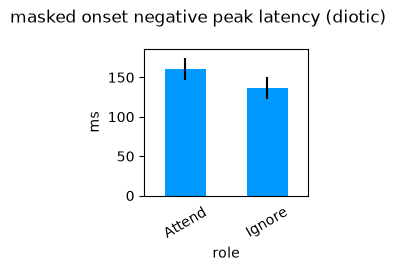

In [ ]:
p = plot.Barplot('positive_time', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='masked onset positive peak latency (diotic)')
p.set_xtick_rotation(30)
p = plot.Barplot('negative_time', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='masked onset negative peak latency (diotic)')
p.set_xtick_rotation(30)

In [ ]:
display(test.pairwise('positive_amp', 'role', match='subject', data=data, corr=False, title='masked onset positive peak amplitude: attend vs. ignore'))
display(test.pairwise('negative_amp', 'role', match='subject', data=data, corr=False, title='masked onset negative peak amplitude: attend vs. ignore'))

,ignore
attend,t12 = 0.36 p = .722


,ignore
attend,t12 = -1.19 p = .257


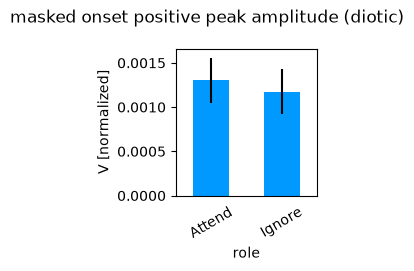

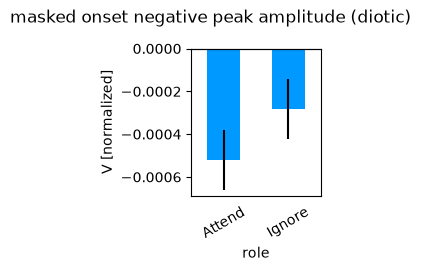

In [ ]:
p = plot.Barplot('positive_amp', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='masked onset positive peak amplitude (diotic)')
p.set_xtick_rotation(30)
p = plot.Barplot('negative_amp', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='masked onset negative peak amplitude (diotic)')
p.set_xtick_rotation(30)

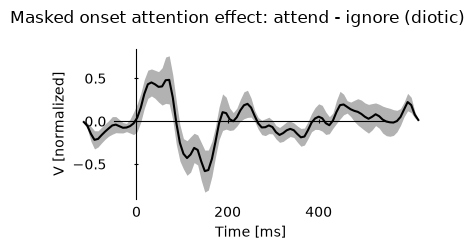

In [ ]:
# Masked onset attention effect: attend - ignore (diotic)
attend_trf = data_masked['gammatone_on_masked_8'].sum('frequency').mean(sensor=ROI)
ignore_trf = data_masked['bg_gammatone_on_masked_8'].sum('frequency').mean(sensor=ROI)
attention_effect = attend_trf - ignore_trf
p = plot.UTSStat(attention_effect * 1e3, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550), title='Masked onset attention effect: attend - ignore (diotic)')

In [ ]:
# Overt vs. masked peak comparison, attend (diotic)
# Brodbeck et al. 2020 ran this comparison too: attended overt 72ms vs. attended masked 91ms (t=2.85,p=.009); combined (not stream-split) late negative peak, overt 133ms vs. masked 182ms (t=4.45,p<.001).
dss = []
for masking, column in (('overt', 'gammatone_on_overt_8'), ('masked', 'gammatone_on_masked_8')):
    ds = extract_trf(data_masked, column)
    ds[:, 'masking'] = masking
    dss.append(ds)
data = combine(dss)
data = add_peak(data, 'positive', MASKED_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', MASKED_NEGATIVE_PEAK_WINDOW, kind='min')

In [ ]:
print_peak_table(data, 'positive', 'masking')
print_peak_table(data, 'negative', 'masking')


positive peak
subject   masking      time (ms)           amp
01        overt               91     6.333e-06
02        overt               56      0.003221
03        overt               54     0.0008109
04        overt              162       0.00141
05        overt               54      0.002105
06        overt              171      0.001346
07        overt               82      0.001007
08        overt               70      0.001106
09        overt               64      0.002404
10        overt               64      0.006245
11        overt               64       0.00183
12        overt               78     0.0004529
13        overt               52     0.0006124
01        masked             193     1.513e-09
02        masked              68       0.00308
03        masked              66     0.0006023
04        masked              43      0.001973
05        masked              72      0.002507
06        masked             191     0.0004964
07        masked             103     0.000182

In [ ]:
display(test.pairwise('positive_time', 'masking', match='subject', data=data, corr=False, title='attend positive peak latency: overt vs. masked'))
display(test.pairwise('negative_time', 'masking', match='subject', data=data, corr=False, title='attend negative peak latency: overt vs. masked'))

,masked
overt,t12 = -0.60 p = .562


,masked
overt,t12 = -2.18* p = .050


In [ ]:
display(test.pairwise('positive_amp', 'masking', match='subject', data=data, corr=False, title='attend positive peak amplitude: overt vs. masked'))
display(test.pairwise('negative_amp', 'masking', match='subject', data=data, corr=False, title='attend negative peak amplitude: overt vs. masked'))

,masked
overt,t12 = 0.91 p = .379


,masked
overt,t12 = 1.36 p = .199


In [ ]:
# Overt vs. masked peak comparison, ignore (diotic)
# Brodbeck et al. 2020 ran this comparison too: ignored overt 83ms vs. ignored masked 97ms (t=6.11,p<.001); combined (not stream-split) late negative peak, overt 133ms vs. masked 182ms (t=4.45,p<.001).
dss = []
for masking, column in (('overt', 'bg_gammatone_on_overt_8'), ('masked', 'bg_gammatone_on_masked_8')):
    ds = extract_trf(data_masked, column)
    ds[:, 'masking'] = masking
    dss.append(ds)
data = combine(dss)
data = add_peak(data, 'positive', MASKED_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', MASKED_NEGATIVE_PEAK_WINDOW, kind='min')

In [ ]:
print_peak_table(data, 'positive', 'masking')
print_peak_table(data, 'negative', 'masking')


positive peak
subject   masking      time (ms)           amp
01        overt               41     2.485e-06
02        overt               91     0.0003537
03        overt               84      0.003482
04        overt               93     9.847e-05
05        overt               70      0.003394
06        overt              199     0.0003545
07        overt               74      0.000494
08        overt               62      0.002328
09        overt               80       0.00361
10        overt               88     0.0007363
11        overt               58      0.001313
12        overt              101     0.0003869
13        overt               97      0.000934
01        masked             129     4.388e-05
02        masked             107     0.0009237
03        masked              88      0.001726
04        masked             119     0.0001687
05        masked              64      0.001007
06        masked              70     0.0007589
07        masked              76     0.000355

In [ ]:
display(test.pairwise('positive_time', 'masking', match='subject', data=data, corr=False, title='ignore positive peak latency: overt vs. masked'))
display(test.pairwise('negative_time', 'masking', match='subject', data=data, corr=False, title='ignore negative peak latency: overt vs. masked'))

,masked
overt,t12 = -0.12 p = .903


,masked
overt,t12 = 0.70 p = .495


In [ ]:
display(test.pairwise('positive_amp', 'masking', match='subject', data=data, corr=False, title='ignore positive peak amplitude: overt vs. masked'))
display(test.pairwise('negative_amp', 'masking', match='subject', data=data, corr=False, title='ignore negative peak amplitude: overt vs. masked'))

,masked
overt,t12 = 0.46 p = .650


,masked
overt,t12 = 1.69 p = .116


In [ ]:
# Stream x masking interaction on peak amplitude (diotic)
# Brodbeck et al. 2020 ran this comparison too: stream x masking interaction, F(1,25) = 24.45, p < .001 - overt onsets show no early attention effect, masked onsets do.
dss = []
for stream_name, is_attend in (('attend', True), ('ignore', False)):
    for masking_name in ('overt', 'masked'):
        prefix = '' if is_attend else 'bg_'
        column = f'{prefix}gammatone_on_{masking_name}_8'
        ds = extract_trf(data_masked, column)
        ds[:, 'stream'] = stream_name
        ds[:, 'masking'] = masking_name
        dss.append(ds)
data = combine(dss)
data = add_peak(data, 'positive', MASKED_POSITIVE_PEAK_WINDOW, kind='max')
display(test.ANOVA('positive_amp', 'stream * masking * subject', data=data, title='stream x masking interaction (diotic)'))

<ANOVA: positive_amp ~ stream + masking + stream x masking + subject + stream x subject + masking x subject + stream x masking x subject
  
  stream x masking interaction (diotic)
  
                       SS   df     MS   MS(denom)   df(denom)         F      p
  ----------------------------------------------------------------------------
  stream             0.00    1   0.00        0.00          12   0.56      .467
  masking            0.00    1   0.00        0.00          12   1.28      .280
  stream x masking   0.00    1   0.00        0.00          12   0.15      .704
  ----------------------------------------------------------------------------
  Total              0.00   51
>

## Diotic (intensity-level control)

/Users/joshuaighalo/Github Repositories/cocktail-cortical/analysis/experiment.py:957: UserWarning: Warning: converting a masked element to nan.
  mean_value = float(data.mean())


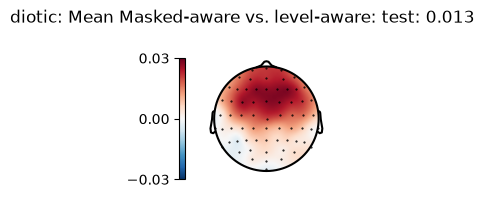

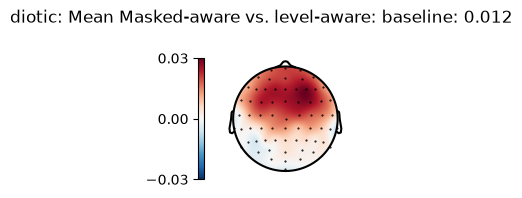

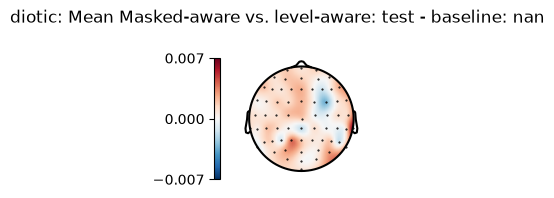

In [ ]:
# Masked-aware vs. level-aware (diotic)
# Brodbeck et al. 2020 ran this comparison too: the ignored-speaker-aware model still beat the loudness-only model, t = 9.21, p < .001 - the masking effect isn't just about volume.
data, diff, result = compute_direct_comparison(FULL_MASKED, LEVEL_AWARE, 'diotic')
show_topomap_trio(data, diff, result, 'Masked-aware vs. level-aware', 'diotic', None)

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Masked-aware vs. level-aware (diotic): ROI model comparison t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, 1 clusters, p = .399>

Masked-aware vs. level-aware (diotic): ROI model comparison t(12) = 0.468, p = 0.3242


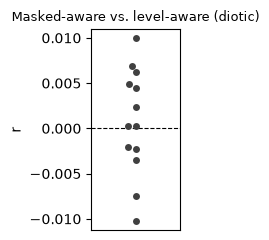

In [ ]:
p = show_subject_swarm(diff, 'Masked-aware vs. level-aware', 'diotic')

## Dichotic Left

In [ ]:
# Loaded once here, reused by every unique-contribution/STRF/peak/
# waveform/attention-effect cell in this section - each one just
# reads a different predictor column out of this same fit instead
# of re-running the (expensive) TRF fit on FULL_BASE again.
data_full = e.load_trfs('all', FULL_BASE, epoch='dichotic-left', **PARAMETERS)

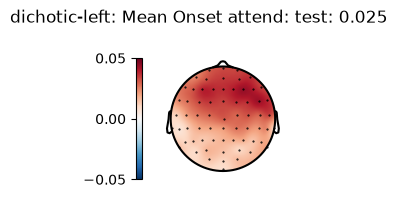

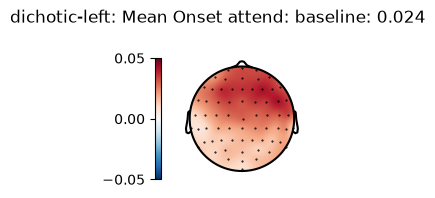

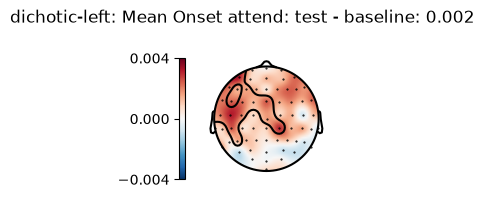

In [ ]:
# Onset attend unique contribution (dichotic-left)
# Brodbeck et al. 2020 ran this comparison too: attended onsets unique contribution, t = 6.32, p < .001.
data, diff, result = compute_unique_contribution(FULL_BASE, onset(ATTEND), 'dichotic-left')
show_topomap_trio(data, diff, result, 'Onset attend', 'dichotic-left', onset(ATTEND))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Onset attend (dichotic-left): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, 4 clusters, p = .016>

Onset attend (dichotic-left): ROI unique contribution t(12) = 2.199, p = 0.0241


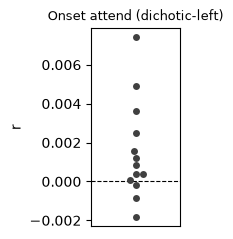

In [ ]:
p = show_subject_swarm(diff, 'Onset attend', 'dichotic-left')

/Users/joshuaighalo/Github Repositories/cocktail-cortical/analysis/experiment.py:957: UserWarning: Warning: converting a masked element to nan.
  mean_value = float(data.mean())


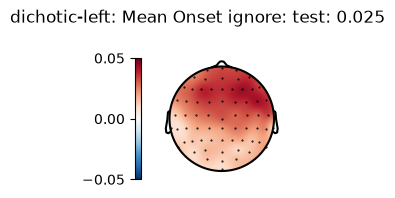

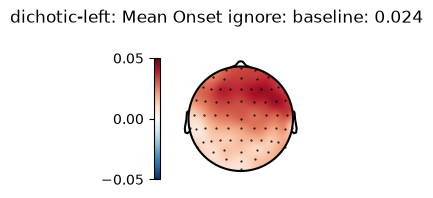

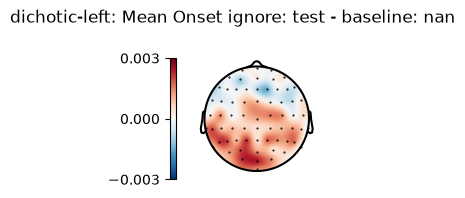

In [ ]:
# Onset ignore unique contribution (dichotic-left)
# Brodbeck et al. 2020 ran this comparison too: ignored onsets unique contribution, t = 6.70, p < .001 - the ignored speaker is tracked separately.
data, diff, result = compute_unique_contribution(FULL_BASE, onset(IGNORE), 'dichotic-left')
show_topomap_trio(data, diff, result, 'Onset ignore', 'dichotic-left', onset(IGNORE))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Onset ignore (dichotic-left): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, 4 clusters, p = .085>

Onset ignore (dichotic-left): ROI unique contribution t(12) = 0.187, p = 0.4273


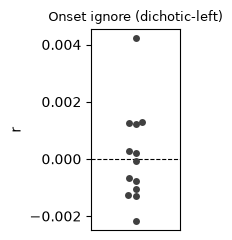

In [ ]:
p = show_subject_swarm(diff, 'Onset ignore', 'dichotic-left')

/Users/joshuaighalo/Github Repositories/cocktail-cortical/analysis/experiment.py:957: UserWarning: Warning: converting a masked element to nan.
  mean_value = float(data.mean())


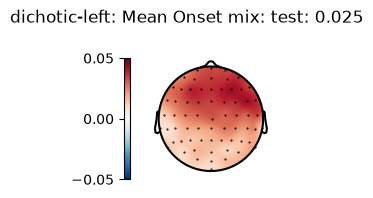

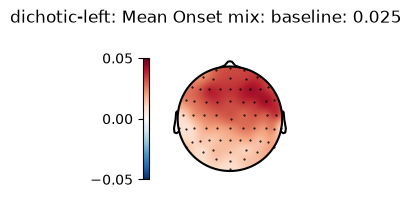

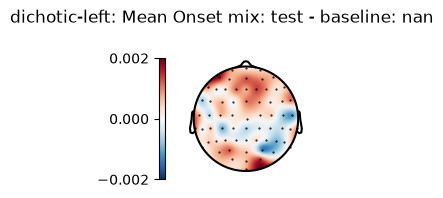

In [ ]:
# Onset mix unique contribution (dichotic-left)
# Brodbeck et al. 2020 ran this comparison too: mixture onsets unique contribution, t = 8.61, p < .001.
data, diff, result = compute_unique_contribution(FULL_BASE, onset(MIX), 'dichotic-left')
show_topomap_trio(data, diff, result, 'Onset mix', 'dichotic-left', onset(MIX))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Onset mix (dichotic-left): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, 2 clusters, p = .180>

Onset mix (dichotic-left): ROI unique contribution t(12) = 1.013, p = 0.1655


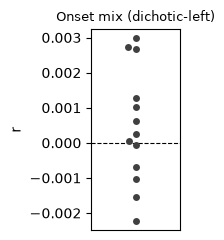

In [ ]:
p = show_subject_swarm(diff, 'Onset mix', 'dichotic-left')

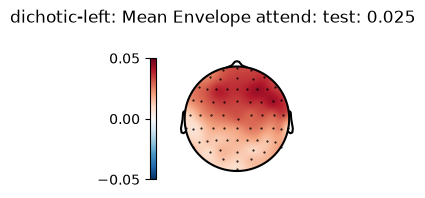

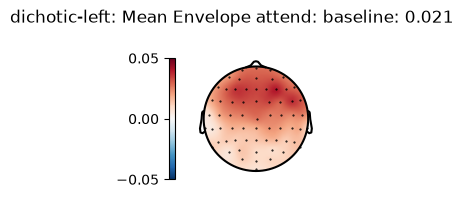

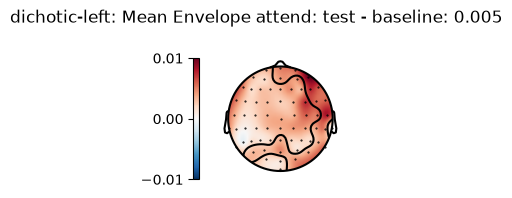

In [ ]:
# Envelope attend unique contribution (dichotic-left)
# Brodbeck et al. 2020 ran this comparison too: attended envelope unique contribution, t = 7.37, p < .001.
data, diff, result = compute_unique_contribution(FULL_BASE, envelope(ATTEND), 'dichotic-left')
show_topomap_trio(data, diff, result, 'Envelope attend', 'dichotic-left', envelope(ATTEND))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Envelope attend (dichotic-left): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, 3 clusters, p = .016>

Envelope attend (dichotic-left): ROI unique contribution t(12) = 1.594, p = 0.0684


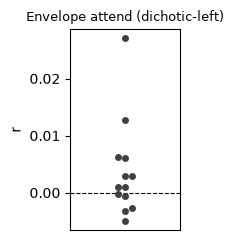

In [ ]:
p = show_subject_swarm(diff, 'Envelope attend', 'dichotic-left')

/Users/joshuaighalo/Github Repositories/cocktail-cortical/analysis/experiment.py:957: UserWarning: Warning: converting a masked element to nan.
  mean_value = float(data.mean())


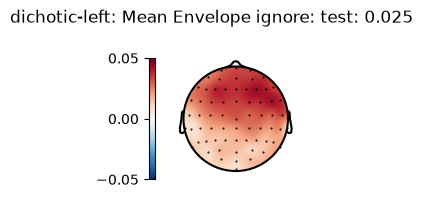

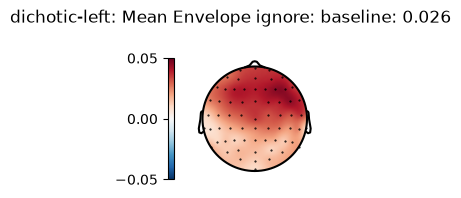

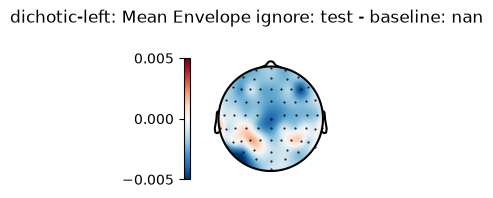

In [ ]:
# Envelope ignore unique contribution (dichotic-left)
# Brodbeck et al. 2020 ran this comparison too: ignored envelope unique contribution, t = 6.28, p < .001 - the ignored speaker's envelope is tracked separately too.
data, diff, result = compute_unique_contribution(FULL_BASE, envelope(IGNORE), 'dichotic-left')
show_topomap_trio(data, diff, result, 'Envelope ignore', 'dichotic-left', envelope(IGNORE))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Envelope ignore (dichotic-left): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, no clusters>

Envelope ignore (dichotic-left): ROI unique contribution t(12) = -3.823, p = 0.9988


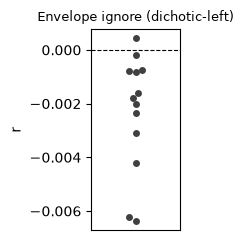

In [ ]:
p = show_subject_swarm(diff, 'Envelope ignore', 'dichotic-left')

/Users/joshuaighalo/Github Repositories/cocktail-cortical/analysis/experiment.py:957: UserWarning: Warning: converting a masked element to nan.
  mean_value = float(data.mean())


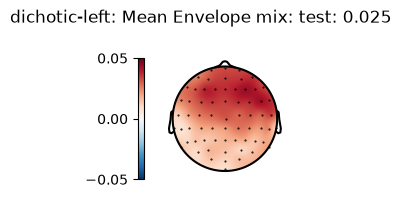

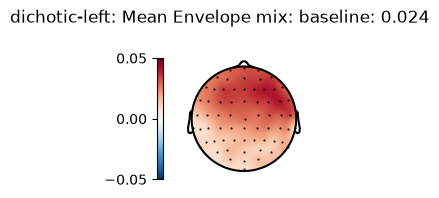

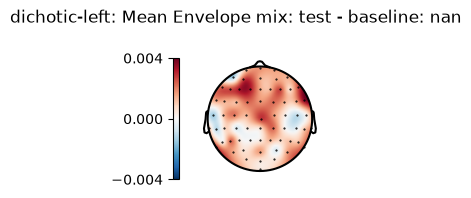

In [ ]:
# Envelope mix unique contribution (dichotic-left)
# Brodbeck et al. 2020 ran this comparison too: mixture envelope unique contribution, t = 5.70, p < .001.
data, diff, result = compute_unique_contribution(FULL_BASE, envelope(MIX), 'dichotic-left')
show_topomap_trio(data, diff, result, 'Envelope mix', 'dichotic-left', envelope(MIX))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Envelope mix (dichotic-left): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, 3 clusters, p = .321>

Envelope mix (dichotic-left): ROI unique contribution t(12) = 1.414, p = 0.0914


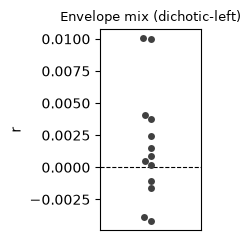

In [ ]:
p = show_subject_swarm(diff, 'Envelope mix', 'dichotic-left')

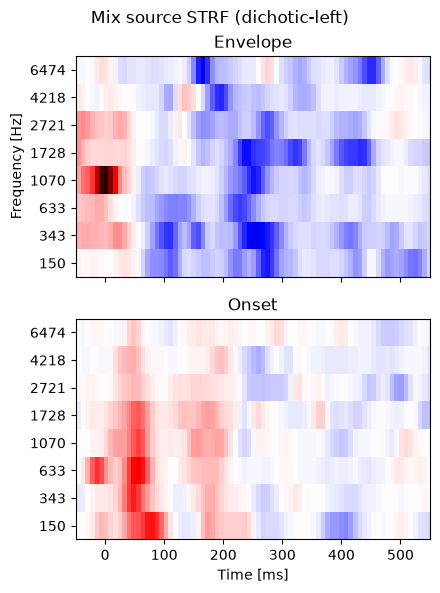

In [ ]:
# Mix source STRF: envelope + onset (dichotic-left)
envelope_strf = extract_strf(data_full, 'mix_gammatone_8')
onset_strf = extract_strf(data_full, 'mix_gammatone_on_8')
p = plot.Array([envelope_strf * 1e3, onset_strf * 1e3], axtitle=['Envelope', 'Onset'],
                title='Mix source STRF (dichotic-left)', xlim=(-0.050, 0.550))

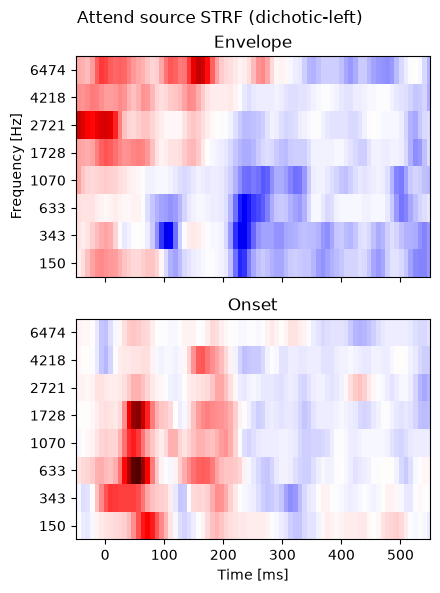

In [ ]:
# Attend source STRF: envelope + onset (dichotic-left)
envelope_strf = extract_strf(data_full, 'gammatone_8')
onset_strf = extract_strf(data_full, 'gammatone_on_8')
p = plot.Array([envelope_strf * 1e3, onset_strf * 1e3], axtitle=['Envelope', 'Onset'],
                title='Attend source STRF (dichotic-left)', xlim=(-0.050, 0.550))

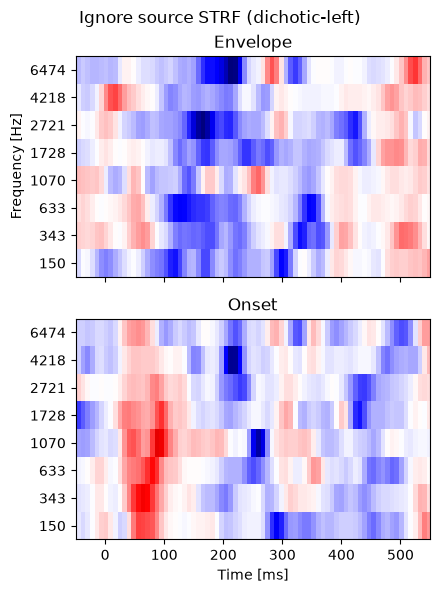

In [ ]:
# Ignore source STRF: envelope + onset (dichotic-left)
envelope_strf = extract_strf(data_full, 'bg_gammatone_8')
onset_strf = extract_strf(data_full, 'bg_gammatone_on_8')
p = plot.Array([envelope_strf * 1e3, onset_strf * 1e3], axtitle=['Envelope', 'Onset'],
                title='Ignore source STRF (dichotic-left)', xlim=(-0.050, 0.550))

In [ ]:
# Onset attend peak amplitude & timing (dichotic-left)
data = extract_trf(data_full, 'gammatone_on_8')
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Onset attend (dichotic-left) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Onset attend (dichotic-left) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

Onset attend (dichotic-left) positive peak: 96 ms, amp 0.001715
Onset attend (dichotic-left) negative peak: 119 ms, amp -0.0002563


In [ ]:
# Onset ignore peak amplitude & timing (dichotic-left)
data = extract_trf(data_full, 'bg_gammatone_on_8')
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Onset ignore (dichotic-left) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Onset ignore (dichotic-left) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

Onset ignore (dichotic-left) positive peak: 80 ms, amp 0.0006595
Onset ignore (dichotic-left) negative peak: 156 ms, amp -0.0003695


In [ ]:
# Onset mix peak amplitude & timing (dichotic-left)
data = extract_trf(data_full, 'mix_gammatone_on_8')
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Onset mix (dichotic-left) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Onset mix (dichotic-left) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

Onset mix (dichotic-left) positive peak: 75 ms, amp 0.001182
Onset mix (dichotic-left) negative peak: 126 ms, amp -0.0001057


In [ ]:
# Envelope attend peak amplitude & timing (dichotic-left)
data = extract_trf(data_full, 'gammatone_8')
data = add_peak(data, 'positive', ENVELOPE_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ENVELOPE_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Envelope attend (dichotic-left) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Envelope attend (dichotic-left) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

Envelope attend (dichotic-left) positive peak: 98 ms, amp 0.0008394
Envelope attend (dichotic-left) negative peak: 132 ms, amp -0.0004827


In [ ]:
# Envelope ignore peak amplitude & timing (dichotic-left)
data = extract_trf(data_full, 'bg_gammatone_8')
data = add_peak(data, 'positive', ENVELOPE_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ENVELOPE_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Envelope ignore (dichotic-left) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Envelope ignore (dichotic-left) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

Envelope ignore (dichotic-left) positive peak: 62 ms, amp 0.0001521
Envelope ignore (dichotic-left) negative peak: 140 ms, amp -0.0007243


In [ ]:
# Envelope mix peak amplitude & timing (dichotic-left)
data = extract_trf(data_full, 'mix_gammatone_8')
data = add_peak(data, 'positive', ENVELOPE_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ENVELOPE_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Envelope mix (dichotic-left) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Envelope mix (dichotic-left) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

Envelope mix (dichotic-left) positive peak: 94 ms, amp 0.0003296
Envelope mix (dichotic-left) negative peak: 134 ms, amp -0.001188


In [ ]:
# Onset peak comparison across mix, attend, and ignore (dichotic-left)
# Brodbeck et al. 2020 ran this comparison too: positive peak latency mixture 72ms, attended 81ms (t=4.47,p<.001), ignored 89ms (t=6.92,p<.001); negative peak latency mixture 138ms, attended 150ms (t=3.20,p=.004); positive peak amplitude bigger for mixture than attended (t=8.41) or ignored (t=7.66).
dss = []
for role_name, column in (('mix', 'mix_gammatone_on_8'), ('attend', 'gammatone_on_8'), ('ignore', 'bg_gammatone_on_8')):
    ds = extract_trf(data_full, column)
    ds[:, 'role'] = role_name
    dss.append(ds)
data = combine(dss)
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')

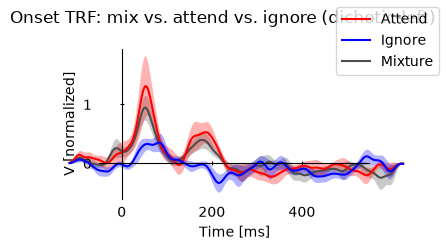

In [ ]:
# The onset TRF waveform mix/attend/ignore were each just measured
# from, overlaid so their shape and relative timing are visible
# directly, not just as extracted peak numbers below.
p = plot.UTSStat('trf_sm*1e3', 'role', data=data, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550),
                  title='Onset TRF: mix vs. attend vs. ignore (dichotic-left)', labels=LABELS_ROLE, colors=COLORS_ROLE)

In [ ]:
print_peak_table(data, 'positive', 'role')
print_peak_table(data, 'negative', 'role')


positive peak
subject   role         time (ms)           amp
01        mix                183      0.001276
02        mix                 54     0.0005525
03        mix                193     0.0008098
04        mix                 46     0.0003089
05        mix                 50      0.001964
06        mix                 41      0.001097
07        mix                 91      0.001223
08        mix                 46      0.002144
09        mix                 60       0.00104
10        mix                 58      0.002745
11        mix                 58      0.001254
12        mix                 41     0.0002777
13        mix                 46     0.0006687
01        attend             185      0.001259
02        attend              58      0.001019
03        attend              48     4.033e-05
04        attend              45     0.0002019
05        attend              48      0.007292
06        attend             175     0.0007222
07        attend             162      0.00281

In [ ]:
display(test.pairwise('positive_time', 'role', match='subject', data=data, corr=False, title='onset positive peak latency: mix vs. attend vs. ignore'))
display(test.pairwise('negative_time', 'role', match='subject', data=data, corr=False, title='onset negative peak latency: mix vs. attend vs. ignore'))

,attend,ignore
mix,t12 = -1.10 p = .293,t12 = -0.28 p = .785
attend,,t12 = 0.71 p = .494


,attend,ignore
mix,t12 = 0.60 p = .561,t12 = -2.45* p = .031
attend,,t12 = -2.30* p = .040


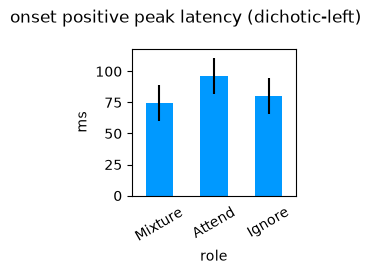

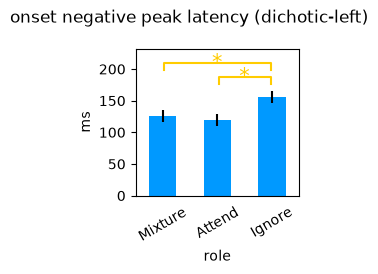

In [ ]:
p = plot.Barplot('positive_time', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='onset positive peak latency (dichotic-left)')
p.set_xtick_rotation(30)
p = plot.Barplot('negative_time', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='onset negative peak latency (dichotic-left)')
p.set_xtick_rotation(30)

In [ ]:
display(test.pairwise('positive_amp', 'role', match='subject', data=data, corr=False, title='onset positive peak amplitude: mix vs. attend vs. ignore'))
display(test.pairwise('negative_amp', 'role', match='subject', data=data, corr=False, title='onset negative peak amplitude: mix vs. attend vs. ignore'))

,attend,ignore
mix,t12 = -1.15 p = .271,t12 = 2.55* p = .025
attend,,t12 = 1.97 p = .072


,attend,ignore
mix,t12 = 1.39 p = .190,t12 = 2.80* p = .016
attend,,t12 = 0.66 p = .523


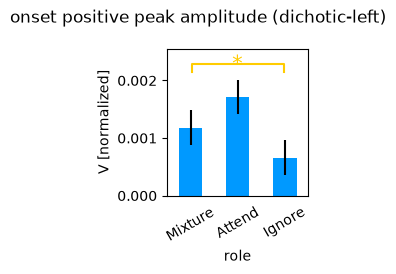

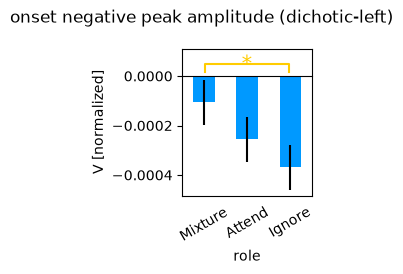

In [ ]:
p = plot.Barplot('positive_amp', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='onset positive peak amplitude (dichotic-left)')
p.set_xtick_rotation(30)
p = plot.Barplot('negative_amp', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='onset negative peak amplitude (dichotic-left)')
p.set_xtick_rotation(30)

In [ ]:
# Envelope peak comparison across mix, attend, and ignore (dichotic-left)
dss = []
for role_name, column in (('mix', 'mix_gammatone_8'), ('attend', 'gammatone_8'), ('ignore', 'bg_gammatone_8')):
    ds = extract_trf(data_full, column)
    ds[:, 'role'] = role_name
    dss.append(ds)
data = combine(dss)
data = add_peak(data, 'positive', ENVELOPE_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ENVELOPE_NEGATIVE_PEAK_WINDOW, kind='min')

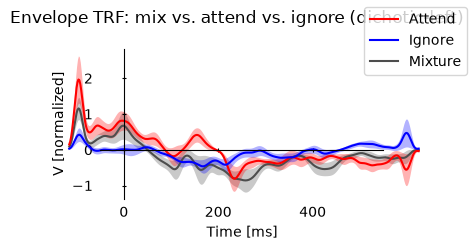

In [ ]:
# The envelope TRF waveform mix/attend/ignore were each just measured
# from, overlaid so their shape and relative timing are visible
# directly, not just as extracted peak numbers below.
p = plot.UTSStat('trf_sm*1e3', 'role', data=data, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550),
                  title='Envelope TRF: mix vs. attend vs. ignore (dichotic-left)', labels=LABELS_ROLE, colors=COLORS_ROLE)

In [ ]:
print_peak_table(data, 'positive', 'role')
print_peak_table(data, 'negative', 'role')


positive peak
subject   role         time (ms)           amp
01        mix                134     0.0003275
02        mix                144     3.767e-05
03        mix                 41     9.987e-05
04        mix                 41    -0.0002178
05        mix                 60    -3.487e-05
06        mix                115    -0.0001072
07        mix                 70      0.000168
08        mix                119       0.00151
09        mix                 58      4.62e-05
10        mix                 41     0.0002809
11        mix                 45    -7.597e-05
12        mix                187     0.0001169
13        mix                164      0.002133
01        attend             146      0.002044
02        attend              43     9.877e-05
03        attend             185      -7.5e-05
04        attend              41     0.0001854
05        attend              41      0.000375
06        attend             156      0.001832
07        attend              56      0.00181

In [ ]:
display(test.pairwise('positive_time', 'role', match='subject', data=data, corr=False, title='envelope positive peak latency: mix vs. attend vs. ignore'))
display(test.pairwise('negative_time', 'role', match='subject', data=data, corr=False, title='envelope negative peak latency: mix vs. attend vs. ignore'))

,attend,ignore
mix,t12 = -0.23 p = .821,t12 = 2.41* p = .033
attend,,t12 = 2.15 p = .053


,attend,ignore
mix,t12 = 0.16 p = .875,t12 = -0.35 p = .736
attend,,t12 = -0.42 p = .679


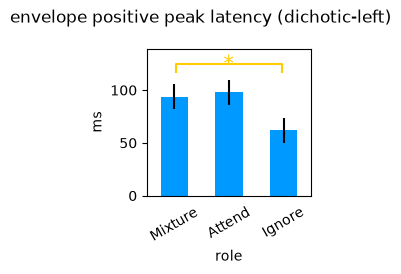

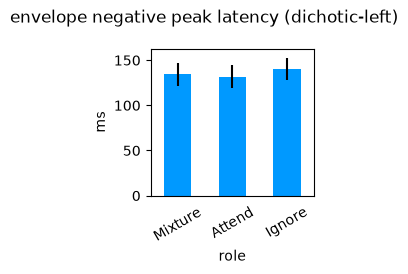

In [ ]:
p = plot.Barplot('positive_time', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='envelope positive peak latency (dichotic-left)')
p.set_xtick_rotation(30)
p = plot.Barplot('negative_time', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='envelope negative peak latency (dichotic-left)')
p.set_xtick_rotation(30)

In [ ]:
display(test.pairwise('positive_amp', 'role', match='subject', data=data, corr=False, title='envelope positive peak amplitude: mix vs. attend vs. ignore'))
display(test.pairwise('negative_amp', 'role', match='subject', data=data, corr=False, title='envelope negative peak amplitude: mix vs. attend vs. ignore'))

,attend,ignore
mix,t12 = -2.22* p = .046,t12 = 1.48 p = .164
attend,,t12 = 3.41** p = .005


,attend,ignore
mix,t12 = -2.43* p = .032,t12 = -2.11 p = .057
attend,,t12 = 0.91 p = .380


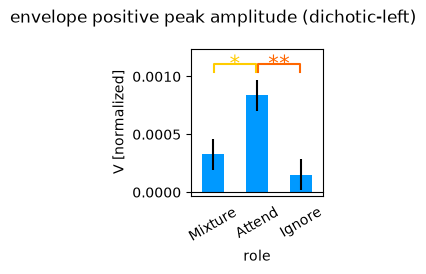

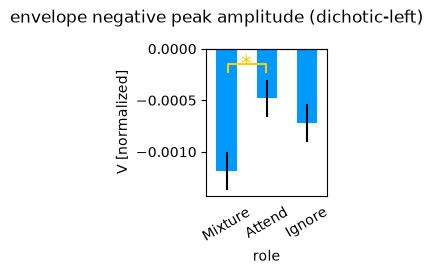

In [ ]:
p = plot.Barplot('positive_amp', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='envelope positive peak amplitude (dichotic-left)')
p.set_xtick_rotation(30)
p = plot.Barplot('negative_amp', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='envelope negative peak amplitude (dichotic-left)')
p.set_xtick_rotation(30)

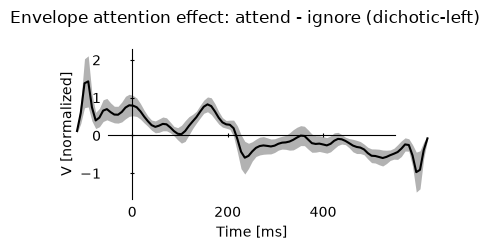

In [ ]:
# Envelope attention effect: attend - ignore (dichotic-left)
# Brodbeck et al. 2020 ran this comparison too: envelope attention-effect difference wave: negative bump ~100ms, positive bump ~200ms, starting almost immediately.
attend_trf = data_full['gammatone_8'].sum('frequency').mean(sensor=ROI)
ignore_trf = data_full['bg_gammatone_8'].sum('frequency').mean(sensor=ROI)
attention_effect = attend_trf - ignore_trf
p = plot.UTSStat(attention_effect * 1e3, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550), title='Envelope attention effect: attend - ignore (dichotic-left)')

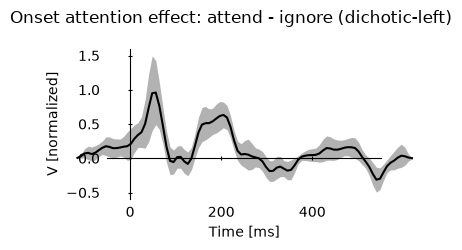

In [ ]:
# Onset attention effect: attend - ignore (dichotic-left)
# Brodbeck et al. 2020 ran this comparison too: onset attention effect appears later than the envelope's, once the masked-onset response develops (see the masked-onset section below).
attend_trf = data_full['gammatone_on_8'].sum('frequency').mean(sensor=ROI)
ignore_trf = data_full['bg_gammatone_on_8'].sum('frequency').mean(sensor=ROI)
attention_effect = attend_trf - ignore_trf
p = plot.UTSStat(attention_effect * 1e3, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550), title='Onset attention effect: attend - ignore (dichotic-left)')

## Dichotic Left (overt onsets)

/Users/joshuaighalo/Github Repositories/cocktail-cortical/analysis/experiment.py:957: UserWarning: Warning: converting a masked element to nan.
  mean_value = float(data.mean())


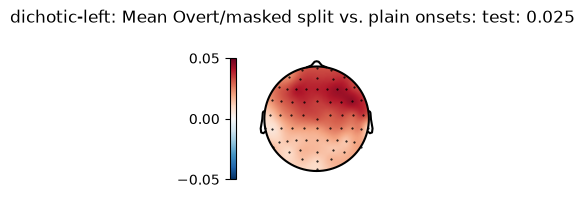

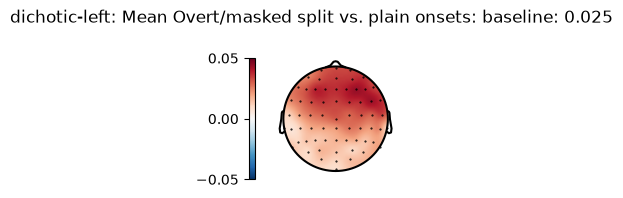

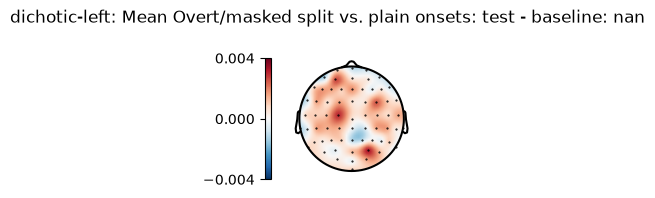

In [ ]:
# Overt/masked split vs. plain onsets (dichotic-left)
# Brodbeck et al. 2020 ran this comparison too: splitting onsets into overt/masked significantly improved the model overall, t = 6.81, p < .001.
data, diff, result = compute_direct_comparison(FULL_MASKED, FULL_BASE, 'dichotic-left')
show_topomap_trio(data, diff, result, 'Overt/masked split vs. plain onsets', 'dichotic-left', None)

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Overt/masked split vs. plain onsets (dichotic-left): ROI model comparison t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, 2 clusters, p = .347>

Overt/masked split vs. plain onsets (dichotic-left): ROI model comparison t(12) = 1.056, p = 0.1559


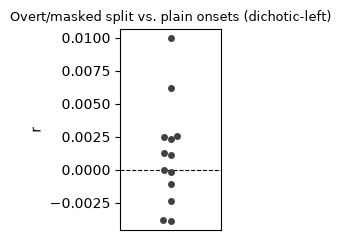

In [ ]:
p = show_subject_swarm(diff, 'Overt/masked split vs. plain onsets', 'dichotic-left')

In [ ]:
# Loaded once here, reused by every STRF/peak/waveform/attention-
# effect/masking-comparison cell in both this subsection and "masked
# onset" below - same reasoning as data_full above, for FULL_MASKED.
data_masked = e.load_trfs('all', FULL_MASKED, epoch='dichotic-left', **PARAMETERS)

/Users/joshuaighalo/Github Repositories/cocktail-cortical/analysis/experiment.py:957: UserWarning: Warning: converting a masked element to nan.
  mean_value = float(data.mean())


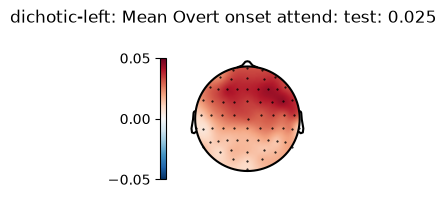

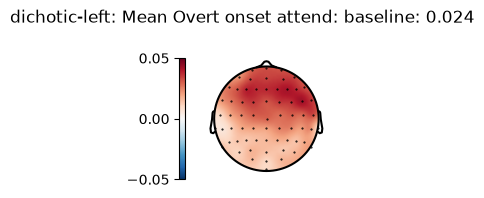

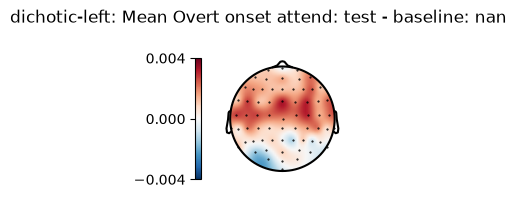

In [ ]:
# Overt onset attend unique contribution (dichotic-left)
# Brodbeck et al. 2020 ran this comparison too: attended overt onsets unique contribution, t = 3.34, p = .027.
data, diff, result = compute_unique_contribution(FULL_MASKED, overt_onset(ATTEND), 'dichotic-left')
show_topomap_trio(data, diff, result, 'Overt onset attend', 'dichotic-left', overt_onset(ATTEND))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Overt onset attend (dichotic-left): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, 5 clusters, p = .193>

Overt onset attend (dichotic-left): ROI unique contribution t(12) = 1.551, p = 0.0734


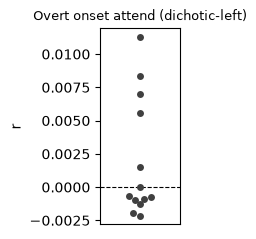

In [ ]:
p = show_subject_swarm(diff, 'Overt onset attend', 'dichotic-left')

/Users/joshuaighalo/Github Repositories/cocktail-cortical/analysis/experiment.py:957: UserWarning: Warning: converting a masked element to nan.
  mean_value = float(data.mean())


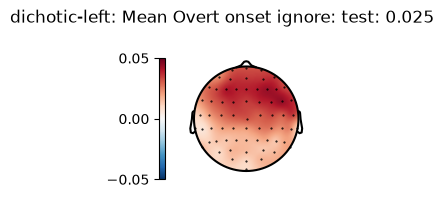

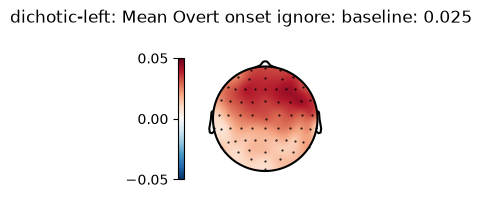

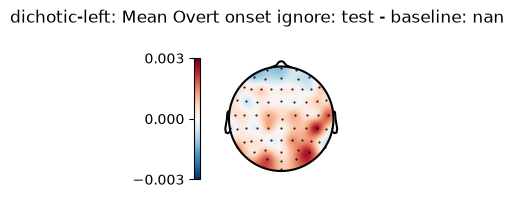

In [ ]:
# Overt onset ignore unique contribution (dichotic-left)
# Brodbeck et al. 2020 ran this comparison too: ignored overt onsets unique contribution, t = 3.82, p = .016.
data, diff, result = compute_unique_contribution(FULL_MASKED, overt_onset(IGNORE), 'dichotic-left')
show_topomap_trio(data, diff, result, 'Overt onset ignore', 'dichotic-left', overt_onset(IGNORE))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Overt onset ignore (dichotic-left): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, 4 clusters, p = .238>

Overt onset ignore (dichotic-left): ROI unique contribution t(12) = 0.333, p = 0.3723


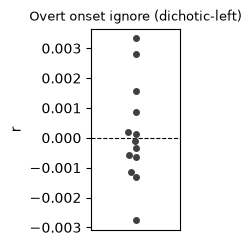

In [ ]:
p = show_subject_swarm(diff, 'Overt onset ignore', 'dichotic-left')

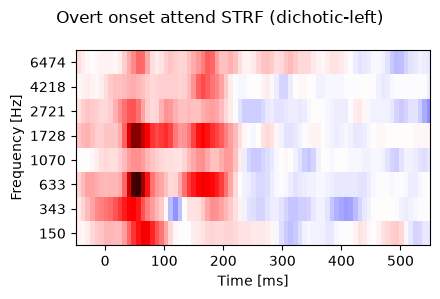

In [ ]:
# Overt onset attend STRF (dichotic-left)
strf = extract_strf(data_masked, 'gammatone_on_overt_8')
p = plot.Array(strf * 1e3, title='Overt onset attend STRF (dichotic-left)', xlim=(-0.050, 0.550))

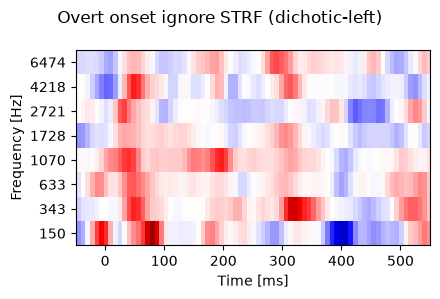

In [ ]:
# Overt onset ignore STRF (dichotic-left)
strf = extract_strf(data_masked, 'bg_gammatone_on_overt_8')
p = plot.Array(strf * 1e3, title='Overt onset ignore STRF (dichotic-left)', xlim=(-0.050, 0.550))

In [ ]:
# Overt onset attend peak amplitude & timing (dichotic-left)
data = extract_trf(data_masked, 'gammatone_on_overt_8')
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Overt onset attend (dichotic-left) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Overt onset attend (dichotic-left) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

Overt onset attend (dichotic-left) positive peak: 92 ms, amp 0.001947
Overt onset attend (dichotic-left) negative peak: 119 ms, amp -2.068e-05


In [ ]:
# Overt onset ignore peak amplitude & timing (dichotic-left)
data = extract_trf(data_masked, 'bg_gammatone_on_overt_8')
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Overt onset ignore (dichotic-left) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Overt onset ignore (dichotic-left) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

Overt onset ignore (dichotic-left) positive peak: 93 ms, amp 0.0006255
Overt onset ignore (dichotic-left) negative peak: 126 ms, amp -0.0001677


In [ ]:
# Overt onset peak comparison across attend and ignore (dichotic-left)
dss = []
for role_name, column in (('attend', 'gammatone_on_overt_8'), ('ignore', 'bg_gammatone_on_overt_8')):
    ds = extract_trf(data_masked, column)
    ds[:, 'role'] = role_name
    dss.append(ds)
data = combine(dss)
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')

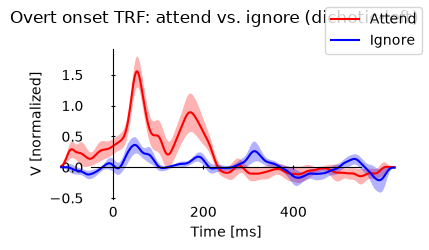

In [ ]:
# The overt onset TRF waveform attend/ignore were each just measured
# from, overlaid so their shape and relative timing are visible
# directly, not just as extracted peak numbers below.
p = plot.UTSStat('trf_sm*1e3', 'role', data=data, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550),
                  title='Overt onset TRF: attend vs. ignore (dichotic-left)', labels={'attend': 'Attend', 'ignore': 'Ignore'}, colors={'attend': 'red', 'ignore': 'blue'})

In [ ]:
print_peak_table(data, 'positive', 'role')
print_peak_table(data, 'negative', 'role')


positive peak
subject   role         time (ms)           amp
01        attend             181      0.002861
02        attend              60      0.001005
03        attend              46     0.0004634
04        attend              52     0.0007143
05        attend              48      0.003203
06        attend             170      0.001795
07        attend             164      0.003183
08        attend              46      0.002494
09        attend             164      0.002556
10        attend              54      0.002619
11        attend              52     0.0007738
12        attend             103      0.002127
13        attend              54      0.001511
01        ignore             191     0.0003631
02        ignore              54     0.0003835
03        ignore             197      0.001026
04        ignore              41     0.0003809
05        ignore              60     0.0006034
06        ignore              41      0.002006
07        ignore             191     0.000269

In [ ]:
display(test.pairwise('positive_time', 'role', match='subject', data=data, corr=False, title='overt onset positive peak latency: attend vs. ignore'))
display(test.pairwise('negative_time', 'role', match='subject', data=data, corr=False, title='overt onset negative peak latency: attend vs. ignore'))

,ignore
attend,t12 = -0.03 p = .973


,ignore
attend,t12 = -0.46 p = .657


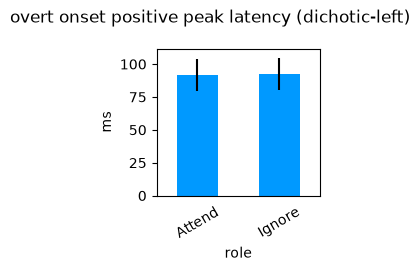

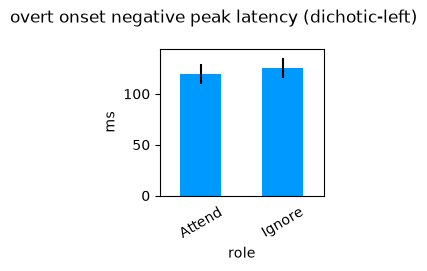

In [ ]:
p = plot.Barplot('positive_time', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='overt onset positive peak latency (dichotic-left)')
p.set_xtick_rotation(30)
p = plot.Barplot('negative_time', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='overt onset negative peak latency (dichotic-left)')
p.set_xtick_rotation(30)

In [ ]:
display(test.pairwise('positive_amp', 'role', match='subject', data=data, corr=False, title='overt onset positive peak amplitude: attend vs. ignore'))
display(test.pairwise('negative_amp', 'role', match='subject', data=data, corr=False, title='overt onset negative peak amplitude: attend vs. ignore'))

,ignore
attend,t12 = 4.09** p = .001


,ignore
attend,t12 = 0.85 p = .411


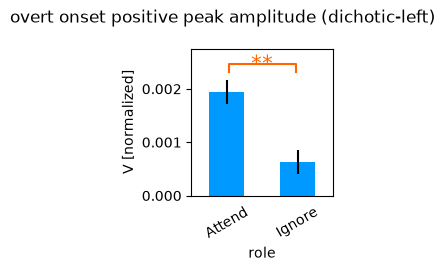

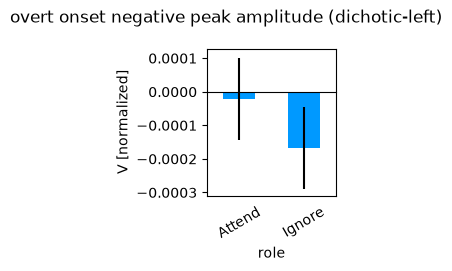

In [ ]:
p = plot.Barplot('positive_amp', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='overt onset positive peak amplitude (dichotic-left)')
p.set_xtick_rotation(30)
p = plot.Barplot('negative_amp', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='overt onset negative peak amplitude (dichotic-left)')
p.set_xtick_rotation(30)

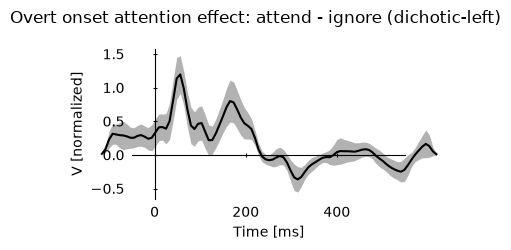

In [ ]:
# Overt onset attention effect: attend - ignore (dichotic-left)
attend_trf = data_masked['gammatone_on_overt_8'].sum('frequency').mean(sensor=ROI)
ignore_trf = data_masked['bg_gammatone_on_overt_8'].sum('frequency').mean(sensor=ROI)
attention_effect = attend_trf - ignore_trf
p = plot.UTSStat(attention_effect * 1e3, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550), title='Overt onset attention effect: attend - ignore (dichotic-left)')

## Dichotic Left (masked onset)

/Users/joshuaighalo/Github Repositories/cocktail-cortical/analysis/experiment.py:957: UserWarning: Warning: converting a masked element to nan.
  mean_value = float(data.mean())


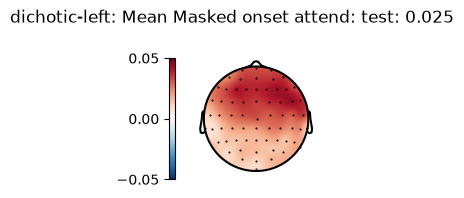

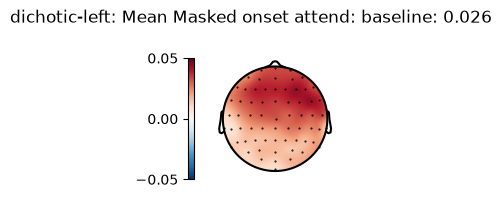

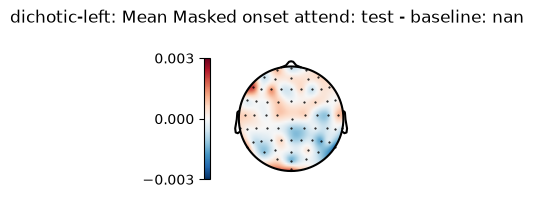

In [ ]:
# Masked onset attend unique contribution (dichotic-left)
# Brodbeck et al. 2020 ran this comparison too: attended masked onsets unique contribution, t = 8.42, p < .001 - the strongest of the four masking predictors.
data, diff, result = compute_unique_contribution(FULL_MASKED, masked_onset(ATTEND), 'dichotic-left')
show_topomap_trio(data, diff, result, 'Masked onset attend', 'dichotic-left', masked_onset(ATTEND))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Masked onset attend (dichotic-left): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, 1 clusters, p = .563>

Masked onset attend (dichotic-left): ROI unique contribution t(12) = 0.256, p = 0.4013


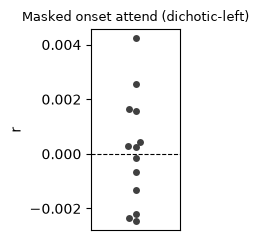

In [ ]:
p = show_subject_swarm(diff, 'Masked onset attend', 'dichotic-left')

/Users/joshuaighalo/Github Repositories/cocktail-cortical/analysis/experiment.py:957: UserWarning: Warning: converting a masked element to nan.
  mean_value = float(data.mean())


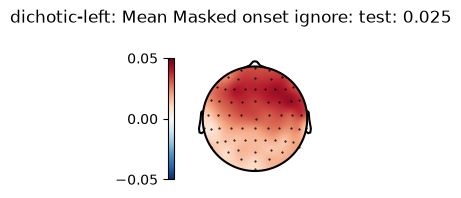

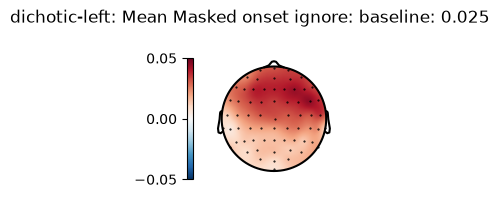

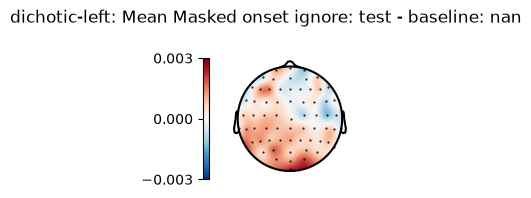

In [ ]:
# Masked onset ignore unique contribution (dichotic-left)
# Brodbeck et al. 2020 ran this comparison too: ignored masked onsets unique contribution, t = 5.23, p < .001 - the brain recovers masked information even for the ignored speaker.
data, diff, result = compute_unique_contribution(FULL_MASKED, masked_onset(IGNORE), 'dichotic-left')
show_topomap_trio(data, diff, result, 'Masked onset ignore', 'dichotic-left', masked_onset(IGNORE))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Masked onset ignore (dichotic-left): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, 4 clusters, p = .319>

Masked onset ignore (dichotic-left): ROI unique contribution t(12) = 0.230, p = 0.4110


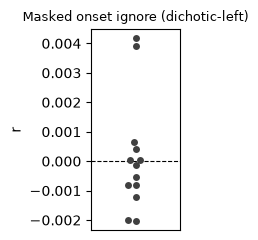

In [ ]:
p = show_subject_swarm(diff, 'Masked onset ignore', 'dichotic-left')

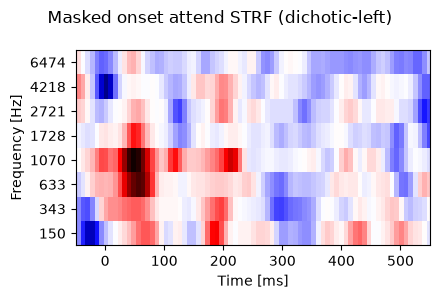

In [ ]:
# Masked onset attend STRF (dichotic-left)
strf = extract_strf(data_masked, 'gammatone_on_masked_8')
p = plot.Array(strf * 1e3, title='Masked onset attend STRF (dichotic-left)', xlim=(-0.050, 0.550))

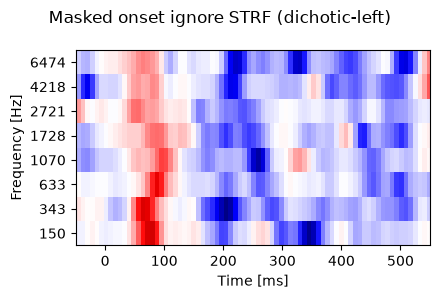

In [ ]:
# Masked onset ignore STRF (dichotic-left)
strf = extract_strf(data_masked, 'bg_gammatone_on_masked_8')
p = plot.Array(strf * 1e3, title='Masked onset ignore STRF (dichotic-left)', xlim=(-0.050, 0.550))

In [ ]:
# Masked onset attend peak amplitude & timing (dichotic-left)
data = extract_trf(data_masked, 'gammatone_on_masked_8')
data = add_peak(data, 'positive', MASKED_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', MASKED_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Masked onset attend (dichotic-left) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Masked onset attend (dichotic-left) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

Masked onset attend (dichotic-left) positive peak: 114 ms, amp 0.0008392
Masked onset attend (dichotic-left) negative peak: 115 ms, amp -0.0002874


In [ ]:
# Masked onset ignore peak amplitude & timing (dichotic-left)
data = extract_trf(data_masked, 'bg_gammatone_on_masked_8')
data = add_peak(data, 'positive', MASKED_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', MASKED_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Masked onset ignore (dichotic-left) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Masked onset ignore (dichotic-left) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

Masked onset ignore (dichotic-left) positive peak: 86 ms, amp 0.0005794
Masked onset ignore (dichotic-left) negative peak: 158 ms, amp -0.0005717


In [ ]:
# Masked onset peak comparison across attend and ignore (dichotic-left)
dss = []
for role_name, column in (('attend', 'gammatone_on_masked_8'), ('ignore', 'bg_gammatone_on_masked_8')):
    ds = extract_trf(data_masked, column)
    ds[:, 'role'] = role_name
    dss.append(ds)
data = combine(dss)
data = add_peak(data, 'positive', MASKED_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', MASKED_NEGATIVE_PEAK_WINDOW, kind='min')

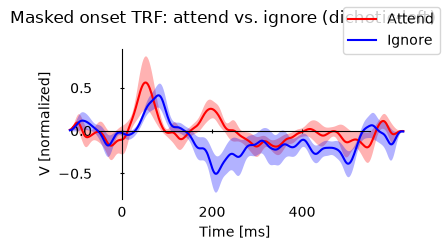

In [ ]:
# The masked onset TRF waveform attend/ignore were each just measured
# from, overlaid so their shape and relative timing are visible
# directly, not just as extracted peak numbers below.
p = plot.UTSStat('trf_sm*1e3', 'role', data=data, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550),
                  title='Masked onset TRF: attend vs. ignore (dichotic-left)', labels={'attend': 'Attend', 'ignore': 'Ignore'}, colors={'attend': 'red', 'ignore': 'blue'})

In [ ]:
print_peak_table(data, 'positive', 'role')
print_peak_table(data, 'negative', 'role')


positive peak
subject   role         time (ms)           amp
01        attend             199     0.0004847
02        attend              60      0.000347
03        attend              86     3.664e-05
04        attend              41     0.0001083
05        attend              50      0.004106
06        attend              50     0.0006063
07        attend             160     0.0004139
08        attend             189      0.001475
09        attend             195     0.0008045
10        attend              54     0.0006325
11        attend              80     5.818e-05
12        attend             199     0.0005408
13        attend             117      0.001296
01        ignore              50     0.0004481
02        ignore              46     0.0002371
03        ignore              76      0.001108
04        ignore             130     6.853e-05
05        ignore              58     0.0008297
06        ignore             109     0.0006017
07        ignore              89      0.00162

In [ ]:
display(test.pairwise('positive_time', 'role', match='subject', data=data, corr=False, title='masked onset positive peak latency: attend vs. ignore'))
display(test.pairwise('negative_time', 'role', match='subject', data=data, corr=False, title='masked onset negative peak latency: attend vs. ignore'))

,ignore
attend,t12 = 1.45 p = .173


,ignore
attend,t12 = -2.72* p = .019


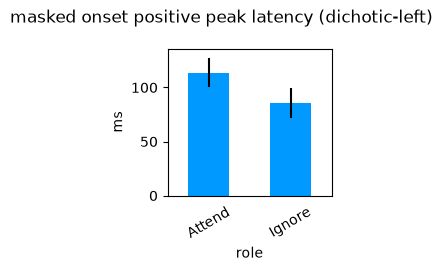

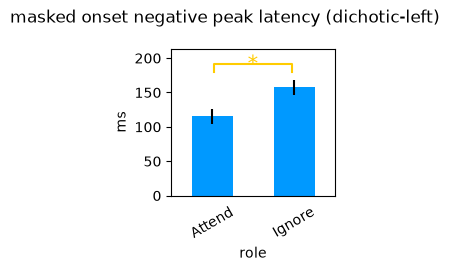

In [ ]:
p = plot.Barplot('positive_time', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='masked onset positive peak latency (dichotic-left)')
p.set_xtick_rotation(30)
p = plot.Barplot('negative_time', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='masked onset negative peak latency (dichotic-left)')
p.set_xtick_rotation(30)

In [ ]:
display(test.pairwise('positive_amp', 'role', match='subject', data=data, corr=False, title='masked onset positive peak amplitude: attend vs. ignore'))
display(test.pairwise('negative_amp', 'role', match='subject', data=data, corr=False, title='masked onset negative peak amplitude: attend vs. ignore'))

,ignore
attend,t12 = 0.83 p = .424


,ignore
attend,t12 = 1.34 p = .205


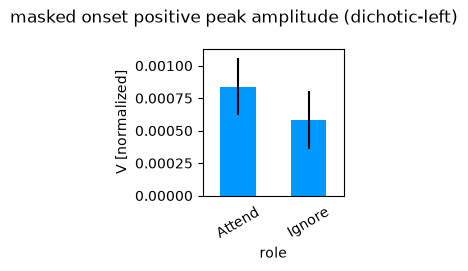

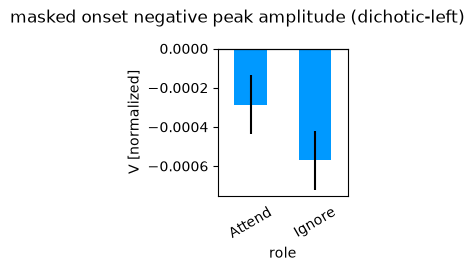

In [ ]:
p = plot.Barplot('positive_amp', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='masked onset positive peak amplitude (dichotic-left)')
p.set_xtick_rotation(30)
p = plot.Barplot('negative_amp', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='masked onset negative peak amplitude (dichotic-left)')
p.set_xtick_rotation(30)

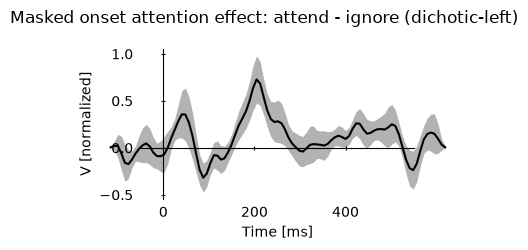

In [ ]:
# Masked onset attention effect: attend - ignore (dichotic-left)
attend_trf = data_masked['gammatone_on_masked_8'].sum('frequency').mean(sensor=ROI)
ignore_trf = data_masked['bg_gammatone_on_masked_8'].sum('frequency').mean(sensor=ROI)
attention_effect = attend_trf - ignore_trf
p = plot.UTSStat(attention_effect * 1e3, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550), title='Masked onset attention effect: attend - ignore (dichotic-left)')

In [ ]:
# Overt vs. masked peak comparison, attend (dichotic-left)
# Brodbeck et al. 2020 ran this comparison too: attended overt 72ms vs. attended masked 91ms (t=2.85,p=.009); combined (not stream-split) late negative peak, overt 133ms vs. masked 182ms (t=4.45,p<.001).
dss = []
for masking, column in (('overt', 'gammatone_on_overt_8'), ('masked', 'gammatone_on_masked_8')):
    ds = extract_trf(data_masked, column)
    ds[:, 'masking'] = masking
    dss.append(ds)
data = combine(dss)
data = add_peak(data, 'positive', MASKED_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', MASKED_NEGATIVE_PEAK_WINDOW, kind='min')

In [ ]:
print_peak_table(data, 'positive', 'masking')
print_peak_table(data, 'negative', 'masking')


positive peak
subject   masking      time (ms)           amp
01        overt              181      0.002861
02        overt               60      0.001005
03        overt               46     0.0004634
04        overt               52     0.0007143
05        overt               48      0.003203
06        overt              170      0.001795
07        overt              164      0.003183
08        overt               46      0.002494
09        overt              164      0.002556
10        overt               54      0.002619
11        overt               52     0.0007738
12        overt              103      0.002127
13        overt               54      0.001511
01        masked             199     0.0004847
02        masked              60      0.000347
03        masked              86     3.664e-05
04        masked              41     0.0001083
05        masked              50      0.004106
06        masked              50     0.0006063
07        masked             160     0.000413

In [ ]:
display(test.pairwise('positive_time', 'masking', match='subject', data=data, corr=False, title='attend positive peak latency: overt vs. masked'))
display(test.pairwise('negative_time', 'masking', match='subject', data=data, corr=False, title='attend negative peak latency: overt vs. masked'))

,masked
overt,t12 = -1.28 p = .224


,masked
overt,t12 = 0.33 p = .747


In [ ]:
display(test.pairwise('positive_amp', 'masking', match='subject', data=data, corr=False, title='attend positive peak amplitude: overt vs. masked'))
display(test.pairwise('negative_amp', 'masking', match='subject', data=data, corr=False, title='attend negative peak amplitude: overt vs. masked'))

,masked
overt,t12 = 4.04** p = .002


,masked
overt,t12 = 1.67 p = .120


In [ ]:
# Overt vs. masked peak comparison, ignore (dichotic-left)
# Brodbeck et al. 2020 ran this comparison too: ignored overt 83ms vs. ignored masked 97ms (t=6.11,p<.001); combined (not stream-split) late negative peak, overt 133ms vs. masked 182ms (t=4.45,p<.001).
dss = []
for masking, column in (('overt', 'bg_gammatone_on_overt_8'), ('masked', 'bg_gammatone_on_masked_8')):
    ds = extract_trf(data_masked, column)
    ds[:, 'masking'] = masking
    dss.append(ds)
data = combine(dss)
data = add_peak(data, 'positive', MASKED_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', MASKED_NEGATIVE_PEAK_WINDOW, kind='min')

In [ ]:
print_peak_table(data, 'positive', 'masking')
print_peak_table(data, 'negative', 'masking')


positive peak
subject   masking      time (ms)           amp
01        overt              191     0.0003631
02        overt               54     0.0003835
03        overt              197      0.001026
04        overt               41     0.0003809
05        overt               60     0.0006034
06        overt               41      0.002006
07        overt              191     0.0002691
08        overt               58     0.0004154
09        overt               91     0.0003983
10        overt               80      0.001705
11        overt               54     0.0005166
12        overt              103    -8.091e-05
13        overt               43     0.0001451
01        masked              50     0.0004481
02        masked              46     0.0002371
03        masked              76      0.001108
04        masked             130     6.853e-05
05        masked              58     0.0008297
06        masked             109     0.0006017
07        masked              89      0.00162

In [ ]:
display(test.pairwise('positive_time', 'masking', match='subject', data=data, corr=False, title='ignore positive peak latency: overt vs. masked'))
display(test.pairwise('negative_time', 'masking', match='subject', data=data, corr=False, title='ignore negative peak latency: overt vs. masked'))

,masked
overt,t12 = 0.35 p = .735


,masked
overt,t12 = -2.19* p = .049


In [ ]:
display(test.pairwise('positive_amp', 'masking', match='subject', data=data, corr=False, title='ignore positive peak amplitude: overt vs. masked'))
display(test.pairwise('negative_amp', 'masking', match='subject', data=data, corr=False, title='ignore negative peak amplitude: overt vs. masked'))

,masked
overt,t12 = 0.27 p = .789


,masked
overt,t12 = 2.63* p = .022


In [ ]:
# Stream x masking interaction on peak amplitude (dichotic-left)
# Brodbeck et al. 2020 ran this comparison too: stream x masking interaction, F(1,25) = 24.45, p < .001 - overt onsets show no early attention effect, masked onsets do.
dss = []
for stream_name, is_attend in (('attend', True), ('ignore', False)):
    for masking_name in ('overt', 'masked'):
        prefix = '' if is_attend else 'bg_'
        column = f'{prefix}gammatone_on_{masking_name}_8'
        ds = extract_trf(data_masked, column)
        ds[:, 'stream'] = stream_name
        ds[:, 'masking'] = masking_name
        dss.append(ds)
data = combine(dss)
data = add_peak(data, 'positive', MASKED_POSITIVE_PEAK_WINDOW, kind='max')
display(test.ANOVA('positive_amp', 'stream * masking * subject', data=data, title='stream x masking interaction (dichotic-left)'))

<ANOVA: positive_amp ~ stream + masking + stream x masking + subject + stream x subject + masking x subject + stream x masking x subject
  
  stream x masking interaction (dichotic-left)
  
                       SS   df     MS   MS(denom)   df(denom)          F      p
  -----------------------------------------------------------------------------
  stream             0.00    1   0.00        0.00          12    8.68*     .012
  masking            0.00    1   0.00        0.00          12   14.94**    .002
  stream x masking   0.00    1   0.00        0.00          12    9.57**    .009
  -----------------------------------------------------------------------------
  Total              0.00   51
>

## Dichotic Left (intensity-level control)

/Users/joshuaighalo/Github Repositories/cocktail-cortical/analysis/experiment.py:957: UserWarning: Warning: converting a masked element to nan.
  mean_value = float(data.mean())


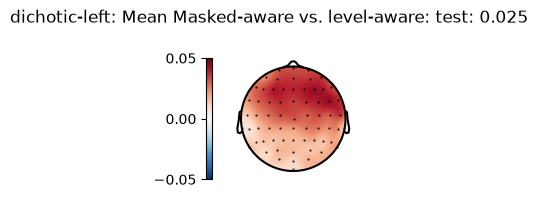

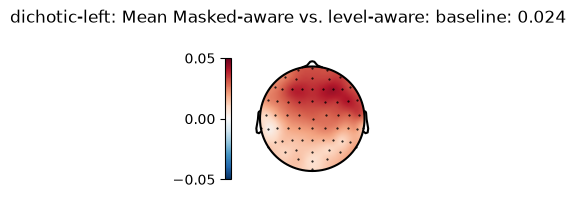

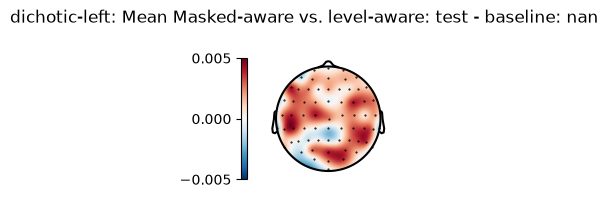

In [ ]:
# Masked-aware vs. level-aware (dichotic-left)
# Brodbeck et al. 2020 ran this comparison too: the ignored-speaker-aware model still beat the loudness-only model, t = 9.21, p < .001 - the masking effect isn't just about volume.
data, diff, result = compute_direct_comparison(FULL_MASKED, LEVEL_AWARE, 'dichotic-left')
show_topomap_trio(data, diff, result, 'Masked-aware vs. level-aware', 'dichotic-left', None)

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Masked-aware vs. level-aware (dichotic-left): ROI model comparison t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, 3 clusters, p = .181>

Masked-aware vs. level-aware (dichotic-left): ROI model comparison t(12) = 0.909, p = 0.1907


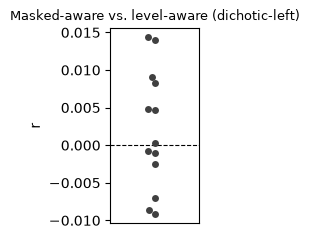

In [ ]:
p = show_subject_swarm(diff, 'Masked-aware vs. level-aware', 'dichotic-left')

## Dichotic Right

In [ ]:
# Loaded once here, reused by every unique-contribution/STRF/peak/
# waveform/attention-effect cell in this section - each one just
# reads a different predictor column out of this same fit instead
# of re-running the (expensive) TRF fit on FULL_BASE again.
data_full = e.load_trfs('all', FULL_BASE, epoch='dichotic-right', **PARAMETERS)

/Users/joshuaighalo/Github Repositories/cocktail-cortical/analysis/experiment.py:957: UserWarning: Warning: converting a masked element to nan.
  mean_value = float(data.mean())


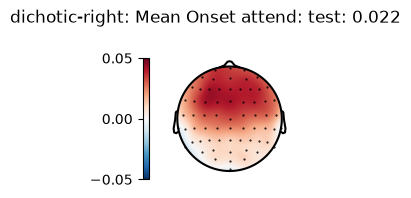

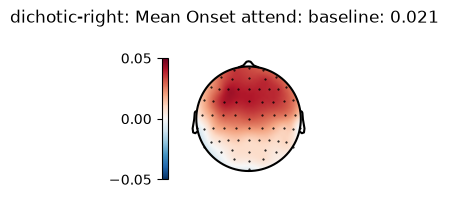

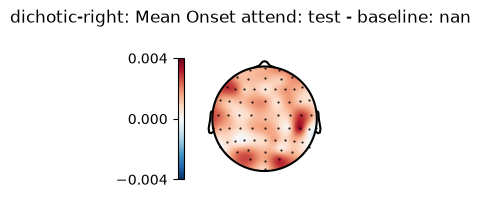

In [ ]:
# Onset attend unique contribution (dichotic-right)
# Brodbeck et al. 2020 ran this comparison too: attended onsets unique contribution, t = 6.32, p < .001.
data, diff, result = compute_unique_contribution(FULL_BASE, onset(ATTEND), 'dichotic-right')
show_topomap_trio(data, diff, result, 'Onset attend', 'dichotic-right', onset(ATTEND))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Onset attend (dichotic-right): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, 8 clusters, p = .130>

Onset attend (dichotic-right): ROI unique contribution t(12) = 1.630, p = 0.0645


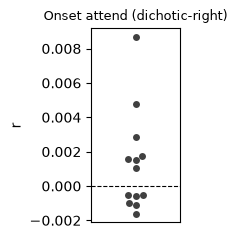

In [ ]:
p = show_subject_swarm(diff, 'Onset attend', 'dichotic-right')

/Users/joshuaighalo/Github Repositories/cocktail-cortical/analysis/experiment.py:957: UserWarning: Warning: converting a masked element to nan.
  mean_value = float(data.mean())


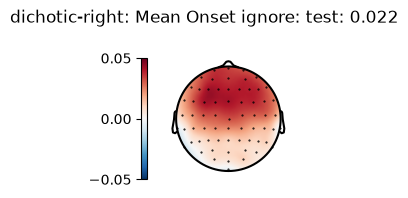

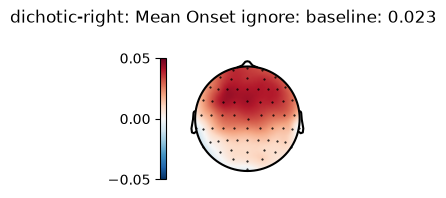

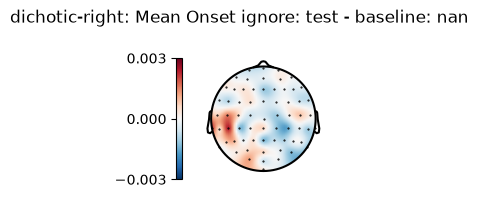

In [ ]:
# Onset ignore unique contribution (dichotic-right)
# Brodbeck et al. 2020 ran this comparison too: ignored onsets unique contribution, t = 6.70, p < .001 - the ignored speaker is tracked separately.
data, diff, result = compute_unique_contribution(FULL_BASE, onset(IGNORE), 'dichotic-right')
show_topomap_trio(data, diff, result, 'Onset ignore', 'dichotic-right', onset(IGNORE))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Onset ignore (dichotic-right): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, 2 clusters, p = .475>

Onset ignore (dichotic-right): ROI unique contribution t(12) = -0.211, p = 0.5819


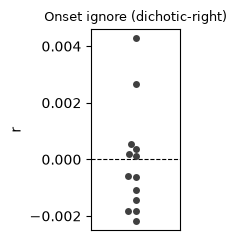

In [ ]:
p = show_subject_swarm(diff, 'Onset ignore', 'dichotic-right')

/Users/joshuaighalo/Github Repositories/cocktail-cortical/analysis/experiment.py:957: UserWarning: Warning: converting a masked element to nan.
  mean_value = float(data.mean())


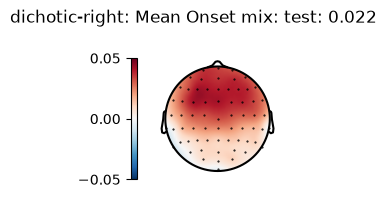

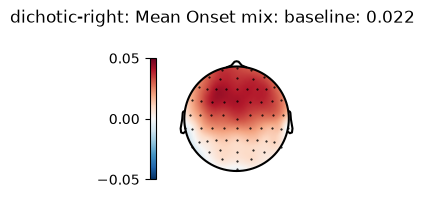

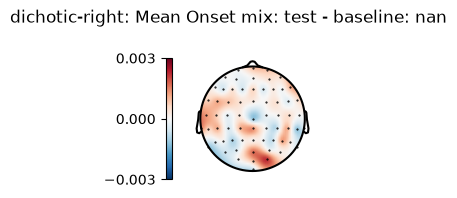

In [ ]:
# Onset mix unique contribution (dichotic-right)
# Brodbeck et al. 2020 ran this comparison too: mixture onsets unique contribution, t = 8.61, p < .001.
data, diff, result = compute_unique_contribution(FULL_BASE, onset(MIX), 'dichotic-right')
show_topomap_trio(data, diff, result, 'Onset mix', 'dichotic-right', onset(MIX))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Onset mix (dichotic-right): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, 2 clusters, p = .217>

Onset mix (dichotic-right): ROI unique contribution t(12) = 0.295, p = 0.3865


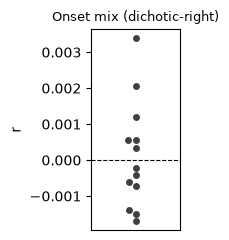

In [ ]:
p = show_subject_swarm(diff, 'Onset mix', 'dichotic-right')

/Users/joshuaighalo/Github Repositories/cocktail-cortical/analysis/experiment.py:957: UserWarning: Warning: converting a masked element to nan.
  mean_value = float(data.mean())


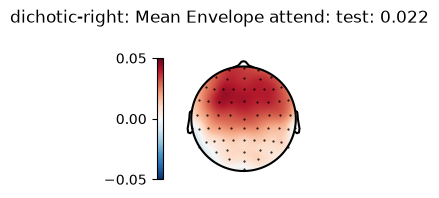

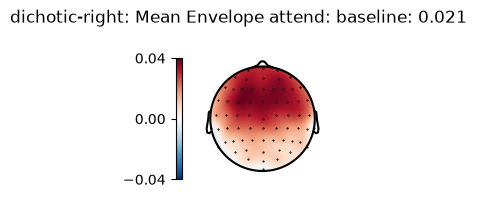

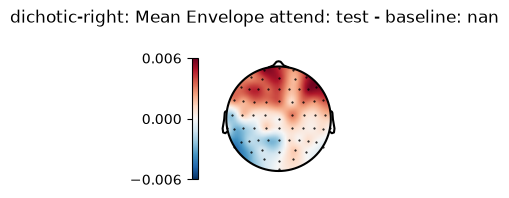

In [ ]:
# Envelope attend unique contribution (dichotic-right)
# Brodbeck et al. 2020 ran this comparison too: attended envelope unique contribution, t = 7.37, p < .001.
data, diff, result = compute_unique_contribution(FULL_BASE, envelope(ATTEND), 'dichotic-right')
show_topomap_trio(data, diff, result, 'Envelope attend', 'dichotic-right', envelope(ATTEND))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Envelope attend (dichotic-right): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, 4 clusters, p = .145>

Envelope attend (dichotic-right): ROI unique contribution t(12) = 1.536, p = 0.0752


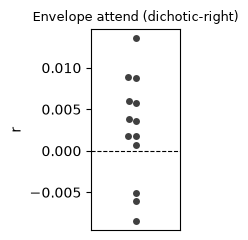

In [ ]:
p = show_subject_swarm(diff, 'Envelope attend', 'dichotic-right')

/Users/joshuaighalo/Github Repositories/cocktail-cortical/analysis/experiment.py:957: UserWarning: Warning: converting a masked element to nan.
  mean_value = float(data.mean())


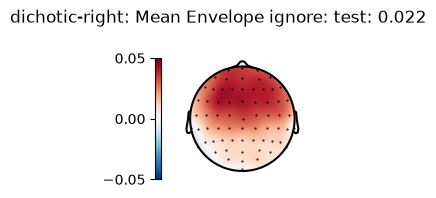

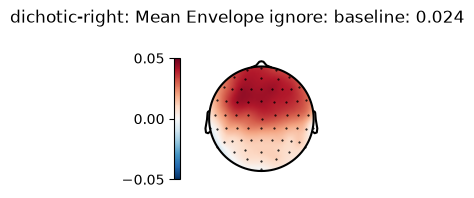

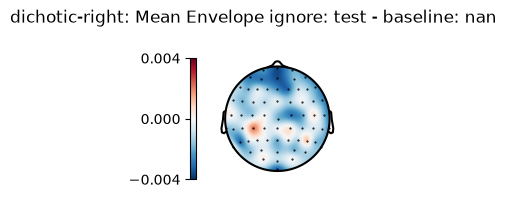

In [ ]:
# Envelope ignore unique contribution (dichotic-right)
# Brodbeck et al. 2020 ran this comparison too: ignored envelope unique contribution, t = 6.28, p < .001 - the ignored speaker's envelope is tracked separately too.
data, diff, result = compute_unique_contribution(FULL_BASE, envelope(IGNORE), 'dichotic-right')
show_topomap_trio(data, diff, result, 'Envelope ignore', 'dichotic-right', envelope(IGNORE))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Envelope ignore (dichotic-right): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, no clusters>

Envelope ignore (dichotic-right): ROI unique contribution t(12) = -2.023, p = 0.9670


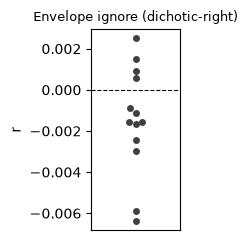

In [ ]:
p = show_subject_swarm(diff, 'Envelope ignore', 'dichotic-right')

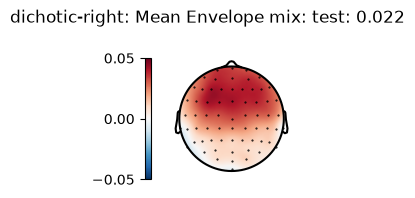

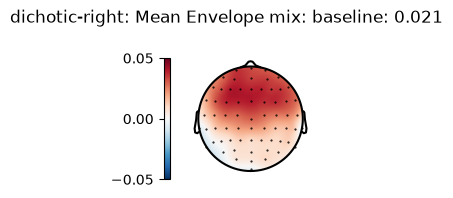

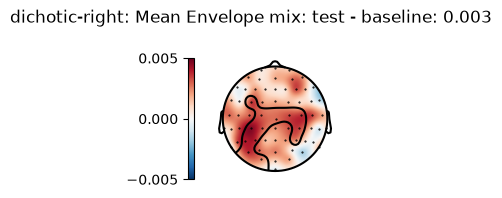

In [ ]:
# Envelope mix unique contribution (dichotic-right)
# Brodbeck et al. 2020 ran this comparison too: mixture envelope unique contribution, t = 5.70, p < .001.
data, diff, result = compute_unique_contribution(FULL_BASE, envelope(MIX), 'dichotic-right')
show_topomap_trio(data, diff, result, 'Envelope mix', 'dichotic-right', envelope(MIX))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Envelope mix (dichotic-right): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, 2 clusters, p = .046>

Envelope mix (dichotic-right): ROI unique contribution t(12) = 1.412, p = 0.0917


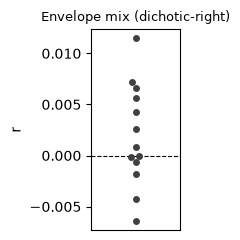

In [ ]:
p = show_subject_swarm(diff, 'Envelope mix', 'dichotic-right')

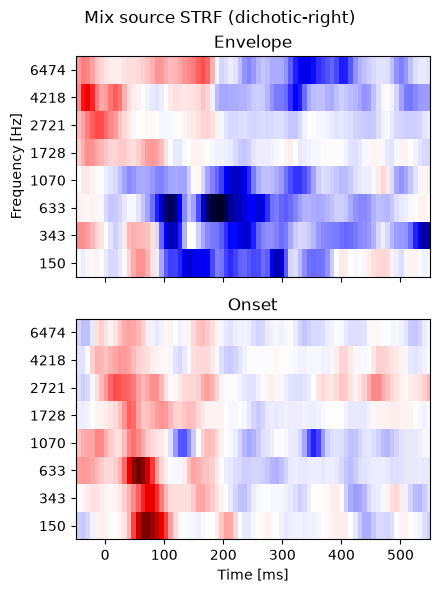

In [ ]:
# Mix source STRF: envelope + onset (dichotic-right)
envelope_strf = extract_strf(data_full, 'mix_gammatone_8')
onset_strf = extract_strf(data_full, 'mix_gammatone_on_8')
p = plot.Array([envelope_strf * 1e3, onset_strf * 1e3], axtitle=['Envelope', 'Onset'],
                title='Mix source STRF (dichotic-right)', xlim=(-0.050, 0.550))

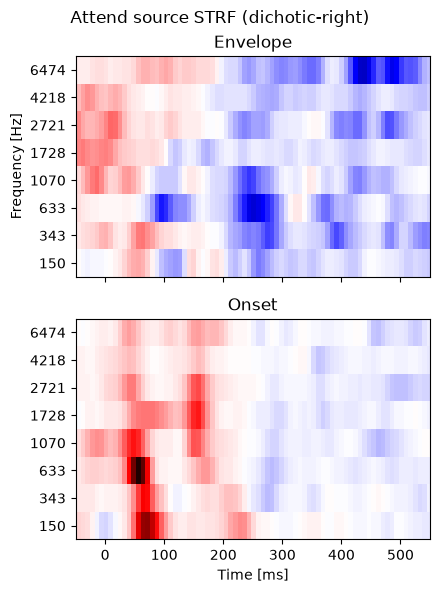

In [ ]:
# Attend source STRF: envelope + onset (dichotic-right)
envelope_strf = extract_strf(data_full, 'gammatone_8')
onset_strf = extract_strf(data_full, 'gammatone_on_8')
p = plot.Array([envelope_strf * 1e3, onset_strf * 1e3], axtitle=['Envelope', 'Onset'],
                title='Attend source STRF (dichotic-right)', xlim=(-0.050, 0.550))

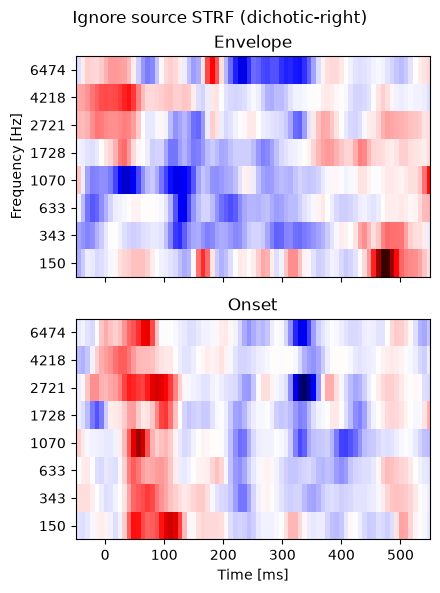

In [ ]:
# Ignore source STRF: envelope + onset (dichotic-right)
envelope_strf = extract_strf(data_full, 'bg_gammatone_8')
onset_strf = extract_strf(data_full, 'bg_gammatone_on_8')
p = plot.Array([envelope_strf * 1e3, onset_strf * 1e3], axtitle=['Envelope', 'Onset'],
                title='Ignore source STRF (dichotic-right)', xlim=(-0.050, 0.550))

In [ ]:
# Onset attend peak amplitude & timing (dichotic-right)
data = extract_trf(data_full, 'gammatone_on_8')
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Onset attend (dichotic-right) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Onset attend (dichotic-right) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

Onset attend (dichotic-right) positive peak: 92 ms, amp 0.002173
Onset attend (dichotic-right) negative peak: 133 ms, amp -8.258e-05


In [ ]:
# Onset ignore peak amplitude & timing (dichotic-right)
data = extract_trf(data_full, 'bg_gammatone_on_8')
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Onset ignore (dichotic-right) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Onset ignore (dichotic-right) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

Onset ignore (dichotic-right) positive peak: 97 ms, amp 0.0009832
Onset ignore (dichotic-right) negative peak: 151 ms, amp -0.0002075


In [ ]:
# Onset mix peak amplitude & timing (dichotic-right)
data = extract_trf(data_full, 'mix_gammatone_on_8')
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Onset mix (dichotic-right) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Onset mix (dichotic-right) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

Onset mix (dichotic-right) positive peak: 80 ms, amp 0.001395
Onset mix (dichotic-right) negative peak: 141 ms, amp -0.0002612


In [ ]:
# Envelope attend peak amplitude & timing (dichotic-right)
data = extract_trf(data_full, 'gammatone_8')
data = add_peak(data, 'positive', ENVELOPE_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ENVELOPE_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Envelope attend (dichotic-right) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Envelope attend (dichotic-right) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

Envelope attend (dichotic-right) positive peak: 76 ms, amp 0.0007075
Envelope attend (dichotic-right) negative peak: 143 ms, amp -0.0007442


In [ ]:
# Envelope ignore peak amplitude & timing (dichotic-right)
data = extract_trf(data_full, 'bg_gammatone_8')
data = add_peak(data, 'positive', ENVELOPE_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ENVELOPE_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Envelope ignore (dichotic-right) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Envelope ignore (dichotic-right) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

Envelope ignore (dichotic-right) positive peak: 96 ms, amp 0.0004461
Envelope ignore (dichotic-right) negative peak: 126 ms, amp -0.000688


In [ ]:
# Envelope mix peak amplitude & timing (dichotic-right)
data = extract_trf(data_full, 'mix_gammatone_8')
data = add_peak(data, 'positive', ENVELOPE_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ENVELOPE_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Envelope mix (dichotic-right) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Envelope mix (dichotic-right) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

Envelope mix (dichotic-right) positive peak: 88 ms, amp 0.0005145
Envelope mix (dichotic-right) negative peak: 135 ms, amp -0.001236


In [ ]:
# Onset peak comparison across mix, attend, and ignore (dichotic-right)
# Brodbeck et al. 2020 ran this comparison too: positive peak latency mixture 72ms, attended 81ms (t=4.47,p<.001), ignored 89ms (t=6.92,p<.001); negative peak latency mixture 138ms, attended 150ms (t=3.20,p=.004); positive peak amplitude bigger for mixture than attended (t=8.41) or ignored (t=7.66).
dss = []
for role_name, column in (('mix', 'mix_gammatone_on_8'), ('attend', 'gammatone_on_8'), ('ignore', 'bg_gammatone_on_8')):
    ds = extract_trf(data_full, column)
    ds[:, 'role'] = role_name
    dss.append(ds)
data = combine(dss)
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')

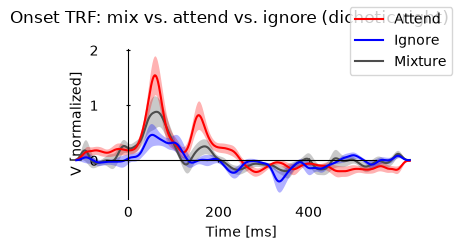

In [ ]:
# The onset TRF waveform mix/attend/ignore were each just measured
# from, overlaid so their shape and relative timing are visible
# directly, not just as extracted peak numbers below.
p = plot.UTSStat('trf_sm*1e3', 'role', data=data, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550),
                  title='Onset TRF: mix vs. attend vs. ignore (dichotic-right)', labels=LABELS_ROLE, colors=COLORS_ROLE)

In [ ]:
print_peak_table(data, 'positive', 'role')
print_peak_table(data, 'negative', 'role')


positive peak
subject   role         time (ms)           amp
01        mix                171      0.001403
02        mix                 76      0.001594
03        mix                103     0.0003224
04        mix                140     0.0007347
05        mix                 54      0.001149
06        mix                 41     0.0002812
07        mix                 88       0.00163
08        mix                 46      0.002035
09        mix                 74      0.002501
10        mix                 56       0.00411
11        mix                 45     0.0008108
12        mix                 80      0.001474
13        mix                 64     8.543e-05
01        attend             152      0.001071
02        attend              56      0.001831
03        attend             105     0.0007201
04        attend              56      0.000899
05        attend              54       0.00422
06        attend             154      0.001938
07        attend             152      0.00142

In [ ]:
display(test.pairwise('positive_time', 'role', match='subject', data=data, corr=False, title='onset positive peak latency: mix vs. attend vs. ignore'))
display(test.pairwise('negative_time', 'role', match='subject', data=data, corr=False, title='onset negative peak latency: mix vs. attend vs. ignore'))

,attend,ignore
mix,t12 = -0.89 p = .390,t12 = -1.14 p = .277
attend,,t12 = -0.25 p = .806


,attend,ignore
mix,t12 = 0.61 p = .556,t12 = -0.61 p = .553
attend,,t12 = -1.00 p = .337


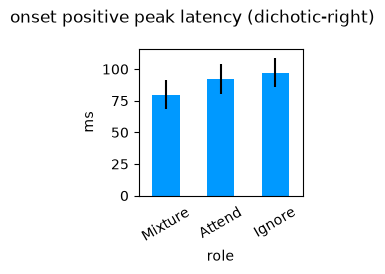

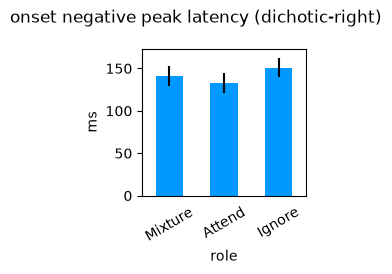

In [ ]:
p = plot.Barplot('positive_time', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='onset positive peak latency (dichotic-right)')
p.set_xtick_rotation(30)
p = plot.Barplot('negative_time', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='onset negative peak latency (dichotic-right)')
p.set_xtick_rotation(30)

In [ ]:
display(test.pairwise('positive_amp', 'role', match='subject', data=data, corr=False, title='onset positive peak amplitude: mix vs. attend vs. ignore'))
display(test.pairwise('negative_amp', 'role', match='subject', data=data, corr=False, title='onset negative peak amplitude: mix vs. attend vs. ignore'))

,attend,ignore
mix,t12 = -2.03 p = .065,t12 = 1.39 p = .190
attend,,t12 = 2.91* p = .013


,attend,ignore
mix,t12 = -1.55 p = .147,t12 = -0.48 p = .640
attend,,t12 = 1.21 p = .251


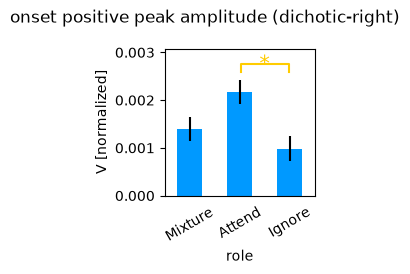

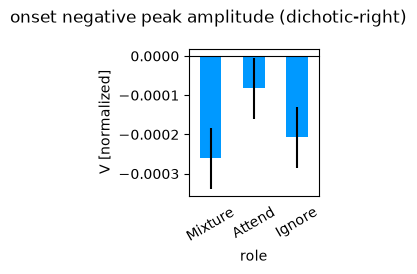

In [ ]:
p = plot.Barplot('positive_amp', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='onset positive peak amplitude (dichotic-right)')
p.set_xtick_rotation(30)
p = plot.Barplot('negative_amp', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='onset negative peak amplitude (dichotic-right)')
p.set_xtick_rotation(30)

In [ ]:
# Envelope peak comparison across mix, attend, and ignore (dichotic-right)
dss = []
for role_name, column in (('mix', 'mix_gammatone_8'), ('attend', 'gammatone_8'), ('ignore', 'bg_gammatone_8')):
    ds = extract_trf(data_full, column)
    ds[:, 'role'] = role_name
    dss.append(ds)
data = combine(dss)
data = add_peak(data, 'positive', ENVELOPE_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ENVELOPE_NEGATIVE_PEAK_WINDOW, kind='min')

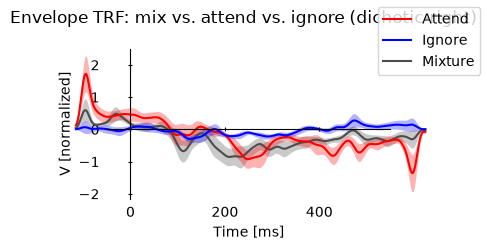

In [ ]:
# The envelope TRF waveform mix/attend/ignore were each just measured
# from, overlaid so their shape and relative timing are visible
# directly, not just as extracted peak numbers below.
p = plot.UTSStat('trf_sm*1e3', 'role', data=data, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550),
                  title='Envelope TRF: mix vs. attend vs. ignore (dichotic-right)', labels=LABELS_ROLE, colors=COLORS_ROLE)

In [ ]:
print_peak_table(data, 'positive', 'role')
print_peak_table(data, 'negative', 'role')


positive peak
subject   role         time (ms)           amp
01        mix                 72      0.001927
02        mix                 60    -1.426e-05
03        mix                181     0.0009236
04        mix                 41     0.0001736
05        mix                 50     -0.000233
06        mix                125     5.969e-06
07        mix                 41     4.862e-05
08        mix                 64     0.0008558
09        mix                 76     0.0001641
10        mix                 41     0.0009752
11        mix                 41     7.481e-06
12        mix                181     2.327e-05
13        mix                170      0.001831
01        attend              74      0.002616
02        attend              41     1.094e-05
03        attend              97      0.000435
04        attend              66     6.877e-05
05        attend             160     0.0002211
06        attend             111      0.001422
07        attend              93     0.000346

In [ ]:
display(test.pairwise('positive_time', 'role', match='subject', data=data, corr=False, title='envelope positive peak latency: mix vs. attend vs. ignore'))
display(test.pairwise('negative_time', 'role', match='subject', data=data, corr=False, title='envelope negative peak latency: mix vs. attend vs. ignore'))

,attend,ignore
mix,t12 = 0.63 p = .539,t12 = -0.55 p = .590
attend,,t12 = -1.06 p = .312


,attend,ignore
mix,t12 = -0.48 p = .642,t12 = 0.61 p = .556
attend,,t12 = 1.29 p = .223


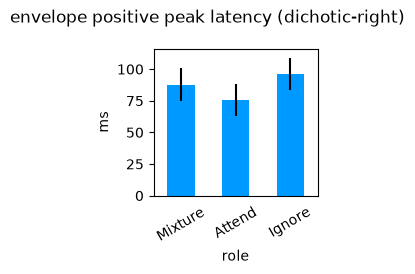

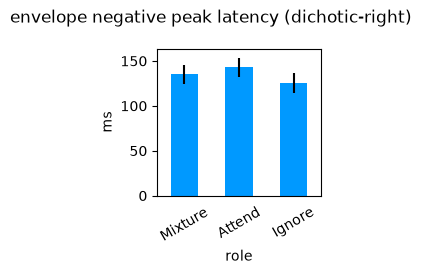

In [ ]:
p = plot.Barplot('positive_time', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='envelope positive peak latency (dichotic-right)')
p.set_xtick_rotation(30)
p = plot.Barplot('negative_time', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='envelope negative peak latency (dichotic-right)')
p.set_xtick_rotation(30)

In [ ]:
display(test.pairwise('positive_amp', 'role', match='subject', data=data, corr=False, title='envelope positive peak amplitude: mix vs. attend vs. ignore'))
display(test.pairwise('negative_amp', 'role', match='subject', data=data, corr=False, title='envelope negative peak amplitude: mix vs. attend vs. ignore'))

,attend,ignore
mix,t12 = -0.96 p = .356,t12 = 0.32 p = .756
attend,,t12 = 0.78 p = .453


,attend,ignore
mix,t12 = -1.68 p = .120,t12 = -1.42 p = .182
attend,,t12 = -0.16 p = .877


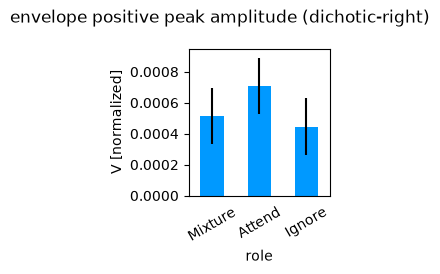

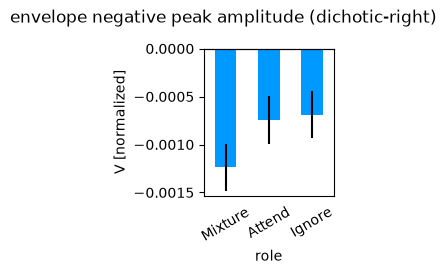

In [ ]:
p = plot.Barplot('positive_amp', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='envelope positive peak amplitude (dichotic-right)')
p.set_xtick_rotation(30)
p = plot.Barplot('negative_amp', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='envelope negative peak amplitude (dichotic-right)')
p.set_xtick_rotation(30)

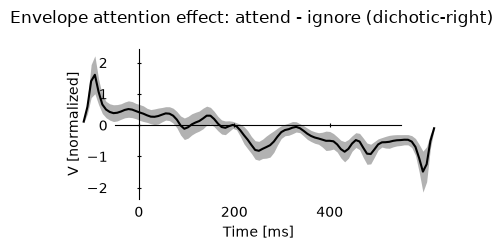

In [ ]:
# Envelope attention effect: attend - ignore (dichotic-right)
# Brodbeck et al. 2020 ran this comparison too: envelope attention-effect difference wave: negative bump ~100ms, positive bump ~200ms, starting almost immediately.
attend_trf = data_full['gammatone_8'].sum('frequency').mean(sensor=ROI)
ignore_trf = data_full['bg_gammatone_8'].sum('frequency').mean(sensor=ROI)
attention_effect = attend_trf - ignore_trf
p = plot.UTSStat(attention_effect * 1e3, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550), title='Envelope attention effect: attend - ignore (dichotic-right)')

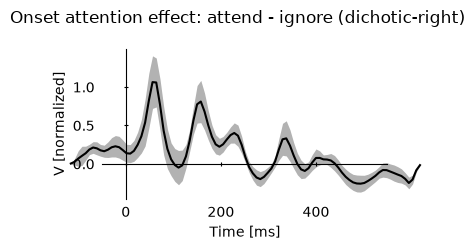

In [ ]:
# Onset attention effect: attend - ignore (dichotic-right)
# Brodbeck et al. 2020 ran this comparison too: onset attention effect appears later than the envelope's, once the masked-onset response develops (see the masked-onset section below).
attend_trf = data_full['gammatone_on_8'].sum('frequency').mean(sensor=ROI)
ignore_trf = data_full['bg_gammatone_on_8'].sum('frequency').mean(sensor=ROI)
attention_effect = attend_trf - ignore_trf
p = plot.UTSStat(attention_effect * 1e3, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550), title='Onset attention effect: attend - ignore (dichotic-right)')

## Dichotic Right (overt onsets)

/Users/joshuaighalo/Github Repositories/cocktail-cortical/analysis/experiment.py:957: UserWarning: Warning: converting a masked element to nan.
  mean_value = float(data.mean())


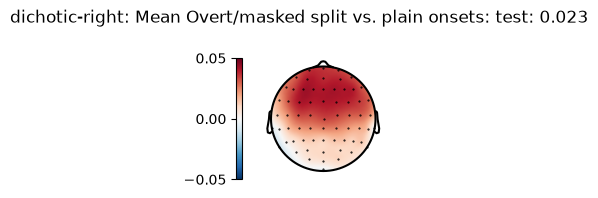

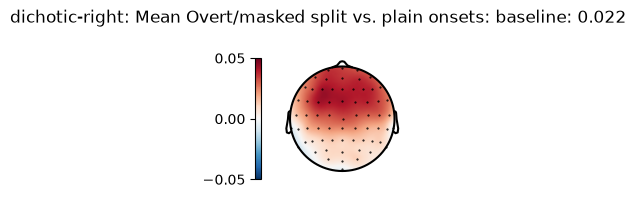

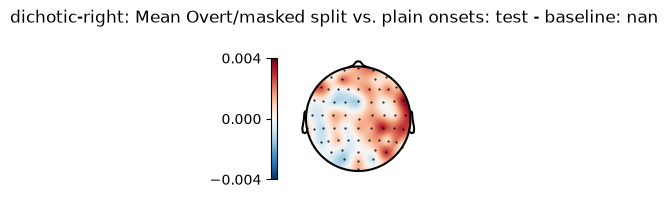

In [ ]:
# Overt/masked split vs. plain onsets (dichotic-right)
# Brodbeck et al. 2020 ran this comparison too: splitting onsets into overt/masked significantly improved the model overall, t = 6.81, p < .001.
data, diff, result = compute_direct_comparison(FULL_MASKED, FULL_BASE, 'dichotic-right')
show_topomap_trio(data, diff, result, 'Overt/masked split vs. plain onsets', 'dichotic-right', None)

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Overt/masked split vs. plain onsets (dichotic-right): ROI model comparison t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, 7 clusters, p = .178>

Overt/masked split vs. plain onsets (dichotic-right): ROI model comparison t(12) = 1.041, p = 0.1592


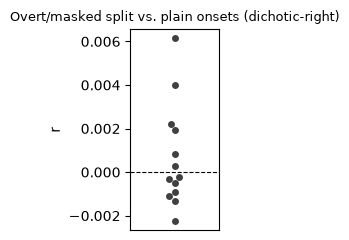

In [ ]:
p = show_subject_swarm(diff, 'Overt/masked split vs. plain onsets', 'dichotic-right')

In [ ]:
# Loaded once here, reused by every STRF/peak/waveform/attention-
# effect/masking-comparison cell in both this subsection and "masked
# onset" below - same reasoning as data_full above, for FULL_MASKED.
data_masked = e.load_trfs('all', FULL_MASKED, epoch='dichotic-right', **PARAMETERS)

/Users/joshuaighalo/Github Repositories/cocktail-cortical/analysis/experiment.py:957: UserWarning: Warning: converting a masked element to nan.
  mean_value = float(data.mean())


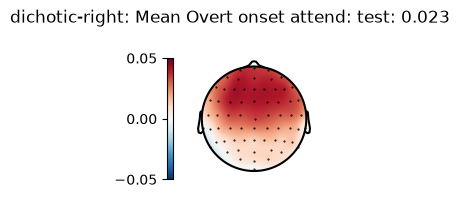

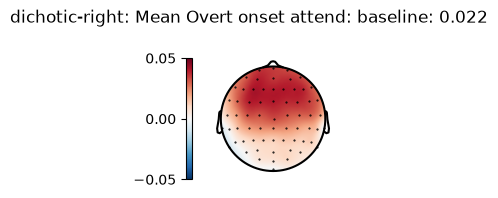

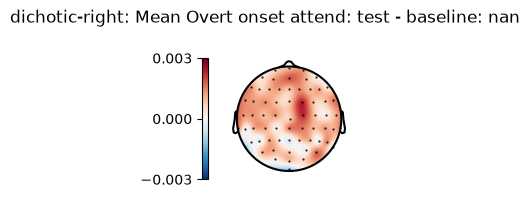

In [ ]:
# Overt onset attend unique contribution (dichotic-right)
# Brodbeck et al. 2020 ran this comparison too: attended overt onsets unique contribution, t = 3.34, p = .027.
data, diff, result = compute_unique_contribution(FULL_MASKED, overt_onset(ATTEND), 'dichotic-right')
show_topomap_trio(data, diff, result, 'Overt onset attend', 'dichotic-right', overt_onset(ATTEND))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Overt onset attend (dichotic-right): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, 5 clusters, p = .126>

Overt onset attend (dichotic-right): ROI unique contribution t(12) = 2.253, p = 0.0219


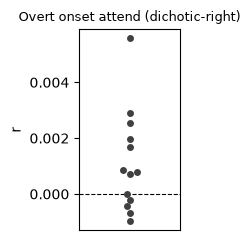

In [ ]:
p = show_subject_swarm(diff, 'Overt onset attend', 'dichotic-right')

/Users/joshuaighalo/Github Repositories/cocktail-cortical/analysis/experiment.py:957: UserWarning: Warning: converting a masked element to nan.
  mean_value = float(data.mean())


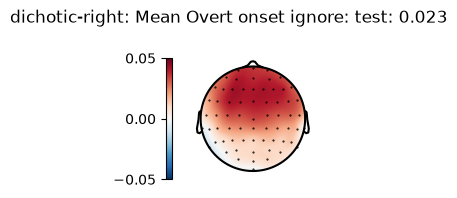

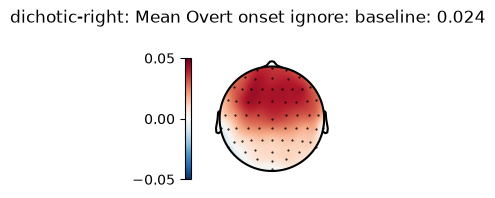

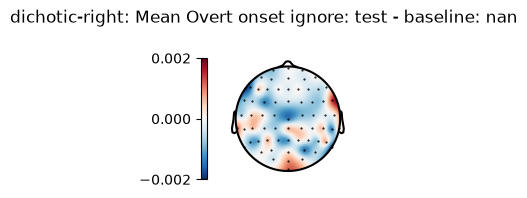

In [ ]:
# Overt onset ignore unique contribution (dichotic-right)
# Brodbeck et al. 2020 ran this comparison too: ignored overt onsets unique contribution, t = 3.82, p = .016.
data, diff, result = compute_unique_contribution(FULL_MASKED, overt_onset(IGNORE), 'dichotic-right')
show_topomap_trio(data, diff, result, 'Overt onset ignore', 'dichotic-right', overt_onset(IGNORE))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Overt onset ignore (dichotic-right): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, no clusters>

Overt onset ignore (dichotic-right): ROI unique contribution t(12) = -1.326, p = 0.8952


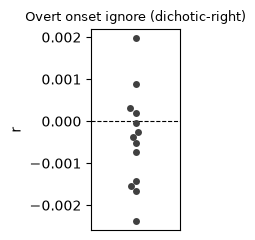

In [ ]:
p = show_subject_swarm(diff, 'Overt onset ignore', 'dichotic-right')

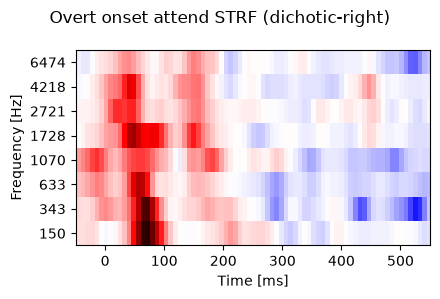

In [ ]:
# Overt onset attend STRF (dichotic-right)
strf = extract_strf(data_masked, 'gammatone_on_overt_8')
p = plot.Array(strf * 1e3, title='Overt onset attend STRF (dichotic-right)', xlim=(-0.050, 0.550))

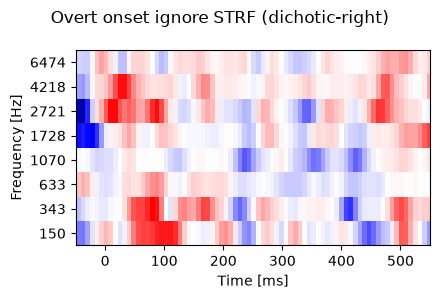

In [ ]:
# Overt onset ignore STRF (dichotic-right)
strf = extract_strf(data_masked, 'bg_gammatone_on_overt_8')
p = plot.Array(strf * 1e3, title='Overt onset ignore STRF (dichotic-right)', xlim=(-0.050, 0.550))

In [ ]:
# Overt onset attend peak amplitude & timing (dichotic-right)
data = extract_trf(data_masked, 'gammatone_on_overt_8')
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Overt onset attend (dichotic-right) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Overt onset attend (dichotic-right) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

Overt onset attend (dichotic-right) positive peak: 91 ms, amp 0.001925
Overt onset attend (dichotic-right) negative peak: 152 ms, amp -0.0001087


In [ ]:
# Overt onset ignore peak amplitude & timing (dichotic-right)
data = extract_trf(data_masked, 'bg_gammatone_on_overt_8')
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Overt onset ignore (dichotic-right) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Overt onset ignore (dichotic-right) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

Overt onset ignore (dichotic-right) positive peak: 72 ms, amp 0.0005911
Overt onset ignore (dichotic-right) negative peak: 139 ms, amp -0.0001648


In [ ]:
# Overt onset peak comparison across attend and ignore (dichotic-right)
dss = []
for role_name, column in (('attend', 'gammatone_on_overt_8'), ('ignore', 'bg_gammatone_on_overt_8')):
    ds = extract_trf(data_masked, column)
    ds[:, 'role'] = role_name
    dss.append(ds)
data = combine(dss)
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')

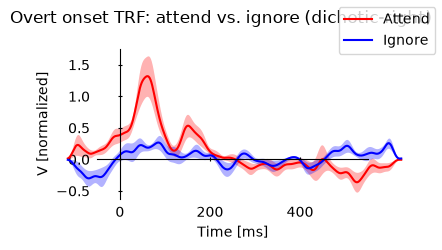

In [ ]:
# The overt onset TRF waveform attend/ignore were each just measured
# from, overlaid so their shape and relative timing are visible
# directly, not just as extracted peak numbers below.
p = plot.UTSStat('trf_sm*1e3', 'role', data=data, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550),
                  title='Overt onset TRF: attend vs. ignore (dichotic-right)', labels={'attend': 'Attend', 'ignore': 'Ignore'}, colors={'attend': 'red', 'ignore': 'blue'})

In [ ]:
print_peak_table(data, 'positive', 'role')
print_peak_table(data, 'negative', 'role')


positive peak
subject   role         time (ms)           amp
01        attend             181      0.001323
02        attend              66      0.002096
03        attend             103     0.0009559
04        attend             146      0.001655
05        attend              48      0.003305
06        attend             152     0.0009462
07        attend              97     0.0007014
08        attend              48      0.002092
09        attend              68       0.00359
10        attend              60      0.003687
11        attend              60     0.0005605
12        attend              82       0.00279
13        attend              68      0.001324
01        ignore              70     0.0002718
02        ignore              89     0.0006007
03        ignore             119     0.0001989
04        ignore              41     0.0008113
05        ignore              64     0.0004529
06        ignore              41     0.0001538
07        ignore              91       0.0014

In [ ]:
display(test.pairwise('positive_time', 'role', match='subject', data=data, corr=False, title='overt onset positive peak latency: attend vs. ignore'))
display(test.pairwise('negative_time', 'role', match='subject', data=data, corr=False, title='overt onset negative peak latency: attend vs. ignore'))

,ignore
attend,t12 = 1.18 p = .262


,ignore
attend,t12 = 0.93 p = .372


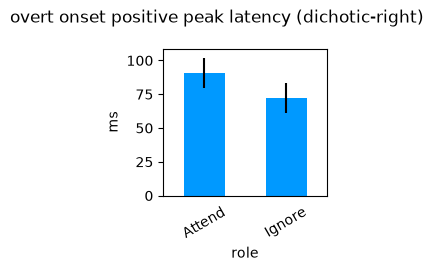

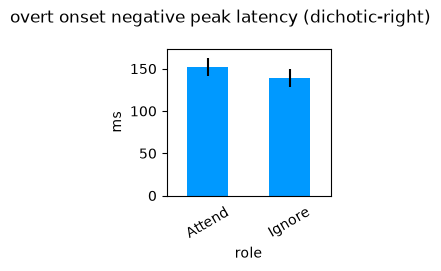

In [ ]:
p = plot.Barplot('positive_time', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='overt onset positive peak latency (dichotic-right)')
p.set_xtick_rotation(30)
p = plot.Barplot('negative_time', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='overt onset negative peak latency (dichotic-right)')
p.set_xtick_rotation(30)

In [ ]:
display(test.pairwise('positive_amp', 'role', match='subject', data=data, corr=False, title='overt onset positive peak amplitude: attend vs. ignore'))
display(test.pairwise('negative_amp', 'role', match='subject', data=data, corr=False, title='overt onset negative peak amplitude: attend vs. ignore'))

,ignore
attend,t12 = 3.51** p = .004


,ignore
attend,t12 = 0.60 p = .557


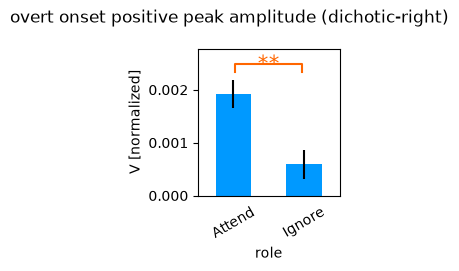

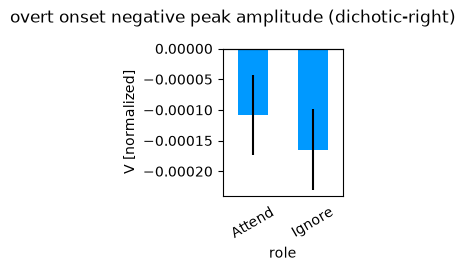

In [ ]:
p = plot.Barplot('positive_amp', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='overt onset positive peak amplitude (dichotic-right)')
p.set_xtick_rotation(30)
p = plot.Barplot('negative_amp', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='overt onset negative peak amplitude (dichotic-right)')
p.set_xtick_rotation(30)

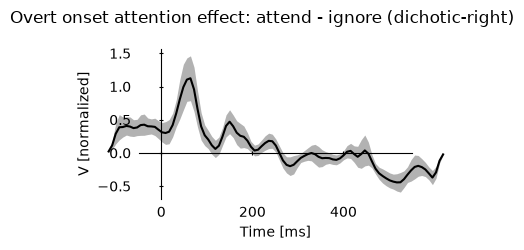

In [ ]:
# Overt onset attention effect: attend - ignore (dichotic-right)
attend_trf = data_masked['gammatone_on_overt_8'].sum('frequency').mean(sensor=ROI)
ignore_trf = data_masked['bg_gammatone_on_overt_8'].sum('frequency').mean(sensor=ROI)
attention_effect = attend_trf - ignore_trf
p = plot.UTSStat(attention_effect * 1e3, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550), title='Overt onset attention effect: attend - ignore (dichotic-right)')

## Dichotic Right (masked onset)

Permutation test:   0%|          | 0/8191 [00:00<?, ? permutations/s]

/Users/joshuaighalo/Github Repositories/cocktail-cortical/analysis/experiment.py:957: UserWarning: Warning: converting a masked element to nan.
  mean_value = float(data.mean())


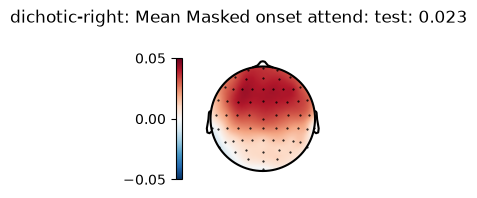

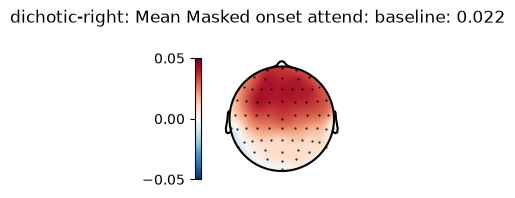

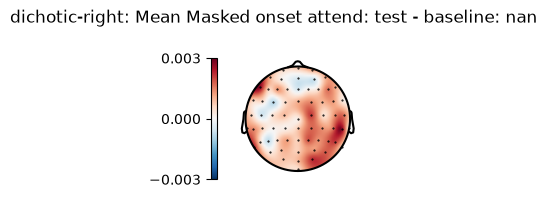

In [ ]:
# Masked onset attend unique contribution (dichotic-right)
# Brodbeck et al. 2020 ran this comparison too: attended masked onsets unique contribution, t = 8.42, p < .001 - the strongest of the four masking predictors.
data, diff, result = compute_unique_contribution(FULL_MASKED, masked_onset(ATTEND), 'dichotic-right')
show_topomap_trio(data, diff, result, 'Masked onset attend', 'dichotic-right', masked_onset(ATTEND))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Masked onset attend (dichotic-right): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, 3 clusters, p = .283>

Masked onset attend (dichotic-right): ROI unique contribution t(12) = 0.778, p = 0.2258


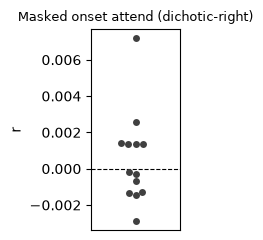

In [ ]:
p = show_subject_swarm(diff, 'Masked onset attend', 'dichotic-right')

Permutation test:   0%|          | 0/8191 [00:00<?, ? permutations/s]

/Users/joshuaighalo/Github Repositories/cocktail-cortical/analysis/experiment.py:957: UserWarning: Warning: converting a masked element to nan.
  mean_value = float(data.mean())


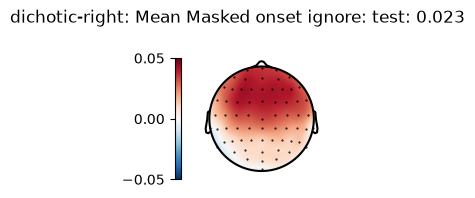

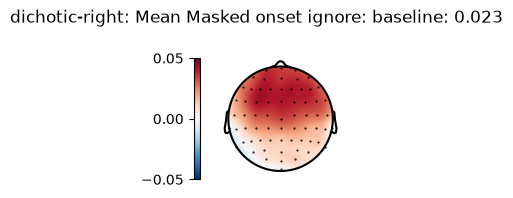

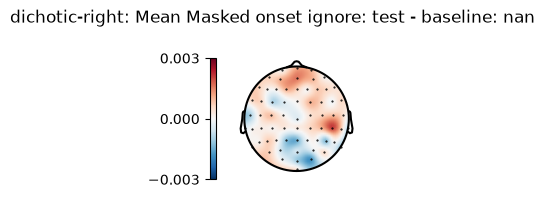

In [ ]:
# Masked onset ignore unique contribution (dichotic-right)
# Brodbeck et al. 2020 ran this comparison too: ignored masked onsets unique contribution, t = 5.23, p < .001 - the brain recovers masked information even for the ignored speaker.
data, diff, result = compute_unique_contribution(FULL_MASKED, masked_onset(IGNORE), 'dichotic-right')
show_topomap_trio(data, diff, result, 'Masked onset ignore', 'dichotic-right', masked_onset(IGNORE))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Masked onset ignore (dichotic-right): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, 1 clusters, p = .477>

Masked onset ignore (dichotic-right): ROI unique contribution t(12) = 0.614, p = 0.2752


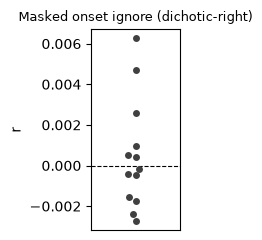

In [ ]:
p = show_subject_swarm(diff, 'Masked onset ignore', 'dichotic-right')

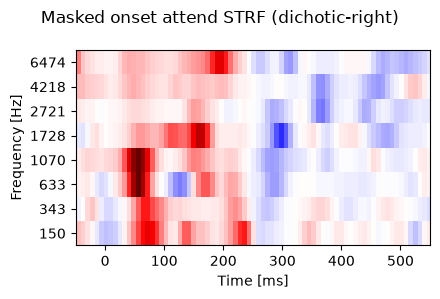

In [ ]:
# Masked onset attend STRF (dichotic-right)
strf = extract_strf(data_masked, 'gammatone_on_masked_8')
p = plot.Array(strf * 1e3, title='Masked onset attend STRF (dichotic-right)', xlim=(-0.050, 0.550))

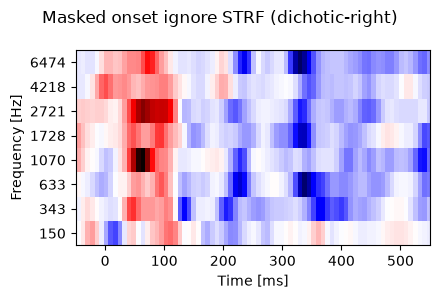

In [ ]:
# Masked onset ignore STRF (dichotic-right)
strf = extract_strf(data_masked, 'bg_gammatone_on_masked_8')
p = plot.Array(strf * 1e3, title='Masked onset ignore STRF (dichotic-right)', xlim=(-0.050, 0.550))

In [ ]:
# Masked onset attend peak amplitude & timing (dichotic-right)
data = extract_trf(data_masked, 'gammatone_on_masked_8')
data = add_peak(data, 'positive', MASKED_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', MASKED_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Masked onset attend (dichotic-right) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Masked onset attend (dichotic-right) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

Masked onset attend (dichotic-right) positive peak: 101 ms, amp 0.001334
Masked onset attend (dichotic-right) negative peak: 116 ms, amp -0.0001904


In [ ]:
# Masked onset ignore peak amplitude & timing (dichotic-right)
data = extract_trf(data_masked, 'bg_gammatone_on_masked_8')
data = add_peak(data, 'positive', MASKED_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', MASKED_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Masked onset ignore (dichotic-right) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Masked onset ignore (dichotic-right) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

Masked onset ignore (dichotic-right) positive peak: 90 ms, amp 0.000911
Masked onset ignore (dichotic-right) negative peak: 169 ms, amp -0.0003779


In [ ]:
# Masked onset peak comparison across attend and ignore (dichotic-right)
dss = []
for role_name, column in (('attend', 'gammatone_on_masked_8'), ('ignore', 'bg_gammatone_on_masked_8')):
    ds = extract_trf(data_masked, column)
    ds[:, 'role'] = role_name
    dss.append(ds)
data = combine(dss)
data = add_peak(data, 'positive', MASKED_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', MASKED_NEGATIVE_PEAK_WINDOW, kind='min')

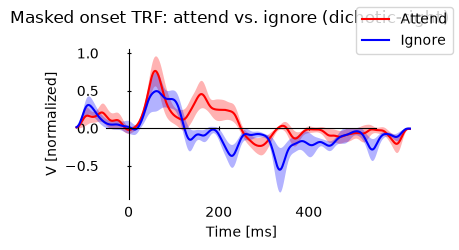

In [ ]:
# The masked onset TRF waveform attend/ignore were each just measured
# from, overlaid so their shape and relative timing are visible
# directly, not just as extracted peak numbers below.
p = plot.UTSStat('trf_sm*1e3', 'role', data=data, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550),
                  title='Masked onset TRF: attend vs. ignore (dichotic-right)', labels={'attend': 'Attend', 'ignore': 'Ignore'}, colors={'attend': 'red', 'ignore': 'blue'})

In [ ]:
print_peak_table(data, 'positive', 'role')
print_peak_table(data, 'negative', 'role')


positive peak
subject   role         time (ms)           amp
01        attend             142      0.001122
02        attend              52     0.0007895
03        attend              97     0.0002124
04        attend              54      0.001098
05        attend              54      0.002032
06        attend             199      0.001616
07        attend             134      0.001292
08        attend              56      0.001967
09        attend             162      0.002107
10        attend              60     0.0008847
11        attend              62     0.0009655
12        attend             168     0.0002913
13        attend              74       0.00297
01        ignore              72     0.0006577
02        ignore              99     0.0002526
03        ignore             173     0.0003676
04        ignore             113     0.0004898
05        ignore              88      0.001222
06        ignore              41      0.001245
07        ignore              82     0.000557

In [ ]:
display(test.pairwise('positive_time', 'role', match='subject', data=data, corr=False, title='masked onset positive peak latency: attend vs. ignore'))
display(test.pairwise('negative_time', 'role', match='subject', data=data, corr=False, title='masked onset negative peak latency: attend vs. ignore'))

,ignore
attend,t12 = 0.53 p = .607


,ignore
attend,t12 = -4.29** p = .001


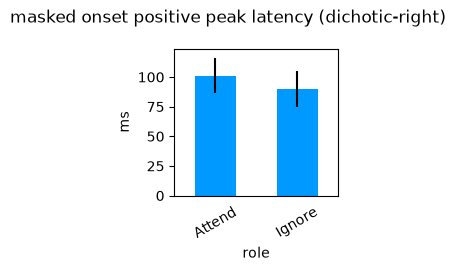

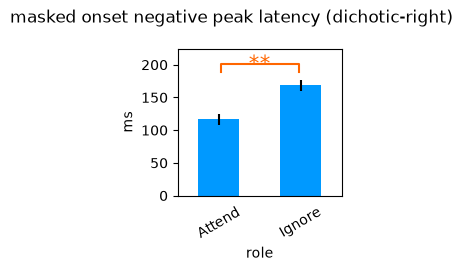

In [ ]:
p = plot.Barplot('positive_time', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='masked onset positive peak latency (dichotic-right)')
p.set_xtick_rotation(30)
p = plot.Barplot('negative_time', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='masked onset negative peak latency (dichotic-right)')
p.set_xtick_rotation(30)

In [ ]:
display(test.pairwise('positive_amp', 'role', match='subject', data=data, corr=False, title='masked onset positive peak amplitude: attend vs. ignore'))
display(test.pairwise('negative_amp', 'role', match='subject', data=data, corr=False, title='masked onset negative peak amplitude: attend vs. ignore'))

,ignore
attend,t12 = 1.30 p = .218


,ignore
attend,t12 = 1.17 p = .264


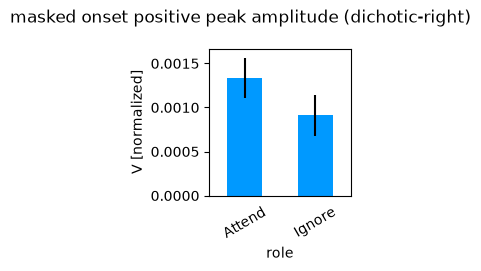

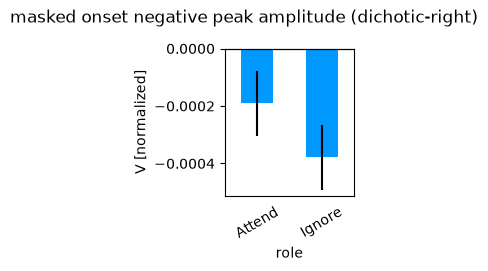

In [ ]:
p = plot.Barplot('positive_amp', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='masked onset positive peak amplitude (dichotic-right)')
p.set_xtick_rotation(30)
p = plot.Barplot('negative_amp', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='masked onset negative peak amplitude (dichotic-right)')
p.set_xtick_rotation(30)

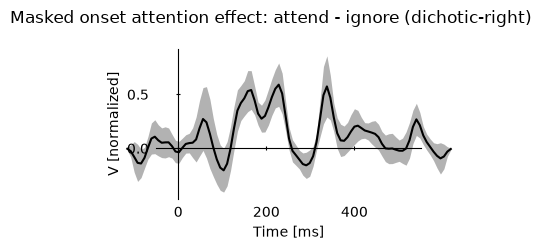

In [ ]:
# Masked onset attention effect: attend - ignore (dichotic-right)
attend_trf = data_masked['gammatone_on_masked_8'].sum('frequency').mean(sensor=ROI)
ignore_trf = data_masked['bg_gammatone_on_masked_8'].sum('frequency').mean(sensor=ROI)
attention_effect = attend_trf - ignore_trf
p = plot.UTSStat(attention_effect * 1e3, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550), title='Masked onset attention effect: attend - ignore (dichotic-right)')

In [ ]:
# Overt vs. masked peak comparison, attend (dichotic-right)
# Brodbeck et al. 2020 ran this comparison too: attended overt 72ms vs. attended masked 91ms (t=2.85,p=.009); combined (not stream-split) late negative peak, overt 133ms vs. masked 182ms (t=4.45,p<.001).
dss = []
for masking, column in (('overt', 'gammatone_on_overt_8'), ('masked', 'gammatone_on_masked_8')):
    ds = extract_trf(data_masked, column)
    ds[:, 'masking'] = masking
    dss.append(ds)
data = combine(dss)
data = add_peak(data, 'positive', MASKED_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', MASKED_NEGATIVE_PEAK_WINDOW, kind='min')

In [ ]:
print_peak_table(data, 'positive', 'masking')
print_peak_table(data, 'negative', 'masking')


positive peak
subject   masking      time (ms)           amp
01        overt              181      0.001323
02        overt               66      0.002096
03        overt              103     0.0009559
04        overt              146      0.001655
05        overt               48      0.003305
06        overt              152     0.0009462
07        overt               97     0.0007014
08        overt               48      0.002092
09        overt               68       0.00359
10        overt               60      0.003687
11        overt               60     0.0005605
12        overt               82       0.00279
13        overt               68      0.001324
01        masked             142      0.001122
02        masked              52     0.0007895
03        masked              97     0.0002124
04        masked              54      0.001098
05        masked              54      0.002032
06        masked             199      0.001616
07        masked             134      0.00129

In [ ]:
display(test.pairwise('positive_time', 'masking', match='subject', data=data, corr=False, title='attend positive peak latency: overt vs. masked'))
display(test.pairwise('negative_time', 'masking', match='subject', data=data, corr=False, title='attend negative peak latency: overt vs. masked'))

,masked
overt,t12 = -0.76 p = .459


,masked
overt,t12 = 2.09 p = .059


In [ ]:
display(test.pairwise('positive_amp', 'masking', match='subject', data=data, corr=False, title='attend positive peak amplitude: overt vs. masked'))
display(test.pairwise('negative_amp', 'masking', match='subject', data=data, corr=False, title='attend negative peak amplitude: overt vs. masked'))

,masked
overt,t12 = 1.66 p = .122


,masked
overt,t12 = 0.89 p = .390


In [ ]:
# Overt vs. masked peak comparison, ignore (dichotic-right)
# Brodbeck et al. 2020 ran this comparison too: ignored overt 83ms vs. ignored masked 97ms (t=6.11,p<.001); combined (not stream-split) late negative peak, overt 133ms vs. masked 182ms (t=4.45,p<.001).
dss = []
for masking, column in (('overt', 'bg_gammatone_on_overt_8'), ('masked', 'bg_gammatone_on_masked_8')):
    ds = extract_trf(data_masked, column)
    ds[:, 'masking'] = masking
    dss.append(ds)
data = combine(dss)
data = add_peak(data, 'positive', MASKED_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', MASKED_NEGATIVE_PEAK_WINDOW, kind='min')

In [ ]:
print_peak_table(data, 'positive', 'masking')
print_peak_table(data, 'negative', 'masking')


positive peak
subject   masking      time (ms)           amp
01        overt               70     0.0002718
02        overt               89     0.0006007
03        overt              119     0.0001989
04        overt               41     0.0008113
05        overt               64     0.0004529
06        overt               41     0.0001538
07        overt               91       0.00142
08        overt              123      0.001318
09        overt               41     2.775e-05
10        overt               58     0.0001271
11        overt               43      0.001259
12        overt               86     0.0007254
13        overt               74     0.0003167
01        masked              72     0.0006577
02        masked              99     0.0002526
03        masked             173     0.0003676
04        masked             113     0.0004898
05        masked              88      0.001222
06        masked              41      0.001245
07        masked              82     0.000557

In [ ]:
display(test.pairwise('positive_time', 'masking', match='subject', data=data, corr=False, title='ignore positive peak latency: overt vs. masked'))
display(test.pairwise('negative_time', 'masking', match='subject', data=data, corr=False, title='ignore negative peak latency: overt vs. masked'))

,masked
overt,t12 = -1.50 p = .158


,masked
overt,t12 = -2.40* p = .033


In [ ]:
display(test.pairwise('positive_amp', 'masking', match='subject', data=data, corr=False, title='ignore positive peak amplitude: overt vs. masked'))
display(test.pairwise('negative_amp', 'masking', match='subject', data=data, corr=False, title='ignore negative peak amplitude: overt vs. masked'))

,masked
overt,t12 = -1.21 p = .250


,masked
overt,t12 = 1.55 p = .147


In [ ]:
# Stream x masking interaction on peak amplitude (dichotic-right)
# Brodbeck et al. 2020 ran this comparison too: stream x masking interaction, F(1,25) = 24.45, p < .001 - overt onsets show no early attention effect, masked onsets do.
dss = []
for stream_name, is_attend in (('attend', True), ('ignore', False)):
    for masking_name in ('overt', 'masked'):
        prefix = '' if is_attend else 'bg_'
        column = f'{prefix}gammatone_on_{masking_name}_8'
        ds = extract_trf(data_masked, column)
        ds[:, 'stream'] = stream_name
        ds[:, 'masking'] = masking_name
        dss.append(ds)
data = combine(dss)
data = add_peak(data, 'positive', MASKED_POSITIVE_PEAK_WINDOW, kind='max')
display(test.ANOVA('positive_amp', 'stream * masking * subject', data=data, title='stream x masking interaction (dichotic-right)'))

<ANOVA: positive_amp ~ stream + masking + stream x masking + subject + stream x subject + masking x subject + stream x masking x subject
  
  stream x masking interaction (dichotic-right)
  
                       SS   df     MS   MS(denom)   df(denom)          F      p
  -----------------------------------------------------------------------------
  stream             0.00    1   0.00        0.00          12   13.63**    .003
  masking            0.00    1   0.00        0.00          12    0.62      .448
  stream x masking   0.00    1   0.00        0.00          12    3.03      .107
  -----------------------------------------------------------------------------
  Total              0.00   51
>

## Dichotic Right (intensity-level control)

Permutation test:   0%|          | 0/8191 [00:00<?, ? permutations/s]

/Users/joshuaighalo/Github Repositories/cocktail-cortical/analysis/experiment.py:957: UserWarning: Warning: converting a masked element to nan.
  mean_value = float(data.mean())


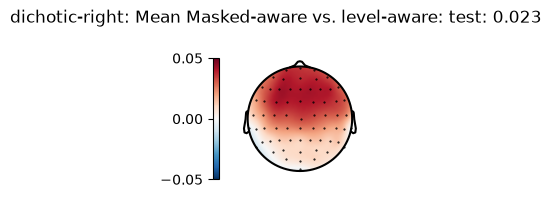

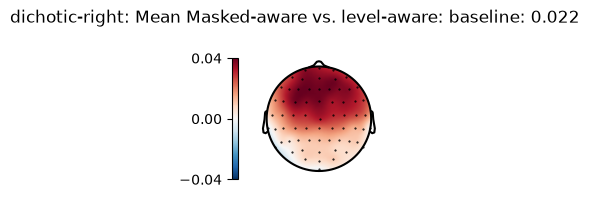

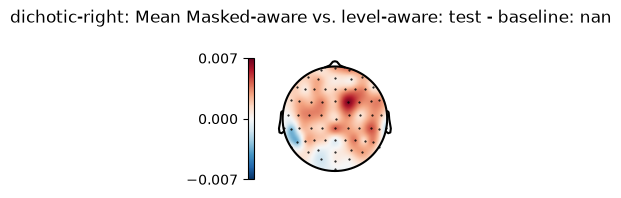

In [ ]:
# Masked-aware vs. level-aware (dichotic-right)
# Brodbeck et al. 2020 ran this comparison too: the ignored-speaker-aware model still beat the loudness-only model, t = 9.21, p < .001 - the masking effect isn't just about volume.
data, diff, result = compute_direct_comparison(FULL_MASKED, LEVEL_AWARE, 'dichotic-right')
show_topomap_trio(data, diff, result, 'Masked-aware vs. level-aware', 'dichotic-right', None)

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Masked-aware vs. level-aware (dichotic-right): ROI model comparison t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, 3 clusters, p = .197>

Masked-aware vs. level-aware (dichotic-right): ROI model comparison t(12) = 1.610, p = 0.0667


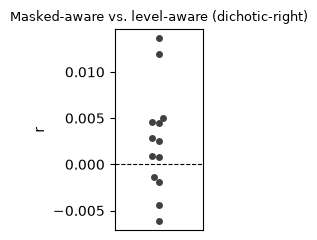

In [ ]:
p = show_subject_swarm(diff, 'Masked-aware vs. level-aware', 'dichotic-right')

## Binaural

In [ ]:
# Loaded once here, reused by every unique-contribution/STRF/peak/
# waveform/attention-effect cell in this section - each one just
# reads a different predictor column out of this same fit instead
# of re-running the (expensive) TRF fit on FULL_BASE again.
data_full = e.load_trfs('all', FULL_BASE, epoch='binaural', **PARAMETERS)

Permutation test:   0%|          | 0/8191 [00:00<?, ? permutations/s]

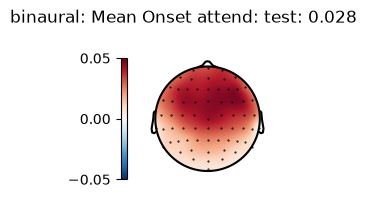

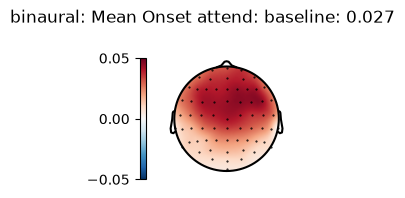

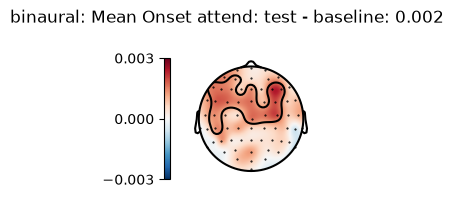

In [ ]:
# Onset attend unique contribution (binaural)
# Brodbeck et al. 2020 ran this comparison too: attended onsets unique contribution, t = 6.32, p < .001.
data, diff, result = compute_unique_contribution(FULL_BASE, onset(ATTEND), 'binaural')
show_topomap_trio(data, diff, result, 'Onset attend', 'binaural', onset(ATTEND))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Onset attend (binaural): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, 2 clusters, p = .012>

Onset attend (binaural): ROI unique contribution t(12) = 3.196, p = 0.0038


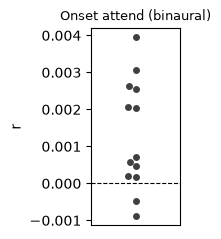

In [ ]:
p = show_subject_swarm(diff, 'Onset attend', 'binaural')

Permutation test:   0%|          | 0/8191 [00:00<?, ? permutations/s]

/Users/joshuaighalo/Github Repositories/cocktail-cortical/analysis/experiment.py:957: UserWarning: Warning: converting a masked element to nan.
  mean_value = float(data.mean())


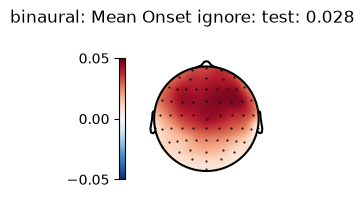

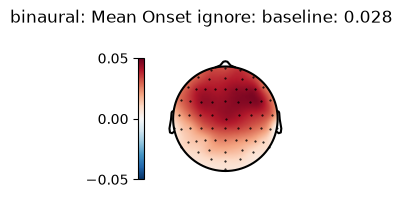

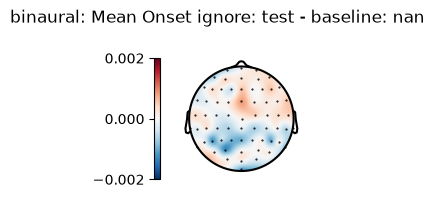

In [ ]:
# Onset ignore unique contribution (binaural)
# Brodbeck et al. 2020 ran this comparison too: ignored onsets unique contribution, t = 6.70, p < .001 - the ignored speaker is tracked separately.
data, diff, result = compute_unique_contribution(FULL_BASE, onset(IGNORE), 'binaural')
show_topomap_trio(data, diff, result, 'Onset ignore', 'binaural', onset(IGNORE))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Onset ignore (binaural): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, 1 clusters, p = .739>

Onset ignore (binaural): ROI unique contribution t(12) = 0.637, p = 0.2682


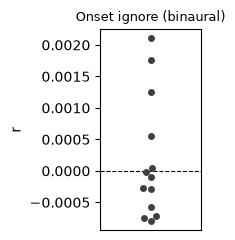

In [ ]:
p = show_subject_swarm(diff, 'Onset ignore', 'binaural')

Permutation test:   0%|          | 0/8191 [00:00<?, ? permutations/s]

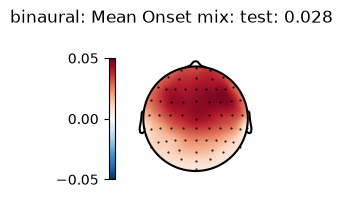

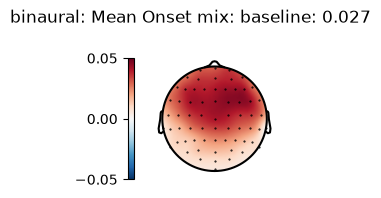

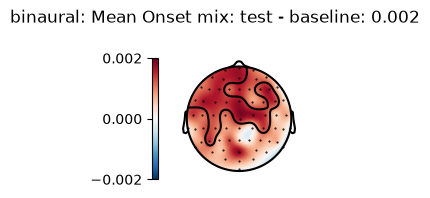

In [ ]:
# Onset mix unique contribution (binaural)
# Brodbeck et al. 2020 ran this comparison too: mixture onsets unique contribution, t = 8.61, p < .001.
data, diff, result = compute_unique_contribution(FULL_BASE, onset(MIX), 'binaural')
show_topomap_trio(data, diff, result, 'Onset mix', 'binaural', onset(MIX))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Onset mix (binaural): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, 2 clusters, p = .020>

Onset mix (binaural): ROI unique contribution t(12) = 2.302, p = 0.0200


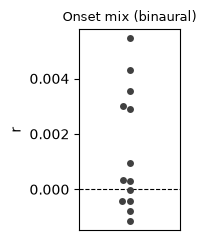

In [ ]:
p = show_subject_swarm(diff, 'Onset mix', 'binaural')

Permutation test:   0%|          | 0/8191 [00:00<?, ? permutations/s]

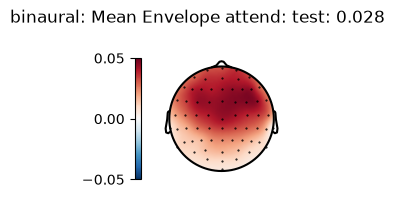

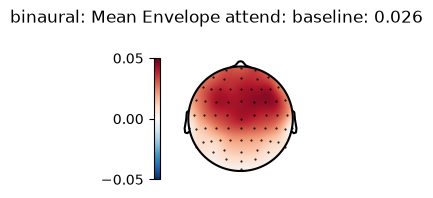

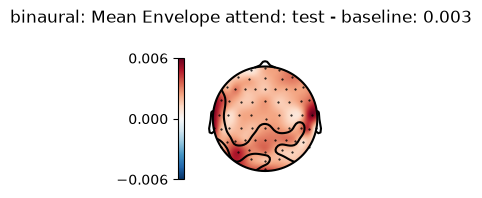

In [ ]:
# Envelope attend unique contribution (binaural)
# Brodbeck et al. 2020 ran this comparison too: attended envelope unique contribution, t = 7.37, p < .001.
data, diff, result = compute_unique_contribution(FULL_BASE, envelope(ATTEND), 'binaural')
show_topomap_trio(data, diff, result, 'Envelope attend', 'binaural', envelope(ATTEND))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Envelope attend (binaural): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, 4 clusters, p = .036>

Envelope attend (binaural): ROI unique contribution t(12) = 1.534, p = 0.0755


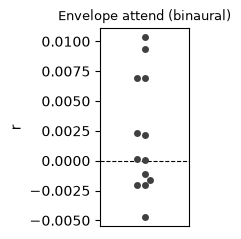

In [ ]:
p = show_subject_swarm(diff, 'Envelope attend', 'binaural')

/Users/joshuaighalo/Github Repositories/cocktail-cortical/analysis/experiment.py:957: UserWarning: Warning: converting a masked element to nan.
  mean_value = float(data.mean())


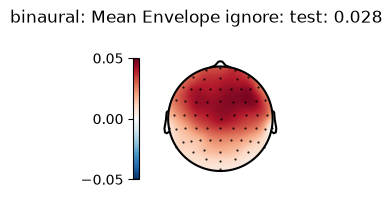

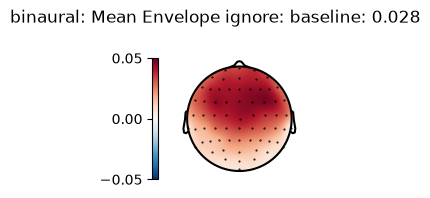

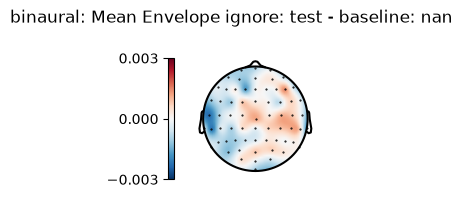

In [ ]:
# Envelope ignore unique contribution (binaural)
# Brodbeck et al. 2020 ran this comparison too: ignored envelope unique contribution, t = 6.28, p < .001 - the ignored speaker's envelope is tracked separately too.
data, diff, result = compute_unique_contribution(FULL_BASE, envelope(IGNORE), 'binaural')
show_topomap_trio(data, diff, result, 'Envelope ignore', 'binaural', envelope(IGNORE))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Envelope ignore (binaural): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, no clusters>

Envelope ignore (binaural): ROI unique contribution t(12) = 0.003, p = 0.4989


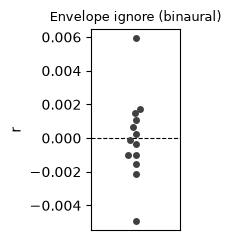

In [ ]:
p = show_subject_swarm(diff, 'Envelope ignore', 'binaural')

/Users/joshuaighalo/Github Repositories/cocktail-cortical/analysis/experiment.py:957: UserWarning: Warning: converting a masked element to nan.
  mean_value = float(data.mean())


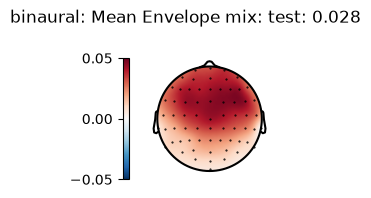

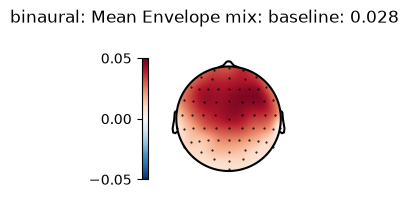

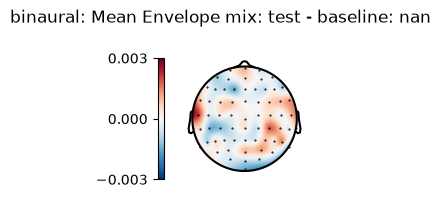

In [ ]:
# Envelope mix unique contribution (binaural)
# Brodbeck et al. 2020 ran this comparison too: mixture envelope unique contribution, t = 5.70, p < .001.
data, diff, result = compute_unique_contribution(FULL_BASE, envelope(MIX), 'binaural')
show_topomap_trio(data, diff, result, 'Envelope mix', 'binaural', envelope(MIX))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Envelope mix (binaural): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, no clusters>

Envelope mix (binaural): ROI unique contribution t(12) = -0.106, p = 0.5413


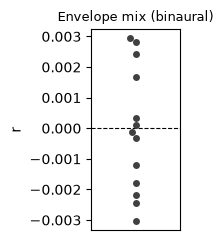

In [ ]:
p = show_subject_swarm(diff, 'Envelope mix', 'binaural')

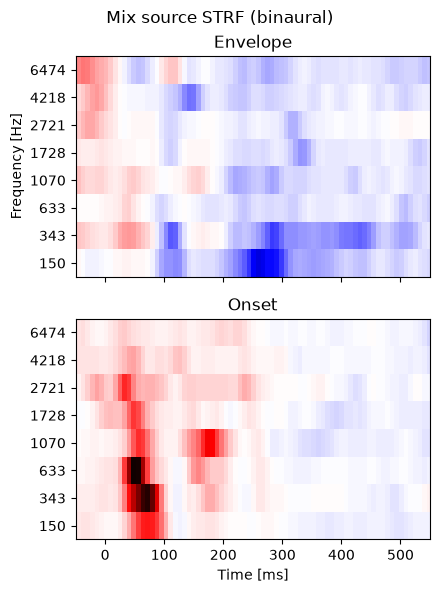

In [ ]:
# Mix source STRF: envelope + onset (binaural)
envelope_strf = extract_strf(data_full, 'mix_gammatone_8')
onset_strf = extract_strf(data_full, 'mix_gammatone_on_8')
p = plot.Array([envelope_strf * 1e3, onset_strf * 1e3], axtitle=['Envelope', 'Onset'],
                title='Mix source STRF (binaural)', xlim=(-0.050, 0.550))

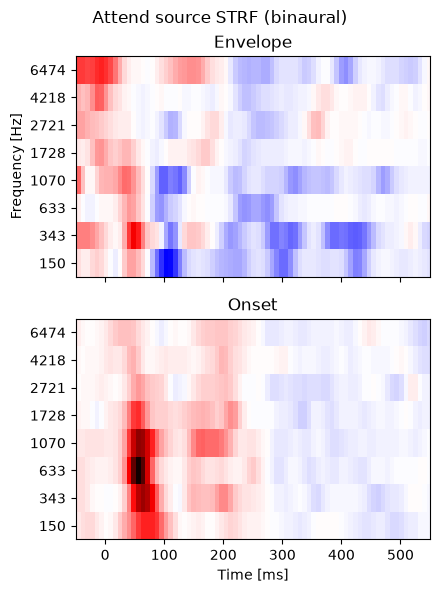

In [ ]:
# Attend source STRF: envelope + onset (binaural)
envelope_strf = extract_strf(data_full, 'gammatone_8')
onset_strf = extract_strf(data_full, 'gammatone_on_8')
p = plot.Array([envelope_strf * 1e3, onset_strf * 1e3], axtitle=['Envelope', 'Onset'],
                title='Attend source STRF (binaural)', xlim=(-0.050, 0.550))

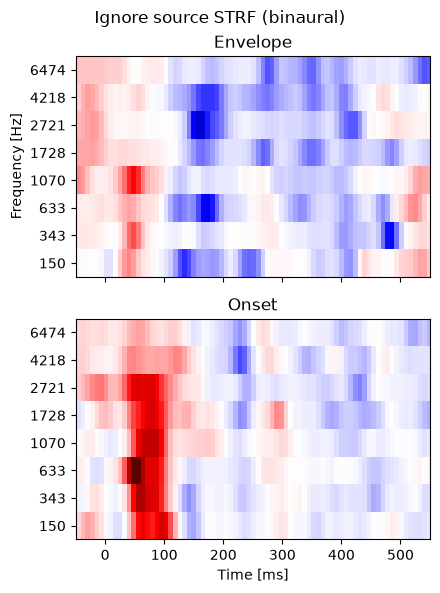

In [ ]:
# Ignore source STRF: envelope + onset (binaural)
envelope_strf = extract_strf(data_full, 'bg_gammatone_8')
onset_strf = extract_strf(data_full, 'bg_gammatone_on_8')
p = plot.Array([envelope_strf * 1e3, onset_strf * 1e3], axtitle=['Envelope', 'Onset'],
                title='Ignore source STRF (binaural)', xlim=(-0.050, 0.550))

In [ ]:
# Onset attend peak amplitude & timing (binaural)
data = extract_trf(data_full, 'gammatone_on_8')
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Onset attend (binaural) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Onset attend (binaural) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

Onset attend (binaural) positive peak: 79 ms, amp 0.002286
Onset attend (binaural) negative peak: 136 ms, amp -6.372e-05


In [ ]:
# Onset ignore peak amplitude & timing (binaural)
data = extract_trf(data_full, 'bg_gammatone_on_8')
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Onset ignore (binaural) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Onset ignore (binaural) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

Onset ignore (binaural) positive peak: 72 ms, amp 0.001489
Onset ignore (binaural) negative peak: 167 ms, amp -0.0002157


In [ ]:
# Onset mix peak amplitude & timing (binaural)
data = extract_trf(data_full, 'mix_gammatone_on_8')
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Onset mix (binaural) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Onset mix (binaural) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

Onset mix (binaural) positive peak: 78 ms, amp 0.002903
Onset mix (binaural) negative peak: 129 ms, amp -7.96e-05


In [ ]:
# Envelope attend peak amplitude & timing (binaural)
data = extract_trf(data_full, 'gammatone_8')
data = add_peak(data, 'positive', ENVELOPE_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ENVELOPE_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Envelope attend (binaural) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Envelope attend (binaural) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

Envelope attend (binaural) positive peak: 84 ms, amp 0.000878
Envelope attend (binaural) negative peak: 158 ms, amp -0.0009386


In [ ]:
# Envelope ignore peak amplitude & timing (binaural)
data = extract_trf(data_full, 'bg_gammatone_8')
data = add_peak(data, 'positive', ENVELOPE_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ENVELOPE_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Envelope ignore (binaural) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Envelope ignore (binaural) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

Envelope ignore (binaural) positive peak: 83 ms, amp 0.0004196
Envelope ignore (binaural) negative peak: 152 ms, amp -0.0007503


In [ ]:
# Envelope mix peak amplitude & timing (binaural)
data = extract_trf(data_full, 'mix_gammatone_8')
data = add_peak(data, 'positive', ENVELOPE_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ENVELOPE_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Envelope mix (binaural) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Envelope mix (binaural) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

Envelope mix (binaural) positive peak: 95 ms, amp 0.0004502
Envelope mix (binaural) negative peak: 156 ms, amp -0.0009438


In [ ]:
# Onset peak comparison across mix, attend, and ignore (binaural)
# Brodbeck et al. 2020 ran this comparison too: positive peak latency mixture 72ms, attended 81ms (t=4.47,p<.001), ignored 89ms (t=6.92,p<.001); negative peak latency mixture 138ms, attended 150ms (t=3.20,p=.004); positive peak amplitude bigger for mixture than attended (t=8.41) or ignored (t=7.66).
dss = []
for role_name, column in (('mix', 'mix_gammatone_on_8'), ('attend', 'gammatone_on_8'), ('ignore', 'bg_gammatone_on_8')):
    ds = extract_trf(data_full, column)
    ds[:, 'role'] = role_name
    dss.append(ds)
data = combine(dss)
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')

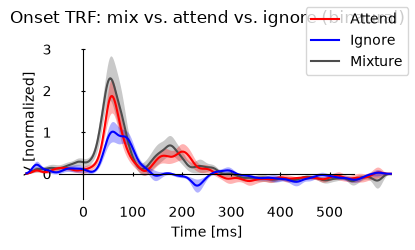

In [ ]:
# The onset TRF waveform mix/attend/ignore were each just measured
# from, overlaid so their shape and relative timing are visible
# directly, not just as extracted peak numbers below.
p = plot.UTSStat('trf_sm*1e3', 'role', data=data, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550),
                  title='Onset TRF: mix vs. attend vs. ignore (binaural)', labels=LABELS_ROLE, colors=COLORS_ROLE)

In [ ]:
print_peak_table(data, 'positive', 'role')
print_peak_table(data, 'negative', 'role')


positive peak
subject   role         time (ms)           amp
01        mix                 86      0.001075
02        mix                 56      0.001703
03        mix                 52      0.002308
04        mix                175      0.001688
05        mix                 54      0.004126
06        mix                 41      0.003742
07        mix                173      0.001675
08        mix                 46      0.002024
09        mix                 76      0.004844
10        mix                 64      0.007668
11        mix                 41     0.0009444
12        mix                 97     0.0004846
13        mix                 54      0.005458
01        attend             199      0.001275
02        attend              68      0.003933
03        attend              41      0.000958
04        attend              58      0.003694
05        attend              54      0.003159
06        attend             168       0.00198
07        attend              54      0.00194

In [ ]:
display(test.pairwise('positive_time', 'role', match='subject', data=data, corr=False, title='onset positive peak latency: mix vs. attend vs. ignore'))
display(test.pairwise('negative_time', 'role', match='subject', data=data, corr=False, title='onset negative peak latency: mix vs. attend vs. ignore'))

,attend,ignore
mix,t12 = -0.05 p = .957,t12 = 0.51 p = .621
attend,,t12 = 0.50 p = .628


,attend,ignore
mix,t12 = -0.73 p = .481,t12 = -3.09** p = .009
attend,,t12 = -1.99 p = .070


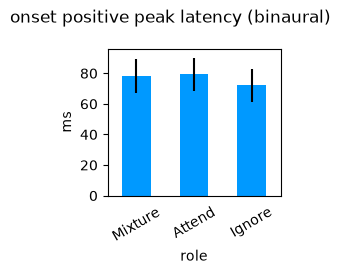

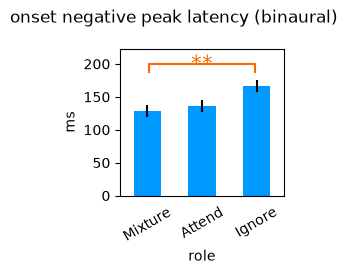

In [ ]:
p = plot.Barplot('positive_time', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='onset positive peak latency (binaural)')
p.set_xtick_rotation(30)
p = plot.Barplot('negative_time', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='onset negative peak latency (binaural)')
p.set_xtick_rotation(30)

In [ ]:
display(test.pairwise('positive_amp', 'role', match='subject', data=data, corr=False, title='onset positive peak amplitude: mix vs. attend vs. ignore'))
display(test.pairwise('negative_amp', 'role', match='subject', data=data, corr=False, title='onset negative peak amplitude: mix vs. attend vs. ignore'))

,attend,ignore
mix,t12 = 1.00 p = .338,t12 = 2.30* p = .041
attend,,t12 = 1.77 p = .102


,attend,ignore
mix,t12 = -0.18 p = .856,t12 = 1.87 p = .085
attend,,t12 = 1.69 p = .116


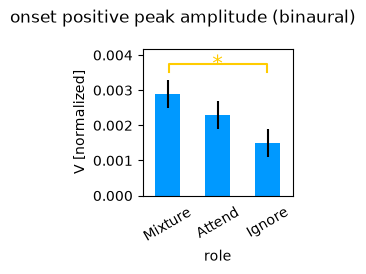

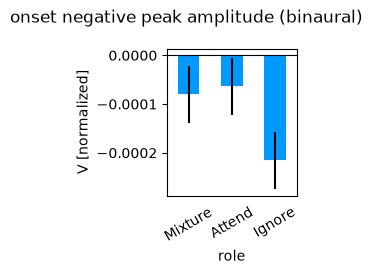

In [ ]:
p = plot.Barplot('positive_amp', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='onset positive peak amplitude (binaural)')
p.set_xtick_rotation(30)
p = plot.Barplot('negative_amp', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='onset negative peak amplitude (binaural)')
p.set_xtick_rotation(30)

In [ ]:
# Envelope peak comparison across mix, attend, and ignore (binaural)
dss = []
for role_name, column in (('mix', 'mix_gammatone_8'), ('attend', 'gammatone_8'), ('ignore', 'bg_gammatone_8')):
    ds = extract_trf(data_full, column)
    ds[:, 'role'] = role_name
    dss.append(ds)
data = combine(dss)
data = add_peak(data, 'positive', ENVELOPE_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ENVELOPE_NEGATIVE_PEAK_WINDOW, kind='min')

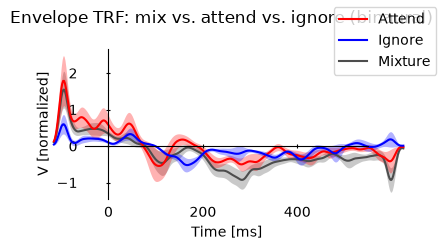

In [ ]:
# The envelope TRF waveform mix/attend/ignore were each just measured
# from, overlaid so their shape and relative timing are visible
# directly, not just as extracted peak numbers below.
p = plot.UTSStat('trf_sm*1e3', 'role', data=data, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550),
                  title='Envelope TRF: mix vs. attend vs. ignore (binaural)', labels=LABELS_ROLE, colors=COLORS_ROLE)

In [ ]:
print_peak_table(data, 'positive', 'role')
print_peak_table(data, 'negative', 'role')


positive peak
subject   role         time (ms)           amp
01        mix                 89     0.0007134
02        mix                 78    -5.545e-05
03        mix                160     0.0001526
04        mix                 41      0.000264
05        mix                187     7.144e-05
06        mix                117     0.0002172
07        mix                 45      0.001391
08        mix                117      0.001065
09        mix                 76      0.000319
10        mix                 41      0.001247
11        mix                 48    -0.0001859
12        mix                 64     8.971e-05
13        mix                168     0.0005631
01        attend             140       0.00183
02        attend              54     0.0005004
03        attend             162     1.571e-06
04        attend              41     0.0001607
05        attend              58       8.3e-05
06        attend             134      0.001376
07        attend              72      0.00026

In [ ]:
display(test.pairwise('positive_time', 'role', match='subject', data=data, corr=False, title='envelope positive peak latency: mix vs. attend vs. ignore'))
display(test.pairwise('negative_time', 'role', match='subject', data=data, corr=False, title='envelope negative peak latency: mix vs. attend vs. ignore'))

,attend,ignore
mix,t12 = 0.85 p = .414,t12 = 0.63 p = .538
attend,,t12 = 0.01 p = .988


,attend,ignore
mix,t12 = -0.25 p = .804,t12 = 0.40 p = .695
attend,,t12 = 0.47 p = .647


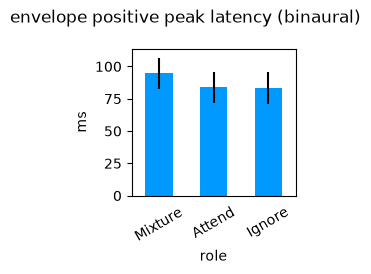

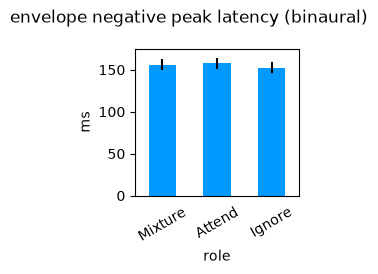

In [ ]:
p = plot.Barplot('positive_time', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='envelope positive peak latency (binaural)')
p.set_xtick_rotation(30)
p = plot.Barplot('negative_time', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='envelope negative peak latency (binaural)')
p.set_xtick_rotation(30)

In [ ]:
display(test.pairwise('positive_amp', 'role', match='subject', data=data, corr=False, title='envelope positive peak amplitude: mix vs. attend vs. ignore'))
display(test.pairwise('negative_amp', 'role', match='subject', data=data, corr=False, title='envelope negative peak amplitude: mix vs. attend vs. ignore'))

,attend,ignore
mix,t12 = -1.69 p = .118,t12 = 0.18 p = .863
attend,,t12 = 1.13 p = .279


,attend,ignore
mix,t12 = -0.02 p = .984,t12 = -0.60 p = .557
attend,,t12 = -0.44 p = .668


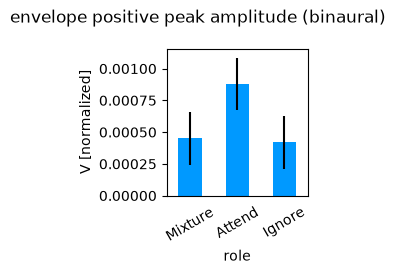

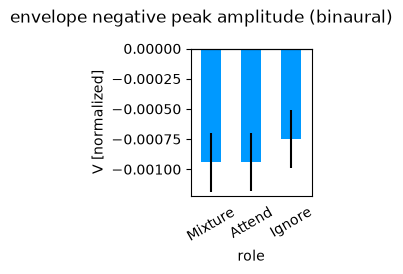

In [ ]:
p = plot.Barplot('positive_amp', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='envelope positive peak amplitude (binaural)')
p.set_xtick_rotation(30)
p = plot.Barplot('negative_amp', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='envelope negative peak amplitude (binaural)')
p.set_xtick_rotation(30)

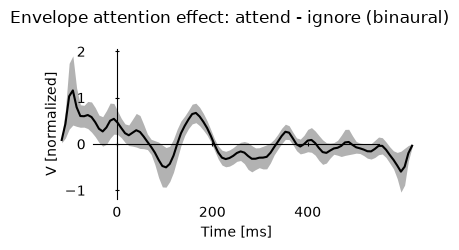

In [ ]:
# Envelope attention effect: attend - ignore (binaural)
# Brodbeck et al. 2020 ran this comparison too: envelope attention-effect difference wave: negative bump ~100ms, positive bump ~200ms, starting almost immediately.
attend_trf = data_full['gammatone_8'].sum('frequency').mean(sensor=ROI)
ignore_trf = data_full['bg_gammatone_8'].sum('frequency').mean(sensor=ROI)
attention_effect = attend_trf - ignore_trf
p = plot.UTSStat(attention_effect * 1e3, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550), title='Envelope attention effect: attend - ignore (binaural)')

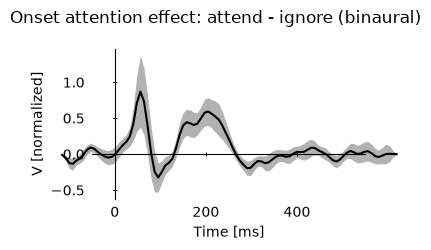

In [ ]:
# Onset attention effect: attend - ignore (binaural)
# Brodbeck et al. 2020 ran this comparison too: onset attention effect appears later than the envelope's, once the masked-onset response develops (see the masked-onset section below).
attend_trf = data_full['gammatone_on_8'].sum('frequency').mean(sensor=ROI)
ignore_trf = data_full['bg_gammatone_on_8'].sum('frequency').mean(sensor=ROI)
attention_effect = attend_trf - ignore_trf
p = plot.UTSStat(attention_effect * 1e3, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550), title='Onset attention effect: attend - ignore (binaural)')

## Binaural (overt onsets)

Permutation test:   0%|          | 0/8191 [00:00<?, ? permutations/s]

/Users/joshuaighalo/Github Repositories/cocktail-cortical/analysis/experiment.py:957: UserWarning: Warning: converting a masked element to nan.
  mean_value = float(data.mean())


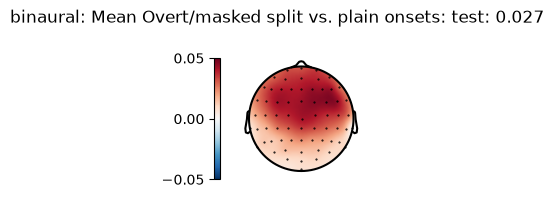

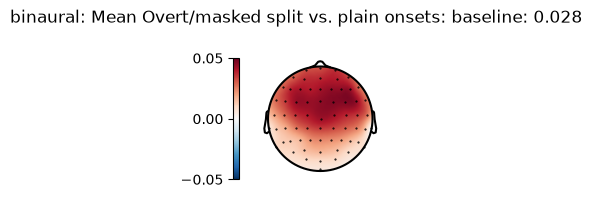

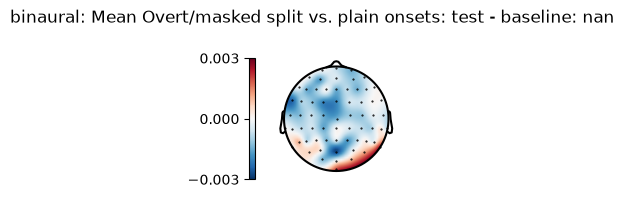

In [ ]:
# Overt/masked split vs. plain onsets (binaural)
# Brodbeck et al. 2020 ran this comparison too: splitting onsets into overt/masked significantly improved the model overall, t = 6.81, p < .001.
data, diff, result = compute_direct_comparison(FULL_MASKED, FULL_BASE, 'binaural')
show_topomap_trio(data, diff, result, 'Overt/masked split vs. plain onsets', 'binaural', None)

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Overt/masked split vs. plain onsets (binaural): ROI model comparison t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, 1 clusters, p = .578>

Overt/masked split vs. plain onsets (binaural): ROI model comparison t(12) = -1.236, p = 0.8799


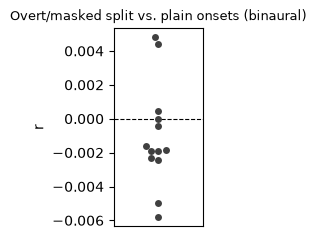

In [ ]:
p = show_subject_swarm(diff, 'Overt/masked split vs. plain onsets', 'binaural')

In [ ]:
# Loaded once here, reused by every STRF/peak/waveform/attention-
# effect/masking-comparison cell in both this subsection and "masked
# onset" below - same reasoning as data_full above, for FULL_MASKED.
data_masked = e.load_trfs('all', FULL_MASKED, epoch='binaural', **PARAMETERS)

Permutation test:   0%|          | 0/8191 [00:00<?, ? permutations/s]

/Users/joshuaighalo/Github Repositories/cocktail-cortical/analysis/experiment.py:957: UserWarning: Warning: converting a masked element to nan.
  mean_value = float(data.mean())


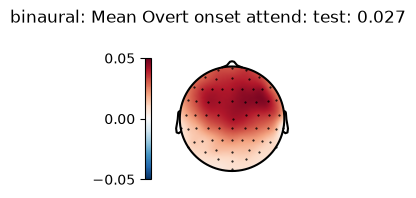

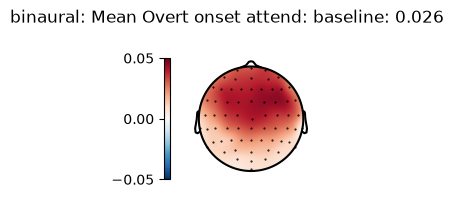

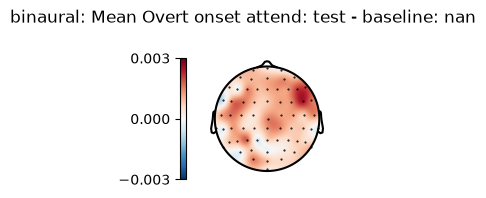

In [ ]:
# Overt onset attend unique contribution (binaural)
# Brodbeck et al. 2020 ran this comparison too: attended overt onsets unique contribution, t = 3.34, p = .027.
data, diff, result = compute_unique_contribution(FULL_MASKED, overt_onset(ATTEND), 'binaural')
show_topomap_trio(data, diff, result, 'Overt onset attend', 'binaural', overt_onset(ATTEND))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Overt onset attend (binaural): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, 5 clusters, p = .192>

Overt onset attend (binaural): ROI unique contribution t(12) = 1.460, p = 0.0850


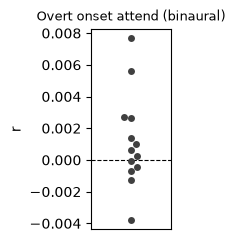

In [ ]:
p = show_subject_swarm(diff, 'Overt onset attend', 'binaural')

Permutation test:   0%|          | 0/8191 [00:00<?, ? permutations/s]

/Users/joshuaighalo/Github Repositories/cocktail-cortical/analysis/experiment.py:957: UserWarning: Warning: converting a masked element to nan.
  mean_value = float(data.mean())


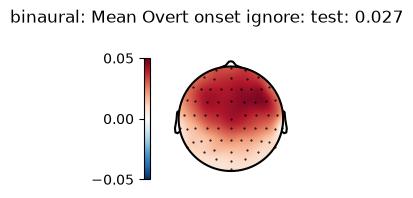

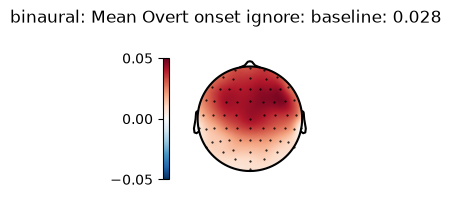

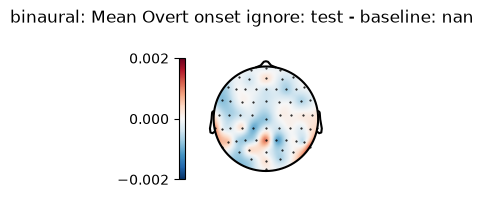

In [ ]:
# Overt onset ignore unique contribution (binaural)
# Brodbeck et al. 2020 ran this comparison too: ignored overt onsets unique contribution, t = 3.82, p = .016.
data, diff, result = compute_unique_contribution(FULL_MASKED, overt_onset(IGNORE), 'binaural')
show_topomap_trio(data, diff, result, 'Overt onset ignore', 'binaural', overt_onset(IGNORE))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Overt onset ignore (binaural): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, 2 clusters, p = .465>

Overt onset ignore (binaural): ROI unique contribution t(12) = -1.083, p = 0.8499


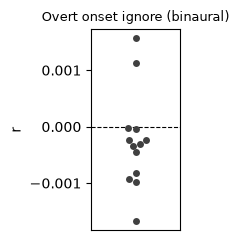

In [ ]:
p = show_subject_swarm(diff, 'Overt onset ignore', 'binaural')

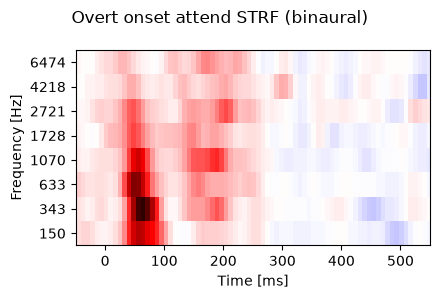

In [ ]:
# Overt onset attend STRF (binaural)
strf = extract_strf(data_masked, 'gammatone_on_overt_8')
p = plot.Array(strf * 1e3, title='Overt onset attend STRF (binaural)', xlim=(-0.050, 0.550))

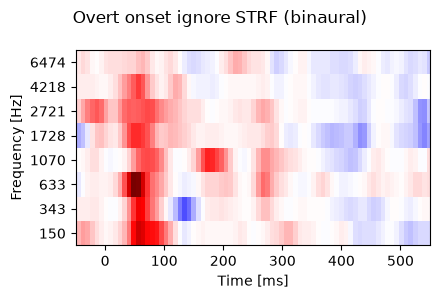

In [ ]:
# Overt onset ignore STRF (binaural)
strf = extract_strf(data_masked, 'bg_gammatone_on_overt_8')
p = plot.Array(strf * 1e3, title='Overt onset ignore STRF (binaural)', xlim=(-0.050, 0.550))

In [ ]:
# Overt onset attend peak amplitude & timing (binaural)
data = extract_trf(data_masked, 'gammatone_on_overt_8')
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Overt onset attend (binaural) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Overt onset attend (binaural) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

Overt onset attend (binaural) positive peak: 87 ms, amp 0.002435
Overt onset attend (binaural) negative peak: 119 ms, amp 5.763e-05


In [ ]:
# Overt onset ignore peak amplitude & timing (binaural)
data = extract_trf(data_masked, 'bg_gammatone_on_overt_8')
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Overt onset ignore (binaural) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Overt onset ignore (binaural) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

Overt onset ignore (binaural) positive peak: 67 ms, amp 0.001123
Overt onset ignore (binaural) negative peak: 157 ms, amp -0.0001728


In [ ]:
# Overt onset peak comparison across attend and ignore (binaural)
dss = []
for role_name, column in (('attend', 'gammatone_on_overt_8'), ('ignore', 'bg_gammatone_on_overt_8')):
    ds = extract_trf(data_masked, column)
    ds[:, 'role'] = role_name
    dss.append(ds)
data = combine(dss)
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')

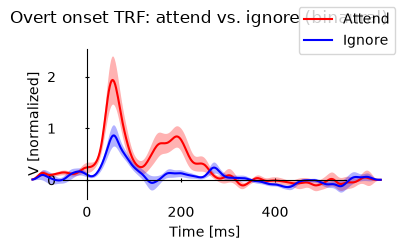

In [ ]:
# The overt onset TRF waveform attend/ignore were each just measured
# from, overlaid so their shape and relative timing are visible
# directly, not just as extracted peak numbers below.
p = plot.UTSStat('trf_sm*1e3', 'role', data=data, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550),
                  title='Overt onset TRF: attend vs. ignore (binaural)', labels={'attend': 'Attend', 'ignore': 'Ignore'}, colors={'attend': 'red', 'ignore': 'blue'})

In [ ]:
print_peak_table(data, 'positive', 'role')
print_peak_table(data, 'negative', 'role')


positive peak
subject   role         time (ms)           amp
01        attend             199      0.002444
02        attend              80      0.001901
03        attend             187     0.0006664
04        attend              48      0.003504
05        attend              56      0.002368
06        attend             150      0.002291
07        attend              52      0.001158
08        attend              52      0.004643
09        attend              74      0.003512
10        attend              62      0.003423
11        attend              41     0.0001384
12        attend              70      0.000367
13        attend              56      0.005237
01        ignore              88      0.000245
02        ignore              62       0.00149
03        ignore              52      0.001673
04        ignore              84     0.0006654
05        ignore              52      0.001667
06        ignore              52     0.0004044
07        ignore              60      0.00130

In [ ]:
display(test.pairwise('positive_time', 'role', match='subject', data=data, corr=False, title='overt onset positive peak latency: attend vs. ignore'))
display(test.pairwise('negative_time', 'role', match='subject', data=data, corr=False, title='overt onset negative peak latency: attend vs. ignore'))

,ignore
attend,t12 = 1.21 p = .250


,ignore
attend,t12 = -3.68** p = .003


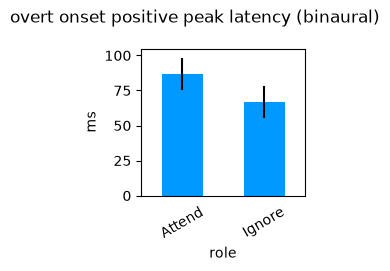

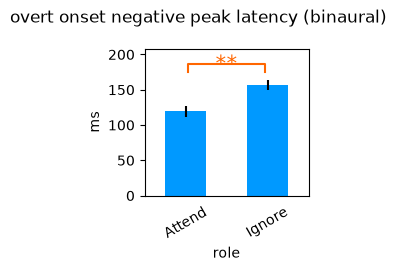

In [ ]:
p = plot.Barplot('positive_time', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='overt onset positive peak latency (binaural)')
p.set_xtick_rotation(30)
p = plot.Barplot('negative_time', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='overt onset negative peak latency (binaural)')
p.set_xtick_rotation(30)

In [ ]:
display(test.pairwise('positive_amp', 'role', match='subject', data=data, corr=False, title='overt onset positive peak amplitude: attend vs. ignore'))
display(test.pairwise('negative_amp', 'role', match='subject', data=data, corr=False, title='overt onset negative peak amplitude: attend vs. ignore'))

,ignore
attend,t12 = 2.53* p = .027


,ignore
attend,t12 = 1.77 p = .102


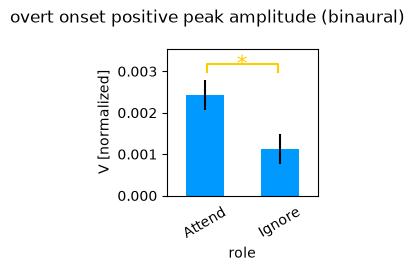

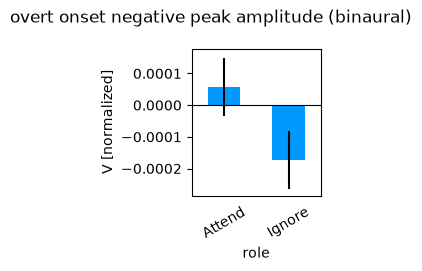

In [ ]:
p = plot.Barplot('positive_amp', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='overt onset positive peak amplitude (binaural)')
p.set_xtick_rotation(30)
p = plot.Barplot('negative_amp', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='overt onset negative peak amplitude (binaural)')
p.set_xtick_rotation(30)

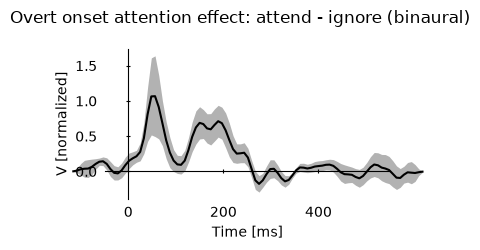

In [ ]:
# Overt onset attention effect: attend - ignore (binaural)
attend_trf = data_masked['gammatone_on_overt_8'].sum('frequency').mean(sensor=ROI)
ignore_trf = data_masked['bg_gammatone_on_overt_8'].sum('frequency').mean(sensor=ROI)
attention_effect = attend_trf - ignore_trf
p = plot.UTSStat(attention_effect * 1e3, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550), title='Overt onset attention effect: attend - ignore (binaural)')

## Binaural (masked onset)

Permutation test:   0%|          | 0/8191 [00:00<?, ? permutations/s]

/Users/joshuaighalo/Github Repositories/cocktail-cortical/analysis/experiment.py:957: UserWarning: Warning: converting a masked element to nan.
  mean_value = float(data.mean())


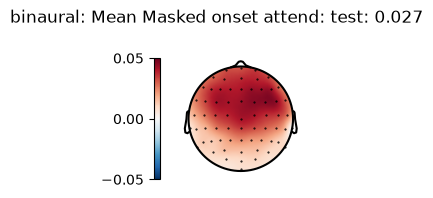

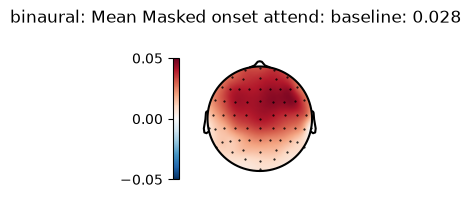

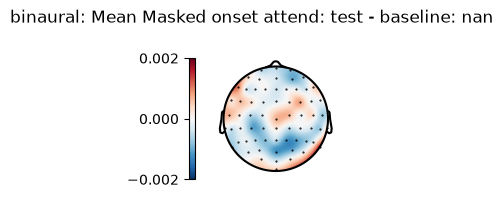

In [ ]:
# Masked onset attend unique contribution (binaural)
# Brodbeck et al. 2020 ran this comparison too: attended masked onsets unique contribution, t = 8.42, p < .001 - the strongest of the four masking predictors.
data, diff, result = compute_unique_contribution(FULL_MASKED, masked_onset(ATTEND), 'binaural')
show_topomap_trio(data, diff, result, 'Masked onset attend', 'binaural', masked_onset(ATTEND))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Masked onset attend (binaural): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, 1 clusters, p = .798>

Masked onset attend (binaural): ROI unique contribution t(12) = -0.019, p = 0.5075


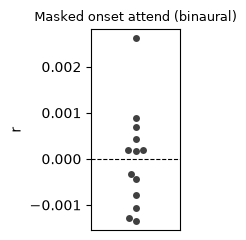

In [ ]:
p = show_subject_swarm(diff, 'Masked onset attend', 'binaural')

Permutation test:   0%|          | 0/8191 [00:00<?, ? permutations/s]

/Users/joshuaighalo/Github Repositories/cocktail-cortical/analysis/experiment.py:957: UserWarning: Warning: converting a masked element to nan.
  mean_value = float(data.mean())


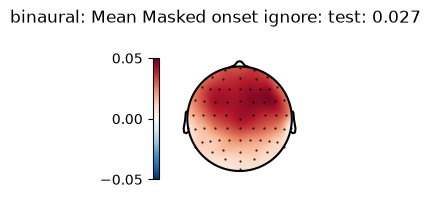

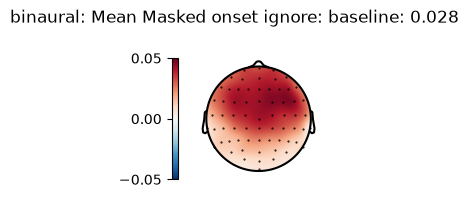

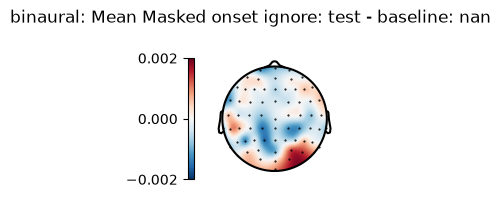

In [ ]:
# Masked onset ignore unique contribution (binaural)
# Brodbeck et al. 2020 ran this comparison too: ignored masked onsets unique contribution, t = 5.23, p < .001 - the brain recovers masked information even for the ignored speaker.
data, diff, result = compute_unique_contribution(FULL_MASKED, masked_onset(IGNORE), 'binaural')
show_topomap_trio(data, diff, result, 'Masked onset ignore', 'binaural', masked_onset(IGNORE))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Masked onset ignore (binaural): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, 2 clusters, p = .636>

Masked onset ignore (binaural): ROI unique contribution t(12) = -0.688, p = 0.7478


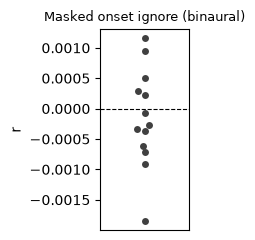

In [ ]:
p = show_subject_swarm(diff, 'Masked onset ignore', 'binaural')

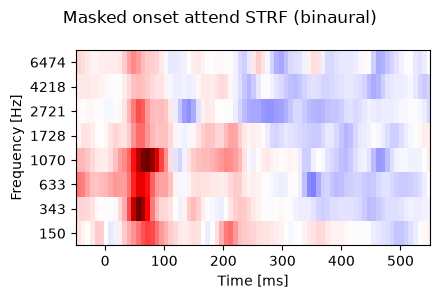

In [ ]:
# Masked onset attend STRF (binaural)
strf = extract_strf(data_masked, 'gammatone_on_masked_8')
p = plot.Array(strf * 1e3, title='Masked onset attend STRF (binaural)', xlim=(-0.050, 0.550))

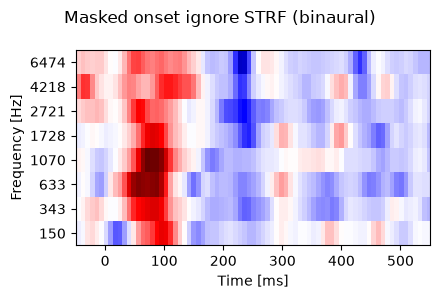

In [ ]:
# Masked onset ignore STRF (binaural)
strf = extract_strf(data_masked, 'bg_gammatone_on_masked_8')
p = plot.Array(strf * 1e3, title='Masked onset ignore STRF (binaural)', xlim=(-0.050, 0.550))

In [ ]:
# Masked onset attend peak amplitude & timing (binaural)
data = extract_trf(data_masked, 'gammatone_on_masked_8')
data = add_peak(data, 'positive', MASKED_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', MASKED_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Masked onset attend (binaural) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Masked onset attend (binaural) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

Masked onset attend (binaural) positive peak: 84 ms, amp 0.001114
Masked onset attend (binaural) negative peak: 143 ms, amp -0.00022


In [ ]:
# Masked onset ignore peak amplitude & timing (binaural)
data = extract_trf(data_masked, 'bg_gammatone_on_masked_8')
data = add_peak(data, 'positive', MASKED_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', MASKED_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Masked onset ignore (binaural) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Masked onset ignore (binaural) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

Masked onset ignore (binaural) positive peak: 76 ms, amp 0.001052
Masked onset ignore (binaural) negative peak: 184 ms, amp -0.0003615


In [ ]:
# Masked onset peak comparison across attend and ignore (binaural)
dss = []
for role_name, column in (('attend', 'gammatone_on_masked_8'), ('ignore', 'bg_gammatone_on_masked_8')):
    ds = extract_trf(data_masked, column)
    ds[:, 'role'] = role_name
    dss.append(ds)
data = combine(dss)
data = add_peak(data, 'positive', MASKED_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', MASKED_NEGATIVE_PEAK_WINDOW, kind='min')

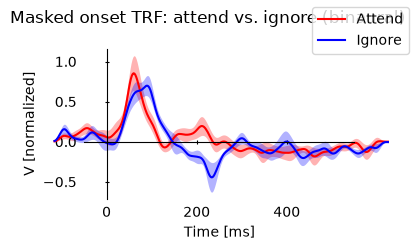

In [ ]:
# The masked onset TRF waveform attend/ignore were each just measured
# from, overlaid so their shape and relative timing are visible
# directly, not just as extracted peak numbers below.
p = plot.UTSStat('trf_sm*1e3', 'role', data=data, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550),
                  title='Masked onset TRF: attend vs. ignore (binaural)', labels={'attend': 'Attend', 'ignore': 'Ignore'}, colors={'attend': 'red', 'ignore': 'blue'})

In [ ]:
print_peak_table(data, 'positive', 'role')
print_peak_table(data, 'negative', 'role')


positive peak
subject   role         time (ms)           amp
01        attend             199     0.0001766
02        attend              66      0.003059
03        attend              41      0.001093
04        attend              64      0.001221
05        attend              54      0.001842
06        attend             175      0.000844
07        attend             105       0.00111
08        attend              56      0.001433
09        attend              60      0.001105
10        attend              82      0.001416
11        attend              52     0.0003814
12        attend              78     0.0006619
13        attend              62     0.0001397
01        ignore              91      0.001671
02        ignore              64      0.001039
03        ignore              91     0.0009566
04        ignore              45     0.0008253
05        ignore              64      0.001321
06        ignore              56      0.001045
07        ignore              95      0.00107

In [ ]:
display(test.pairwise('positive_time', 'role', match='subject', data=data, corr=False, title='masked onset positive peak latency: attend vs. ignore'))
display(test.pairwise('negative_time', 'role', match='subject', data=data, corr=False, title='masked onset negative peak latency: attend vs. ignore'))

,ignore
attend,t12 = 0.56 p = .587


,ignore
attend,t12 = -3.34** p = .006


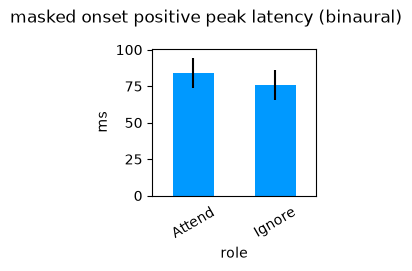

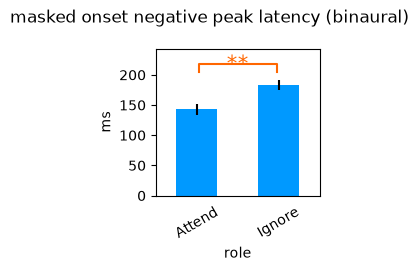

In [ ]:
p = plot.Barplot('positive_time', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='masked onset positive peak latency (binaural)')
p.set_xtick_rotation(30)
p = plot.Barplot('negative_time', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='masked onset negative peak latency (binaural)')
p.set_xtick_rotation(30)

In [ ]:
display(test.pairwise('positive_amp', 'role', match='subject', data=data, corr=False, title='masked onset positive peak amplitude: attend vs. ignore'))
display(test.pairwise('negative_amp', 'role', match='subject', data=data, corr=False, title='masked onset negative peak amplitude: attend vs. ignore'))

,ignore
attend,t12 = 0.27 p = .794


,ignore
attend,t12 = 1.23 p = .243


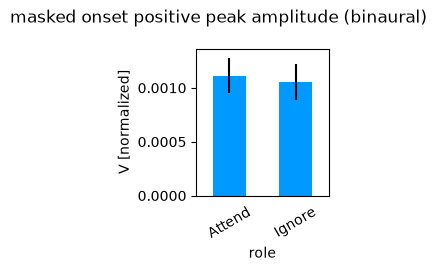

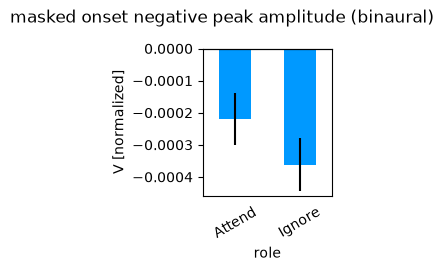

In [ ]:
p = plot.Barplot('positive_amp', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='masked onset positive peak amplitude (binaural)')
p.set_xtick_rotation(30)
p = plot.Barplot('negative_amp', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='masked onset negative peak amplitude (binaural)')
p.set_xtick_rotation(30)

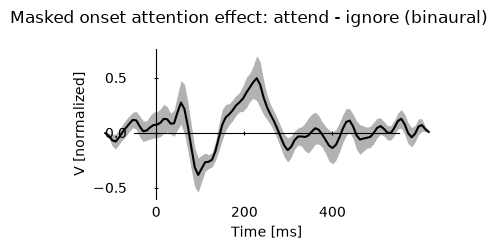

In [ ]:
# Masked onset attention effect: attend - ignore (binaural)
attend_trf = data_masked['gammatone_on_masked_8'].sum('frequency').mean(sensor=ROI)
ignore_trf = data_masked['bg_gammatone_on_masked_8'].sum('frequency').mean(sensor=ROI)
attention_effect = attend_trf - ignore_trf
p = plot.UTSStat(attention_effect * 1e3, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550), title='Masked onset attention effect: attend - ignore (binaural)')

In [ ]:
# Overt vs. masked peak comparison, attend (binaural)
# Brodbeck et al. 2020 ran this comparison too: attended overt 72ms vs. attended masked 91ms (t=2.85,p=.009); combined (not stream-split) late negative peak, overt 133ms vs. masked 182ms (t=4.45,p<.001).
dss = []
for masking, column in (('overt', 'gammatone_on_overt_8'), ('masked', 'gammatone_on_masked_8')):
    ds = extract_trf(data_masked, column)
    ds[:, 'masking'] = masking
    dss.append(ds)
data = combine(dss)
data = add_peak(data, 'positive', MASKED_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', MASKED_NEGATIVE_PEAK_WINDOW, kind='min')

In [ ]:
print_peak_table(data, 'positive', 'masking')
print_peak_table(data, 'negative', 'masking')


positive peak
subject   masking      time (ms)           amp
01        overt              199      0.002444
02        overt               80      0.001901
03        overt              187     0.0006664
04        overt               48      0.003504
05        overt               56      0.002368
06        overt              150      0.002291
07        overt               52      0.001158
08        overt               52      0.004643
09        overt               74      0.003512
10        overt               62      0.003423
11        overt               41     0.0001384
12        overt               70      0.000367
13        overt               56      0.005237
01        masked             199     0.0001766
02        masked              66      0.003059
03        masked              41      0.001093
04        masked              64      0.001221
05        masked              54      0.001842
06        masked             175      0.000844
07        masked             105       0.0011

In [ ]:
display(test.pairwise('positive_time', 'masking', match='subject', data=data, corr=False, title='attend positive peak latency: overt vs. masked'))
display(test.pairwise('negative_time', 'masking', match='subject', data=data, corr=False, title='attend negative peak latency: overt vs. masked'))

,masked
overt,t12 = 0.20 p = .847


,masked
overt,t12 = -2.39* p = .034


In [ ]:
display(test.pairwise('positive_amp', 'masking', match='subject', data=data, corr=False, title='attend positive peak amplitude: overt vs. masked'))
display(test.pairwise('negative_amp', 'masking', match='subject', data=data, corr=False, title='attend negative peak amplitude: overt vs. masked'))

,masked
overt,t12 = 2.68* p = .020


,masked
overt,t12 = 2.45* p = .031


In [ ]:
# Overt vs. masked peak comparison, ignore (binaural)
# Brodbeck et al. 2020 ran this comparison too: ignored overt 83ms vs. ignored masked 97ms (t=6.11,p<.001); combined (not stream-split) late negative peak, overt 133ms vs. masked 182ms (t=4.45,p<.001).
dss = []
for masking, column in (('overt', 'bg_gammatone_on_overt_8'), ('masked', 'bg_gammatone_on_masked_8')):
    ds = extract_trf(data_masked, column)
    ds[:, 'masking'] = masking
    dss.append(ds)
data = combine(dss)
data = add_peak(data, 'positive', MASKED_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', MASKED_NEGATIVE_PEAK_WINDOW, kind='min')

In [ ]:
print_peak_table(data, 'positive', 'masking')
print_peak_table(data, 'negative', 'masking')


positive peak
subject   masking      time (ms)           amp
01        overt               88      0.000245
02        overt               62       0.00149
03        overt               52      0.001673
04        overt               84     0.0006654
05        overt               52      0.001667
06        overt               52     0.0004044
07        overt               60      0.001302
08        overt              115      0.001045
09        overt               74     0.0005697
10        overt               58      0.001563
11        overt               54      0.002224
12        overt               41     0.0006118
13        overt               78      0.001144
01        masked              91      0.001671
02        masked              64      0.001039
03        masked              91     0.0009566
04        masked              45     0.0008253
05        masked              64      0.001321
06        masked              56      0.001045
07        masked              95      0.00107

In [ ]:
display(test.pairwise('positive_time', 'masking', match='subject', data=data, corr=False, title='ignore positive peak latency: overt vs. masked'))
display(test.pairwise('negative_time', 'masking', match='subject', data=data, corr=False, title='ignore negative peak latency: overt vs. masked'))

,masked
overt,t12 = -1.47 p = .168


,masked
overt,t12 = -3.16** p = .008


In [ ]:
display(test.pairwise('positive_amp', 'masking', match='subject', data=data, corr=False, title='ignore positive peak amplitude: overt vs. masked'))
display(test.pairwise('negative_amp', 'masking', match='subject', data=data, corr=False, title='ignore negative peak amplitude: overt vs. masked'))

,masked
overt,t12 = 0.42 p = .679


,masked
overt,t12 = 1.63 p = .130


In [ ]:
# Stream x masking interaction on peak amplitude (binaural)
# Brodbeck et al. 2020 ran this comparison too: stream x masking interaction, F(1,25) = 24.45, p < .001 - overt onsets show no early attention effect, masked onsets do.
dss = []
for stream_name, is_attend in (('attend', True), ('ignore', False)):
    for masking_name in ('overt', 'masked'):
        prefix = '' if is_attend else 'bg_'
        column = f'{prefix}gammatone_on_{masking_name}_8'
        ds = extract_trf(data_masked, column)
        ds[:, 'stream'] = stream_name
        ds[:, 'masking'] = masking_name
        dss.append(ds)
data = combine(dss)
data = add_peak(data, 'positive', MASKED_POSITIVE_PEAK_WINDOW, kind='max')
display(test.ANOVA('positive_amp', 'stream * masking * subject', data=data, title='stream x masking interaction (binaural)'))

<ANOVA: positive_amp ~ stream + masking + stream x masking + subject + stream x subject + masking x subject + stream x masking x subject
  
  stream x masking interaction (binaural)
  
                       SS   df     MS   MS(denom)   df(denom)         F      p
  ----------------------------------------------------------------------------
  stream             0.00    1   0.00        0.00          12   6.00*     .031
  masking            0.00    1   0.00        0.00          12   9.29*     .010
  stream x masking   0.00    1   0.00        0.00          12   4.68      .051
  ----------------------------------------------------------------------------
  Total              0.00   51
>

## Binaural (intensity-level control)

Permutation test:   0%|          | 0/8191 [00:00<?, ? permutations/s]

/Users/joshuaighalo/Github Repositories/cocktail-cortical/analysis/experiment.py:957: UserWarning: Warning: converting a masked element to nan.
  mean_value = float(data.mean())


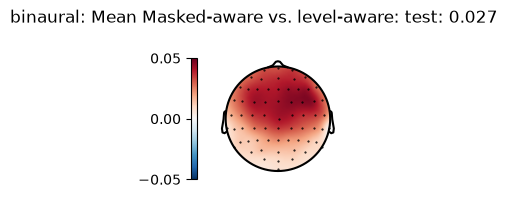

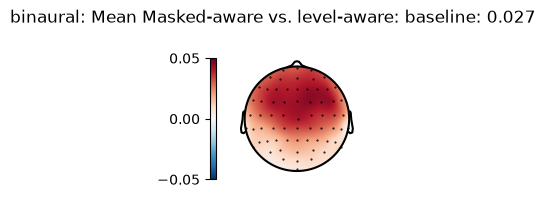

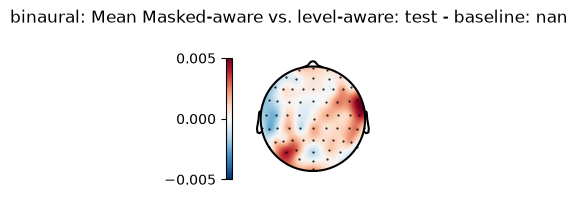

In [ ]:
# Masked-aware vs. level-aware (binaural)
# Brodbeck et al. 2020 ran this comparison too: the ignored-speaker-aware model still beat the loudness-only model, t = 9.21, p < .001 - the masking effect isn't just about volume.
data, diff, result = compute_direct_comparison(FULL_MASKED, LEVEL_AWARE, 'binaural')
show_topomap_trio(data, diff, result, 'Masked-aware vs. level-aware', 'binaural', None)

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Masked-aware vs. level-aware (binaural): ROI model comparison t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, 2 clusters, p = .261>

Masked-aware vs. level-aware (binaural): ROI model comparison t(12) = 0.367, p = 0.3601


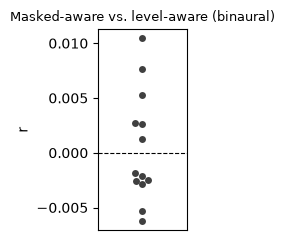

In [ ]:
p = show_subject_swarm(diff, 'Masked-aware vs. level-aware', 'binaural')

## Cross-condition comparisons

Every analysis above stays within one listening condition. This section
asks the complementary question: for a *given* predictor (mixture,
attend, or ignore) and a *given* response kind (onset or envelope), does
its peak's timing or amplitude change depending on which of the four
spatial conditions it's in? That means pooling diotic, dichotic-left,
dichotic-right, and binaural together - the one place in this notebook
that isn't self-contained within a single condition's section, since the
comparison is *across* conditions by definition.

In [ ]:
# One load_trfs() call per epoch - four total, a genuinely different fit
# each time, so these four can't be collapsed any further - reused below
# for both the onset and the envelope cross-condition comparisons.
data_by_epoch = {
    epoch: e.load_trfs('all', FULL_BASE, epoch=epoch, **PARAMETERS)
    for epoch in ('diotic', 'dichotic-left', 'dichotic-right', 'binaural')
}

In [ ]:
# Onset peak time/amplitude, pooled across all four two-talker conditions.
dss = []
for epoch, data_full in data_by_epoch.items():
    for role_name, column in (('mix', 'mix_gammatone_on_8'), ('attend', 'gammatone_on_8'), ('ignore', 'bg_gammatone_on_8')):
        ds = extract_trf(data_full, column)
        ds[:, 'role'] = role_name
        ds[:, 'epoch'] = epoch
        dss.append(ds)
data = combine(dss)
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')

### Onset peak time by predictor

In [ ]:
# Onset Attend peak latency across conditions
display(test.pairwise('positive_time', 'epoch', match='subject', sub="role == 'attend'", data=data, corr=False, title='Onset Attend peak latency across conditions'))

,dichotic-left,dichotic-right,binaural
diotic,t12 = -1.18 p = .262,t12 = -1.19 p = .256,t12 = -0.19 p = .850
dichotic-left,,t12 = 0.53 p = .607,t12 = 1.29 p = .221
dichotic-right,,,t12 = 1.13 p = .282


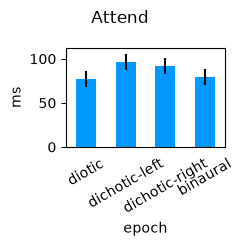

In [ ]:
p = plot.Barplot('positive_time', 'epoch', match='subject', sub="role == 'attend'", data=data, h=2, w=2.5, title='Attend', corr=False)
p.set_xtick_rotation(30)

In [ ]:
# Onset Ignore peak latency across conditions
display(test.pairwise('positive_time', 'epoch', match='subject', sub="role == 'ignore'", data=data, corr=False, title='Onset Ignore peak latency across conditions'))

,dichotic-left,dichotic-right,binaural
diotic,t12 = 0.36 p = .722,t12 = -1.24 p = .239,t12 = 1.27 p = .228
dichotic-left,,t12 = -1.18 p = .259,t12 = 0.64 p = .537
dichotic-right,,,t12 = 1.94 p = .076


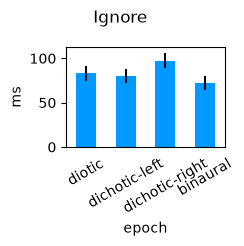

In [ ]:
p = plot.Barplot('positive_time', 'epoch', match='subject', sub="role == 'ignore'", data=data, h=2, w=2.5, title='Ignore', corr=False)
p.set_xtick_rotation(30)

In [ ]:
# Onset Mixture peak latency across conditions
display(test.pairwise('positive_time', 'epoch', match='subject', sub="role == 'mix'", data=data, corr=False, title='Onset Mixture peak latency across conditions'))

,dichotic-left,dichotic-right,binaural
diotic,t12 = -0.52 p = .611,t12 = -1.62 p = .132,t12 = -0.95 p = .361
dichotic-left,,t12 = -0.47 p = .645,t12 = -0.19 p = .853
dichotic-right,,,t12 = 0.15 p = .885


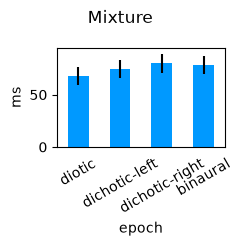

In [ ]:
p = plot.Barplot('positive_time', 'epoch', match='subject', sub="role == 'mix'", data=data, h=2, w=2.5, title='Mixture', corr=False)
p.set_xtick_rotation(30)

### Onset peak amplitude by predictor

In [ ]:
# Onset Attend peak amplitude across conditions
display(test.pairwise('positive_amp', 'epoch', match='subject', sub="role == 'attend'", data=data, corr=False, title='Onset Attend peak amplitude across conditions'))

,dichotic-left,dichotic-right,binaural
diotic,t12 = 1.09 p = .298,t12 = 0.47 p = .647,t12 = 0.27 p = .795
dichotic-left,,t12 = -1.13 p = .282,t12 = -1.05 p = .316
dichotic-right,,,t12 = -0.31 p = .762


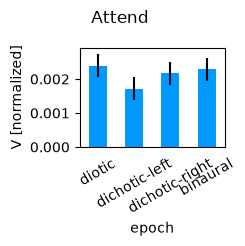

In [ ]:
p = plot.Barplot('positive_amp', 'epoch', match='subject', sub="role == 'attend'", data=data, h=2, w=2.5, title='Attend', corr=False)
p.set_xtick_rotation(30)

In [ ]:
# Onset Ignore peak amplitude across conditions
display(test.pairwise('positive_amp', 'epoch', match='subject', sub="role == 'ignore'", data=data, corr=False, title='Onset Ignore peak amplitude across conditions'))

,dichotic-left,dichotic-right,binaural
diotic,t12 = 2.72* p = .019,t12 = 2.15 p = .052,t12 = 0.96 p = .355
dichotic-left,,t12 = -1.30 p = .218,t12 = -3.48** p = .005
dichotic-right,,,t12 = -3.34** p = .006


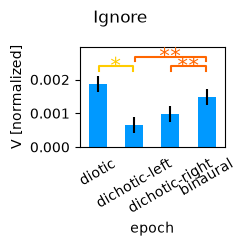

In [ ]:
p = plot.Barplot('positive_amp', 'epoch', match='subject', sub="role == 'ignore'", data=data, h=2, w=2.5, title='Ignore', corr=False)
p.set_xtick_rotation(30)

In [ ]:
# Onset Mixture peak amplitude across conditions
display(test.pairwise('positive_amp', 'epoch', match='subject', sub="role == 'mix'", data=data, corr=False, title='Onset Mixture peak amplitude across conditions'))

,dichotic-left,dichotic-right,binaural
diotic,t12 = 1.88 p = .084,t12 = 1.07 p = .305,t12 = -2.32* p = .039
dichotic-left,,t12 = -0.92 p = .377,t12 = -3.37** p = .006
dichotic-right,,,t12 = -2.83* p = .015


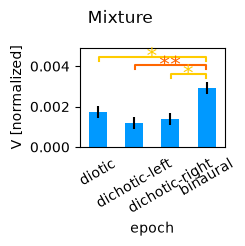

In [ ]:
p = plot.Barplot('positive_amp', 'epoch', match='subject', sub="role == 'mix'", data=data, h=2, w=2.5, title='Mixture', corr=False)
p.set_xtick_rotation(30)

In [ ]:
# Envelope peak time/amplitude, pooled across all four two-talker
# conditions - same data_by_epoch loaded above, just reading each
# epoch's envelope columns instead of its onset columns this time.
dss = []
for epoch, data_full in data_by_epoch.items():
    for role_name, column in (('mix', 'mix_gammatone_8'), ('attend', 'gammatone_8'), ('ignore', 'bg_gammatone_8')):
        ds = extract_trf(data_full, column)
        ds[:, 'role'] = role_name
        ds[:, 'epoch'] = epoch
        dss.append(ds)
data = combine(dss)
data = add_peak(data, 'positive', ENVELOPE_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ENVELOPE_NEGATIVE_PEAK_WINDOW, kind='min')

### Envelope peak time by predictor

In [ ]:
# Envelope Attend peak latency across conditions
display(test.pairwise('positive_time', 'epoch', match='subject', sub="role == 'attend'", data=data, corr=False, title='Envelope Attend peak latency across conditions'))

,dichotic-left,dichotic-right,binaural
diotic,t12 = -0.19 p = .850,t12 = 1.07 p = .305,t12 = 0.52 p = .612
dichotic-left,,t12 = 1.14 p = .276,t12 = 1.47 p = .166
dichotic-right,,,t12 = -0.49 p = .632


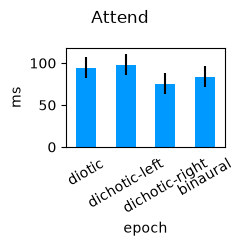

In [ ]:
p = plot.Barplot('positive_time', 'epoch', match='subject', sub="role == 'attend'", data=data, h=2, w=2.5, title='Attend', corr=False)
p.set_xtick_rotation(30)

In [ ]:
# Envelope Ignore peak latency across conditions
display(test.pairwise('positive_time', 'epoch', match='subject', sub="role == 'ignore'", data=data, corr=False, title='Envelope Ignore peak latency across conditions'))

,dichotic-left,dichotic-right,binaural
diotic,t12 = 0.46 p = .654,t12 = -1.57 p = .142,t12 = -0.82 p = .427
dichotic-left,,t12 = -2.42* p = .032,t12 = -1.66 p = .122
dichotic-right,,,t12 = 0.67 p = .514


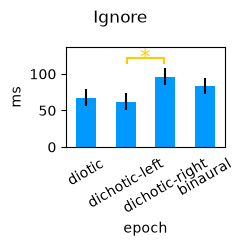

In [ ]:
p = plot.Barplot('positive_time', 'epoch', match='subject', sub="role == 'ignore'", data=data, h=2, w=2.5, title='Ignore', corr=False)
p.set_xtick_rotation(30)

In [ ]:
# Envelope Mixture peak latency across conditions
display(test.pairwise('positive_time', 'epoch', match='subject', sub="role == 'mix'", data=data, corr=False, title='Envelope Mixture peak latency across conditions'))

,dichotic-left,dichotic-right,binaural
diotic,t12 = -0.46 p = .652,t12 = -0.23 p = .823,t12 = -0.71 p = .488
dichotic-left,,t12 = 0.39 p = .701,t12 = -0.05 p = .962
dichotic-right,,,t12 = -0.45 p = .663


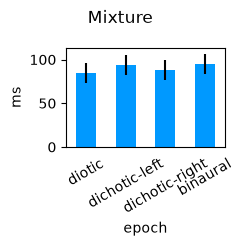

In [ ]:
p = plot.Barplot('positive_time', 'epoch', match='subject', sub="role == 'mix'", data=data, h=2, w=2.5, title='Mixture', corr=False)
p.set_xtick_rotation(30)

### Envelope peak amplitude by predictor

In [ ]:
# Envelope Attend peak amplitude across conditions
display(test.pairwise('positive_amp', 'epoch', match='subject', sub="role == 'attend'", data=data, corr=False, title='Envelope Attend peak amplitude across conditions'))

,dichotic-left,dichotic-right,binaural
diotic,t12 = 0.09 p = .929,t12 = 0.53 p = .608,t12 = -0.03 p = .975
dichotic-left,,t12 = 0.58 p = .574,t12 = -0.12 p = .906
dichotic-right,,,t12 = -0.85 p = .410


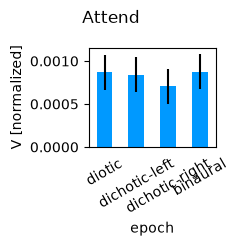

In [ ]:
p = plot.Barplot('positive_amp', 'epoch', match='subject', sub="role == 'attend'", data=data, h=2, w=2.5, title='Attend', corr=False)
p.set_xtick_rotation(30)

In [ ]:
# Envelope Ignore peak amplitude across conditions
display(test.pairwise('positive_amp', 'epoch', match='subject', sub="role == 'ignore'", data=data, corr=False, title='Envelope Ignore peak amplitude across conditions'))

,dichotic-left,dichotic-right,binaural
diotic,t12 = 2.98* p = .012,t12 = 1.29 p = .221,t12 = 1.47 p = .168
dichotic-left,,t12 = -1.79 p = .099,t12 = -1.33 p = .208
dichotic-right,,,t12 = 0.12 p = .905


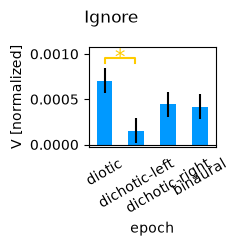

In [ ]:
p = plot.Barplot('positive_amp', 'epoch', match='subject', sub="role == 'ignore'", data=data, h=2, w=2.5, title='Ignore', corr=False)
p.set_xtick_rotation(30)

In [ ]:
# Envelope Mixture peak amplitude across conditions
display(test.pairwise('positive_amp', 'epoch', match='subject', sub="role == 'mix'", data=data, corr=False, title='Envelope Mixture peak amplitude across conditions'))

,dichotic-left,dichotic-right,binaural
diotic,t12 = 2.18* p = .050,t12 = 1.76 p = .105,t12 = 2.38* p = .035
dichotic-left,,t12 = -1.15 p = .273,t12 = -0.64 p = .533
dichotic-right,,,t12 = 0.33 p = .744


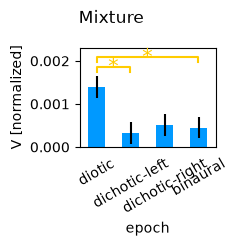

In [ ]:
p = plot.Barplot('positive_amp', 'epoch', match='subject', sub="role == 'mix'", data=data, h=2, w=2.5, title='Mixture', corr=False)
p.set_xtick_rotation(30)

In [ ]:
# One load_trfs() call per epoch for FULL_MASKED - same reasoning as
# data_by_epoch above, reused below for both the overt and the masked
# cross-condition comparisons. No 'mix' role here: only attend/ignore
# have overt/masked versions at all.
data_by_epoch_masked = {
    epoch: e.load_trfs('all', FULL_MASKED, epoch=epoch, **PARAMETERS)
    for epoch in ('diotic', 'dichotic-left', 'dichotic-right', 'binaural')
}

In [ ]:
# Overt onset peak time/amplitude, pooled across all four conditions.
dss = []
for epoch, data_masked in data_by_epoch_masked.items():
    for role_name, column in (('attend', 'gammatone_on_overt_8'), ('ignore', 'bg_gammatone_on_overt_8')):
        ds = extract_trf(data_masked, column)
        ds[:, 'role'] = role_name
        ds[:, 'epoch'] = epoch
        dss.append(ds)
data = combine(dss)
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')

### Overt onset peak time by predictor

In [ ]:
# Overt onset Attend peak latency across conditions
display(test.pairwise('positive_time', 'epoch', match='subject', sub="role == 'attend'", data=data, corr=False, title='Overt onset Attend peak latency across conditions'))

,dichotic-left,dichotic-right,binaural
diotic,t12 = -0.66 p = .519,t12 = -1.07 p = .308,t12 = -0.29 p = .774
dichotic-left,,t12 = 0.09 p = .928,t12 = 0.32 p = .755
dichotic-right,,,t12 = 0.36 p = .724


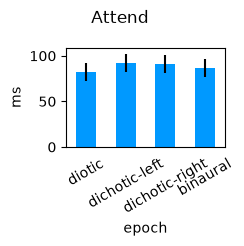

In [ ]:
p = plot.Barplot('positive_time', 'epoch', match='subject', sub="role == 'attend'", data=data, h=2, w=2.5, title='Attend', corr=False)
p.set_xtick_rotation(30)

In [ ]:
# Overt onset Ignore peak latency across conditions
display(test.pairwise('positive_time', 'epoch', match='subject', sub="role == 'ignore'", data=data, corr=False, title='Overt onset Ignore peak latency across conditions'))

,dichotic-left,dichotic-right,binaural
diotic,t12 = -0.22 p = .827,t12 = 1.03 p = .322,t12 = 1.53 p = .152
dichotic-left,,t12 = 1.36 p = .198,t12 = 1.42 p = .182
dichotic-right,,,t12 = 0.61 p = .552


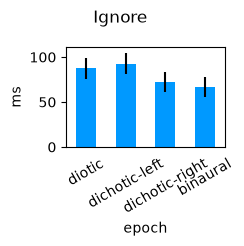

In [ ]:
p = plot.Barplot('positive_time', 'epoch', match='subject', sub="role == 'ignore'", data=data, h=2, w=2.5, title='Ignore', corr=False)
p.set_xtick_rotation(30)

### Overt onset peak amplitude by predictor

In [ ]:
# Overt onset Attend peak amplitude across conditions
display(test.pairwise('positive_amp', 'epoch', match='subject', sub="role == 'attend'", data=data, corr=False, title='Overt onset Attend peak amplitude across conditions'))

,dichotic-left,dichotic-right,binaural
diotic,t12 = -0.42 p = .680,t12 = -0.52 p = .612,t12 = -1.20 p = .252
dichotic-left,,t12 = 0.07 p = .945,t12 = -1.04 p = .318
dichotic-right,,,t12 = -1.12 p = .284


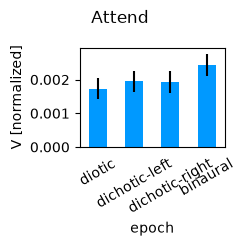

In [ ]:
p = plot.Barplot('positive_amp', 'epoch', match='subject', sub="role == 'attend'", data=data, h=2, w=2.5, title='Attend', corr=False)
p.set_xtick_rotation(30)

In [ ]:
# Overt onset Ignore peak amplitude across conditions
display(test.pairwise('positive_amp', 'epoch', match='subject', sub="role == 'ignore'", data=data, corr=False, title='Overt onset Ignore peak amplitude across conditions'))

,dichotic-left,dichotic-right,binaural
diotic,t12 = 1.75 p = .106,t12 = 1.77 p = .102,t12 = 0.61 p = .552
dichotic-left,,t12 = 0.13 p = .896,t12 = -2.18* p = .050
dichotic-right,,,t12 = -3.00* p = .011


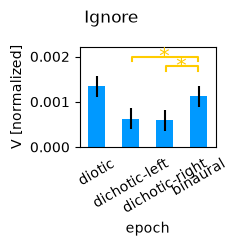

In [ ]:
p = plot.Barplot('positive_amp', 'epoch', match='subject', sub="role == 'ignore'", data=data, h=2, w=2.5, title='Ignore', corr=False)
p.set_xtick_rotation(30)

In [ ]:
# Masked onset peak time/amplitude, pooled across all four conditions -
# same data_by_epoch_masked loaded above, just reading each epoch's
# masked columns instead of its overt columns this time.
dss = []
for epoch, data_masked in data_by_epoch_masked.items():
    for role_name, column in (('attend', 'gammatone_on_masked_8'), ('ignore', 'bg_gammatone_on_masked_8')):
        ds = extract_trf(data_masked, column)
        ds[:, 'role'] = role_name
        ds[:, 'epoch'] = epoch
        dss.append(ds)
data = combine(dss)
data = add_peak(data, 'positive', MASKED_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', MASKED_NEGATIVE_PEAK_WINDOW, kind='min')

### Masked onset peak time by predictor

In [ ]:
# Masked onset Attend peak latency across conditions
display(test.pairwise('positive_time', 'epoch', match='subject', sub="role == 'attend'", data=data, corr=False, title='Masked onset Attend peak latency across conditions'))

,dichotic-left,dichotic-right,binaural
diotic,t12 = -1.15 p = .274,t12 = -0.89 p = .389,t12 = 1.28 p = .224
dichotic-left,,t12 = 0.73 p = .477,t12 = 1.45 p = .172
dichotic-right,,,t12 = 1.38 p = .191


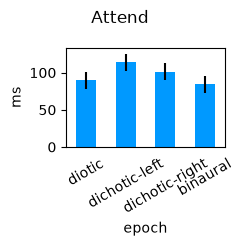

In [ ]:
p = plot.Barplot('positive_time', 'epoch', match='subject', sub="role == 'attend'", data=data, h=2, w=2.5, title='Attend', corr=False)
p.set_xtick_rotation(30)

In [ ]:
# Masked onset Ignore peak latency across conditions
display(test.pairwise('positive_time', 'epoch', match='subject', sub="role == 'ignore'", data=data, corr=False, title='Masked onset Ignore peak latency across conditions'))

,dichotic-left,dichotic-right,binaural
diotic,t12 = 0.36 p = .726,t12 = -0.05 p = .958,t12 = 1.45 p = .173
dichotic-left,,t12 = -0.27 p = .795,t12 = 0.75 p = .469
dichotic-right,,,t12 = 1.09 p = .298


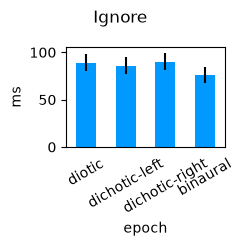

In [ ]:
p = plot.Barplot('positive_time', 'epoch', match='subject', sub="role == 'ignore'", data=data, h=2, w=2.5, title='Ignore', corr=False)
p.set_xtick_rotation(30)

### Masked onset peak amplitude by predictor

In [ ]:
# Masked onset Attend peak amplitude across conditions
display(test.pairwise('positive_amp', 'epoch', match='subject', sub="role == 'attend'", data=data, corr=False, title='Masked onset Attend peak amplitude across conditions'))

,dichotic-left,dichotic-right,binaural
diotic,t12 = 1.48 p = .164,t12 = -0.10 p = .919,t12 = 0.82 p = .430
dichotic-left,,t12 = -1.94 p = .077,t12 = -0.84 p = .417
dichotic-right,,,t12 = 0.67 p = .516


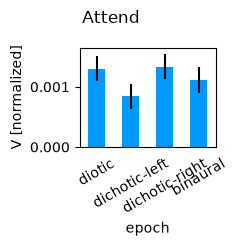

In [ ]:
p = plot.Barplot('positive_amp', 'epoch', match='subject', sub="role == 'attend'", data=data, h=2, w=2.5, title='Attend', corr=False)
p.set_xtick_rotation(30)

In [ ]:
# Masked onset Ignore peak amplitude across conditions
display(test.pairwise('positive_amp', 'epoch', match='subject', sub="role == 'ignore'", data=data, corr=False, title='Masked onset Ignore peak amplitude across conditions'))

,dichotic-left,dichotic-right,binaural
diotic,t12 = 2.11 p = .057,t12 = 1.07 p = .308,t12 = 0.43 p = .674
dichotic-left,,t12 = -1.44 p = .174,t12 = -3.59** p = .004
dichotic-right,,,t12 = -0.65 p = .527


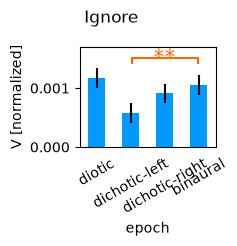

In [ ]:
p = plot.Barplot('positive_amp', 'epoch', match='subject', sub="role == 'ignore'", data=data, h=2, w=2.5, title='Ignore', corr=False)
p.set_xtick_rotation(30)